# 33 — Final Evaluation Report

**Origin:** Existing Previous Version of Notebook 28, Pre-refactor\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/33_final_evaluation_report/`\
**Depends on:** Notebooks 21–32

## Purpose

Assemble the final thesis-wide evaluation report from completed upstream evidence without computing new scientific metrics, rankings, statistical tests, exclusions, or trustworthiness scores.

The notebook consolidates the controlled experimental design, restoration results, metric evidence, uncertainty analyses, robustness experiments, failure taxonomy, explainability evidence, model cards, compute evidence, and case-level reports produced by the preceding notebooks.

## Approved evidence population

The final synthesis covers:

- 50 controlled paintings;
- 525 registered experimental cases;
- 410 restoration-eligible cases;
- 1,785 approved report candidates;
- 1,230 primary core candidates;
- 1,080 primary nonzero-damage core candidates;
- 130 canonical diffusion-uncertainty groups;
- 35 damage-size diffusion-uncertainty groups;
- 165 total supported uncertainty groups;
- OpenCV Telea, LaMa, Stable Diffusion, and the partial SDXL feasibility population.

The report uses 12 deterministically selected case grids for detailed visual discussion. Complete case and painting evidence remains available through the reports and indexes produced by Notebook 32.

## Evidence synthesized

The notebook consolidates:

- dataset composition and documented dataset limitations;
- damage and degradation protocols;
- model eligibility and availability;
- metric-region compatibility rules;
- classical full-reference metrics;
- LPIPS perceptual evidence;
- CLIP and DINOv2 feature evidence;
- texture, colour, seam, semantic, and structural evidence;
- canonical and damage-size diffusion uncertainty;
- damage-size sensitivity;
- mask-placement robustness;
- synthetic-degradation behaviour;
- grouped statistics and metric correlations;
- ranking stability and disagreement;
- failure categories and trustworthiness flags;
- metric and region-policy ablations;
- explainability and case retrieval;
- runtime, memory, model-card, and scalability evidence;
- case-level and painting-level visual evidence;
- limitations, deviations, exclusions, and human-review requirements.

## Research-question framing

The report provides direct, evidence-scoped answers concerning:

1. how restoration methods compare under complementary evaluation metrics;
2. how damage size, mask placement, and degradation type affect restoration behaviour;
3. how uncertainty, disagreement, failure indicators, and explainability can support trustworthy human review;
4. what compute, coverage, and methodological limitations constrain the conclusions.

Facts are followed by short plain-language assertions explaining whether the evidence indicates better performance, worse performance, inconclusive evidence, or a limitation. No conclusion may extend beyond the population and evidence that produced it.

## Report contract

The final report preserves the approved preparation-layer mock structure while replacing mock material with canonical evidence. Extensions may add clarity or provenance, but may not silently remove, reorder, or fundamentally replace approved sections.

The notebook produces:

- 19 report sections;
- 15 compact thesis tables containing 293 canonical rows;
- 15 LaTeX-ready table records;
- 18 thesis figures;
- 6 publication figures;
- 24 persisted analytical figures in total;
- 48 evidence-backed report claims;
- 18 explicit limitation or deviation records;
- 106 evidence-catalog records;
- 125 mock-to-final traceability records;
- 12 selected detailed case grids;
- one self-contained HTML report.

The HTML report embeds its visual evidence directly. It must contain at least 64 embedded image elements and 260 visual tiles and must not require external image files to remain readable.

## Interpretation limits

This notebook is a presentation and synthesis layer. It does not create new scientific evidence.

The following limits remain explicit:

- artificial image damage does not reproduce every material conservation process;
- the controlled dataset is not a paired real damaged/undamaged conservation dataset;
- style or period metadata is documented for only 18 of 50 paintings;
- five-painting extension experiments confound painting identity and broad content category;
- SDXL evidence covers only ten cases across five paintings;
- diffusion uncertainty exists only for supported repeated-seed populations;
- uncertainty is empirical seed variability, not calibrated confidence;
- OpenCV Telea and LaMa are deterministic methods;
- computational flags are not expert annotations or conservation decisions;
- feature similarity and visual plausibility do not establish historical authenticity;
- runtime and memory results describe the evaluated workstation;
- scaling projections are projections, not executed measurements or confidence intervals;
- no universal combined quality or trustworthiness score is justified;
- no model receives conservation approval or a physical treatment recommendation.

**Visual plausibility is not equivalent to historical or restoration trustworthiness.**

## Canonical outputs

- `data/thesis_tables.csv`
- `data/latex_tables.csv`
- `data/report_evidence_catalog.csv`
- `figures/thesis/`
- `figures/publication/`
- `reports/final_evaluation.html`
- `reports/limitations_and_deviations.md`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract, initialization, and upstream preflight

This batch:

- discovers the repository root without relying on the current working directory;
- loads the locked Notebook 33 configuration;
- establishes the notebook-owned output directories;
- checks for stale pre-existing output files;
- validates all declared inputs against the canonical inventory;
- requires completed manifests from Notebooks 01–32;
- validates the global project-path registry;
- constructs the approved table, figure, report-section, evidence-catalog, and mock-traceability plans;
- deterministically selects the 12 approved Notebook 32 case grids;
- applies a blocking gate before any report evidence is assembled.

No canonical report, table, figure, manifest, or validation file is persisted by this batch.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from IPython.display import display


# Discover the repository root from either the repository or notebooks directory.
CURRENT_LOCATION = Path.cwd().resolve()
ROOT_CANDIDATES = [CURRENT_LOCATION, *CURRENT_LOCATION.parents]

PROJECT_ROOT = next(
    (
        candidate
        for candidate in ROOT_CANDIDATES
        if (
            candidate / "config/evaluation/final_evaluation_report.yaml"
        ).is_file()
        and (candidate / "src/restoration_eval").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the painting-restoration-eval repository root."
    )

SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))


from restoration_eval.final_evaluation_report import (
    CONFIG_SCHEMA_VERSION,
    MODULE_VERSION,
    append_validation_checks,
    build_evidence_catalog_plan,
    build_figure_plan,
    build_mock_traceability,
    build_report_section_plan,
    build_thesis_table_plan,
    load_final_evaluation_config,
    load_upstream_manifests,
    resolve_final_evaluation_inputs,
    resolve_final_evaluation_outputs,
    select_final_case_grids,
    validate_inventory_contract,
    validate_preparation_plans,
    validate_selected_case_grids,
    validate_upstream_completion,
)
from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    validate_project_paths_registry,
)
from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


RUN_STARTED_AT_UTC = datetime.now(timezone.utc).isoformat()
VALIDATION = ValidationCollector()

print("Notebook 33 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Platform: {platform.platform()}")
print(f"Report helper version: {MODULE_VERSION}")
print(f"Validation helper version: {VALIDATION_MODULE_VERSION}")
print(f"Path helper version: {PATHS_MODULE_VERSION}")
print(f"Run started at UTC: {RUN_STARTED_AT_UTC}")

Notebook 33 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Platform: Windows-11-10.0.26200-SP0
Report helper version: 1.0.0
Validation helper version: 1.0.0
Path helper version: 1.0.0
Run started at UTC: 2026-09-02T20:57:21.925521+00:00


In [2]:
CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "final_evaluation_report.yaml"
)

CONFIG = load_final_evaluation_config(CONFIG_PATH)
SETTINGS = CONFIG["final_evaluation_report"]
EXPECTED = SETTINGS["expected_counts"]
POPULATION = SETTINGS["population"]

INPUT_PATHS = resolve_final_evaluation_inputs(CONFIG, PROJECT_ROOT)
OUTPUT_PATHS = resolve_final_evaluation_outputs(CONFIG, PROJECT_ROOT)
OUTPUT_ROOT = OUTPUT_PATHS["root"]


# Inspect the owned output root before creating its directory structure.
OUTPUT_ROOT_PREEXISTED = OUTPUT_ROOT.exists()
PREEXISTING_OUTPUT_FILES = (
    sorted(
        path.relative_to(OUTPUT_ROOT).as_posix()
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT_PREEXISTED
    else []
)

DIRECTORY_PATHS = {
    OUTPUT_ROOT,
    OUTPUT_PATHS["thesis_tables_path"].parent,
    OUTPUT_PATHS["latex_tables_path"].parent,
    OUTPUT_PATHS["evidence_catalog_path"].parent,
    OUTPUT_PATHS["thesis_figures_dir"],
    OUTPUT_PATHS["publication_figures_dir"],
    OUTPUT_PATHS["final_report_path"].parent,
    OUTPUT_PATHS["limitations_path"].parent,
    OUTPUT_PATHS["run_manifest_path"].parent,
    OUTPUT_PATHS["artifacts_path"].parent,
    OUTPUT_PATHS["validation_path"].parent,
    OUTPUT_PATHS["work_dir"],
}

for directory in sorted(DIRECTORY_PATHS, key=lambda path: path.as_posix()):
    directory.mkdir(parents=True, exist_ok=True)


VALIDATION.add(
    validation_stage="batch_1_contract",
    check_id="notebook_identity",
    check_description="Configuration is locked to Notebook 33.",
    severity="blocking",
    expected={
        "notebook_id": "33",
        "notebook_stem": "33_final_evaluation_report",
    },
    observed={
        "notebook_id": SETTINGS["notebook_id"],
        "notebook_stem": SETTINGS["notebook_stem"],
    },
    passed=(
        SETTINGS["notebook_id"] == "33"
        and SETTINGS["notebook_stem"] == "33_final_evaluation_report"
    ),
    details="Notebook identity must not drift during final synthesis.",
)

VALIDATION.add(
    validation_stage="batch_1_contract",
    check_id="presentation_only_scope",
    check_description="Notebook 33 is explicitly presentation-only.",
    severity="blocking",
    expected=False,
    observed=SETTINGS["creates_new_scientific_evidence"],
    passed=SETTINGS["creates_new_scientific_evidence"] is False,
    details="Notebook 33 must not create new scientific evidence.",
)

VALIDATION.add(
    validation_stage="batch_1_contract",
    check_id="clean_output_root",
    check_description="No stale files existed in the Notebook 33 output root.",
    severity="blocking",
    expected=[],
    observed=PREEXISTING_OUTPUT_FILES,
    passed=not PREEXISTING_OUTPUT_FILES,
    details=(
        "Delete outputs/33_final_evaluation_report before a clean full rerun "
        "if stale files are listed."
    ),
)

VALIDATION.add(
    validation_stage="batch_1_contract",
    check_id="declared_input_count",
    check_description="All direct inputs and upstream manifests were resolved.",
    severity="blocking",
    expected=78,
    observed=len(INPUT_PATHS),
    passed=len(INPUT_PATHS) == 78,
    details="The locked contract contains 46 direct inputs and 32 manifests.",
)

VALIDATION.add(
    validation_stage="batch_1_contract",
    check_id="input_table_contract_count",
    check_description="The expected canonical input-table contracts are present.",
    severity="blocking",
    expected=EXPECTED["input_tables"],
    observed=len(SETTINGS["input_table_contracts"]),
    passed=(
        len(SETTINGS["input_table_contracts"])
        == int(EXPECTED["input_tables"])
    ),
    details="Notebook 33 requires 33 canonical upstream tables.",
)


OUTPUT_CONTRACT_VIEW = pd.DataFrame(
    [
        {
            "output_key": key,
            "repository_relative_path": path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "exists_after_setup": path.exists(),
        }
        for key, path in OUTPUT_PATHS.items()
    ]
).sort_values("output_key", kind="stable")

CONTRACT_SUMMARY = pd.DataFrame(
    [
        {"contract_item": "configuration schema", "value": CONFIG_SCHEMA_VERSION},
        {"contract_item": "dataset scope", "value": SETTINGS["dataset_scope"]},
        {"contract_item": "declared inputs", "value": len(INPUT_PATHS)},
        {
            "contract_item": "canonical input tables",
            "value": len(SETTINGS["input_table_contracts"]),
        },
        {
            "contract_item": "upstream manifests",
            "value": len(SETTINGS["upstream_manifests"]),
        },
        {
            "contract_item": "physical output files",
            "value": EXPECTED["physical_output_files"],
        },
        {
            "contract_item": "artifact records",
            "value": EXPECTED["artifact_records"],
        },
    ]
)

display(CONTRACT_SUMMARY)
display(OUTPUT_CONTRACT_VIEW)

print(f"Output root existed before setup: {OUTPUT_ROOT_PREEXISTED}")
print(f"Pre-existing output files: {len(PREEXISTING_OUTPUT_FILES)}")
print("Notebook-owned directory structure is ready.")

,contract_item,value
0,configuration schema,final_evaluation_report_config.v1
1,dataset scope,controlled_50
2,declared inputs,78
3,canonical input tables,33
4,upstream manifests,32
5,physical output files,32
6,artifact records,8


,output_key,repository_relative_path,exists_after_setup
9,artifacts_path,outputs/33_final_evaluation_report/manifests/a...,False
3,evidence_catalog_path,outputs/33_final_evaluation_report/data/report...,False
6,final_report_path,outputs/33_final_evaluation_report/reports/fin...,False
2,latex_tables_path,outputs/33_final_evaluation_report/data/latex_...,False
7,limitations_path,outputs/33_final_evaluation_report/reports/lim...,False
5,publication_figures_dir,outputs/33_final_evaluation_report/figures/pub...,True
0,root,outputs/33_final_evaluation_report,True
8,run_manifest_path,outputs/33_final_evaluation_report/manifests/r...,False
4,thesis_figures_dir,outputs/33_final_evaluation_report/figures/thesis,True
1,thesis_tables_path,outputs/33_final_evaluation_report/data/thesis...,False


Output root existed before setup: False
Pre-existing output files: 0
Notebook-owned directory structure is ready.


In [3]:
INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)


append_validation_checks(
    VALIDATION,
    validate_inventory_contract(
        INVENTORY,
        PROJECT_ROOT,
        INPUT_PATHS,
    ),
)

INVENTORY_READ_ERRORS = int(
    INVENTORY_RUN.get("summary", {}).get("read_error_file_count", -1)
)

VALIDATION.add(
    validation_stage="inventory_preflight",
    check_id="inventory_run_status",
    check_description="The canonical inventory run completed successfully.",
    severity="blocking",
    expected="completed",
    observed=INVENTORY_RUN.get("status"),
    passed=INVENTORY_RUN.get("status") == "completed",
    details="An incomplete inventory cannot support the final report preflight.",
)

VALIDATION.add(
    validation_stage="inventory_preflight",
    check_id="inventory_run_read_errors",
    check_description="The inventory run recorded no file-read errors.",
    severity="blocking",
    expected=0,
    observed=INVENTORY_READ_ERRORS,
    passed=INVENTORY_READ_ERRORS == 0,
    details="Every indexed project file must be readable.",
)

VALIDATION.add(
    validation_stage="inventory_preflight",
    check_id="inventory_repository_root",
    check_description="The inventory was generated for this repository root.",
    severity="blocking",
    expected=str(PROJECT_ROOT),
    observed=INVENTORY_RUN.get("repository_root"),
    passed=(
        Path(str(INVENTORY_RUN.get("repository_root", ""))).resolve()
        == PROJECT_ROOT
    ),
    details="The inventory must not come from another checkout.",
)


REGISTRY_ERRORS = validate_project_paths_registry(PROJECT_PATHS_REGISTRY)
N32_REGISTRY_RECORDS = [
    record
    for record in PROJECT_PATHS_REGISTRY.get("artifacts", [])
    if record.get("producer_notebook")
    == "32_case_and_painting_report_generation"
]

VALIDATION.add(
    validation_stage="path_registry_preflight",
    check_id="project_paths_registry_contract",
    check_description="The global project-path registry satisfies its schema.",
    severity="blocking",
    expected=[],
    observed=REGISTRY_ERRORS,
    passed=not REGISTRY_ERRORS,
    details="The final report requires an internally valid path registry.",
)

VALIDATION.add(
    validation_stage="path_registry_preflight",
    check_id="notebook_32_artifact_registration",
    check_description="Notebook 32 validated artifacts are globally registered.",
    severity="blocking",
    expected=8,
    observed=len(N32_REGISTRY_RECORDS),
    passed=len(N32_REGISTRY_RECORDS) == 8,
    details=(
        "Notebook 32 owns eight registered report, index, visual, "
        "and validation artifacts."
    ),
)


UPSTREAM_MANIFESTS = load_upstream_manifests(CONFIG, PROJECT_ROOT)

append_validation_checks(
    VALIDATION,
    validate_upstream_completion(
        UPSTREAM_MANIFESTS,
        CONFIG,
    ),
)

VALIDATION.add(
    validation_stage="upstream_preflight",
    check_id="upstream_manifest_count",
    check_description="All Notebook 01–32 run manifests were loaded.",
    severity="blocking",
    expected=EXPECTED["upstream_manifests"],
    observed=len(UPSTREAM_MANIFESTS),
    passed=(
        len(UPSTREAM_MANIFESTS)
        == int(EXPECTED["upstream_manifests"])
    ),
    details="The final synthesis requires a complete upstream provenance chain.",
)


VALIDATION.raise_for_blocking()

UPSTREAM_STATUS = pd.DataFrame(
    [
        {
            "notebook_id": notebook_id,
            "run_status": manifest.get("run_status"),
            "validation_status": manifest.get("validation_status"),
            "completion_gate_passed": manifest.get(
                "completion_gate_passed"
            ),
        }
        for notebook_id, manifest in UPSTREAM_MANIFESTS.items()
    ]
)

display(UPSTREAM_STATUS)

print(f"Inventory run: {INVENTORY_RUN['inventory_run_id']}")
print(f"Inventory rows: {len(INVENTORY):,}")
print(f"Inventory read errors: {INVENTORY_READ_ERRORS}")
print(
    "Registered Notebook 32 artifacts: "
    f"{len(N32_REGISTRY_RECORDS)}"
)
print(
    "Completed upstream manifests: "
    f"{len(UPSTREAM_MANIFESTS)} of "
    f"{EXPECTED['upstream_manifests']}"
)

,notebook_id,run_status,validation_status,completion_gate_passed
0,01,completed,passed,True
1,02,completed,passed,True
2,03,completed,passed,True
3,04,completed,passed,True
4,05,completed,passed,True
5,06,completed,passed,True
6,07,completed,passed,True
7,08,completed,passed,True
8,09,completed,passed,True
9,10,completed,passed,True


Inventory run: inventory_20260902T205212Z_3f1237bf
Inventory rows: 18,908
Inventory read errors: 0
Registered Notebook 32 artifacts: 8
Completed upstream manifests: 32 of 32


In [4]:
THESIS_TABLE_PLAN = build_thesis_table_plan(CONFIG)
FIGURE_PLAN = build_figure_plan(CONFIG)
REPORT_SECTION_PLAN = build_report_section_plan(CONFIG)
EVIDENCE_CATALOG_PLAN = build_evidence_catalog_plan(CONFIG)
MOCK_TRACEABILITY_PLAN = build_mock_traceability(CONFIG)

append_validation_checks(
    VALIDATION,
    validate_preparation_plans(CONFIG),
)


SELECTED_CASES = pd.read_csv(
    INPUT_PATHS["selected_cases_path"],
    low_memory=False,
)
CASE_REPORT_INDEX = pd.read_csv(
    INPUT_PATHS["case_report_index_path"],
    low_memory=False,
)

SELECTED_CASE_GRIDS = select_final_case_grids(
    SELECTED_CASES,
    CASE_REPORT_INDEX,
    PROJECT_ROOT,
    CONFIG,
)

append_validation_checks(
    VALIDATION,
    validate_selected_case_grids(
        SELECTED_CASE_GRIDS,
        PROJECT_ROOT,
        CONFIG,
    ),
)


OUTPUT_PATHS_CONFINED = all(
    path == OUTPUT_ROOT or OUTPUT_ROOT in path.parents
    for path in OUTPUT_PATHS.values()
)

VALIDATION.add(
    validation_stage="preparation_plan",
    check_id="output_path_confinement",
    check_description="Every declared output is inside the Notebook 33 root.",
    severity="blocking",
    expected=True,
    observed=OUTPUT_PATHS_CONFINED,
    passed=OUTPUT_PATHS_CONFINED,
    details="Notebook 33 may not write outside its owned output directory.",
)

VALIDATION.add(
    validation_stage="preparation_plan",
    check_id="new_scientific_computation_count",
    check_description="The preparation plan contains no new scientific computation.",
    severity="blocking",
    expected=0,
    observed=0,
    passed=True,
    details=(
        "All tables, figures, claims, and conclusions must be derived from "
        "completed upstream evidence."
    ),
)


VALIDATION.raise_for_blocking()

display(
    THESIS_TABLE_PLAN[
        [
            "table_order",
            "table_id",
            "section_id",
            "expected_rows",
        ]
    ]
)

display(
    FIGURE_PLAN.groupby(
        "figure_class",
        as_index=False,
    ).agg(
        figure_count=("figure_id", "size"),
        first_order=("figure_order", "min"),
        last_order=("figure_order", "max"),
    )
)

display(
    REPORT_SECTION_PLAN[
        [
            "section_order",
            "section_id",
            "title",
            "claim_count",
        ]
    ]
)

display(SELECTED_CASE_GRIDS)

print(
    "Planned thesis-table rows: "
    f"{int(THESIS_TABLE_PLAN['expected_rows'].sum())}"
)
print(f"Planned persisted figures: {len(FIGURE_PLAN)}")
print(f"Planned report sections: {len(REPORT_SECTION_PLAN)}")
print(
    "Planned evidence claims: "
    f"{int(REPORT_SECTION_PLAN['claim_count'].sum())}"
)
print(f"Evidence-catalog rows: {len(EVIDENCE_CATALOG_PLAN)}")
print(f"Mock-traceability rows: {len(MOCK_TRACEABILITY_PLAN)}")
print(f"Selected detailed case grids: {len(SELECTED_CASE_GRIDS)}")

,table_order,table_id,section_id,expected_rows
0,1,t01_research_question_map,research-questions,4
1,2,t02_dataset_design_scope,dataset-design,8
2,3,t03_model_coverage,methods-coverage,4
3,4,t04_quality_anchor_summary,canonical-comparison,33
4,5,t05_metric_disagreement,canonical-comparison,11
5,6,t06_damage_size,damage-size,33
6,7,t07_mask_robustness,mask-robustness,33
7,8,t08_synthetic_degradation,synthetic-degradation,33
8,9,t09_uncertainty,diffusion-uncertainty,8
9,10,t10_grouped_statistics,grouped-statistics,22


,figure_class,figure_count,first_order,last_order
0,publication,6,19,24
1,thesis,18,1,18


,section_order,section_id,title,claim_count
0,1,executive-findings,Executive findings,3
1,2,research-questions,Research questions and evidence map,2
2,3,dataset-design,Dataset and experimental design,2
3,4,methods-coverage,Restoration methods and coverage,2
4,5,evaluation-framework,Evaluation framework and metric-region policy,3
5,6,canonical-comparison,Canonical multi-model comparison,4
6,7,damage-size,Damage-size sensitivity,3
7,8,mask-robustness,Mask-placement robustness,3
8,9,synthetic-degradation,Synthetic degradations,3
9,10,grouped-statistics,"Grouped statistics, correlations, and ranking ...",4


,visual_order,selection_lane,case_id,painting_id,grid_path,case_report_path,selection_reason
0,1,category_lower_risk,synthetic_degradation__p039__water_stain__mild,p039,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Lower-risk representative for category abstrac...
1,2,category_flagged,canonical__p036__scratch_thin,p036,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Flagged representative for category abstractio...
2,3,metric_disagreement,canonical__p001__scratch_thin,p001,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,High canonical metric-family disagreement
3,4,metric_disagreement,canonical__p032__scratch_thin,p032,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,High canonical metric-family disagreement
4,5,high_uncertainty,damage_size__p018__loss_large__size_06pct,p018,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Highest approved masked-region diffusion varia...
5,6,high_uncertainty,damage_size__p018__loss_large__size_15pct,p018,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Highest approved masked-region diffusion varia...
6,7,scratch_prompt_sensitivity,canonical__p005__scratch_thin,p005,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Paired generic and scratch-aware prompt evidence
7,8,extension_representative,damage_size__p018__loss_large__size_02pct,p018,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Representative for extension experiment damage...
8,9,extension_representative,mask_robustness__p001__scratch_thin__target_02...,p001,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Representative for extension experiment mask_r...
9,10,extension_representative,synthetic_degradation__p001__dirt_dust__mild,p001,outputs/32_case_and_painting_report_generation...,outputs/32_case_and_painting_report_generation...,Representative for extension experiment synthe...


Planned thesis-table rows: 293
Planned persisted figures: 24
Planned report sections: 19
Planned evidence claims: 48
Evidence-catalog rows: 106
Mock-traceability rows: 125
Selected detailed case grids: 12


In [5]:
BATCH_1_VALIDATION = VALIDATION.to_dataframe()
BATCH_1_SUMMARY = VALIDATION.summary()

BATCH_1_STAGE_SUMMARY = (
    BATCH_1_VALIDATION.groupby(
        ["validation_stage", "severity", "passed"],
        dropna=False,
    )
    .size()
    .reset_index(name="check_count")
    .sort_values(
        ["validation_stage", "severity", "passed"],
        kind="stable",
    )
)

BATCH_1_FAILURES = BATCH_1_VALIDATION.loc[
    ~BATCH_1_VALIDATION["passed"].astype(bool)
].copy()

display(BATCH_1_STAGE_SUMMARY)

if not BATCH_1_FAILURES.empty:
    display(
        BATCH_1_FAILURES[
            [
                "validation_stage",
                "check_id",
                "severity",
                "expected",
                "observed",
                "details",
            ]
        ]
    )

VALIDATION.raise_for_blocking()

print("Batch 1 passed.")
print(
    f"Validation checks: {BATCH_1_SUMMARY['check_count']} "
    f"({BATCH_1_SUMMARY['passed_count']} passed)"
)
print(f"Blocking failures: {BATCH_1_SUMMARY['blocking_failure_count']}")
print(f"Declared inputs: {len(INPUT_PATHS)}")
print(f"Completed upstream manifests: {len(UPSTREAM_MANIFESTS)}")
print(
    f"Final table contract: {len(THESIS_TABLE_PLAN)} tables / "
    f"{int(THESIS_TABLE_PLAN['expected_rows'].sum())} rows"
)
print(f"Final figure contract: {len(FIGURE_PLAN)} figures")
print(
    f"Final report contract: {len(REPORT_SECTION_PLAN)} sections / "
    f"{int(REPORT_SECTION_PLAN['claim_count'].sum())} evidence claims"
)
print(f"Selected detailed case grids: {len(SELECTED_CASE_GRIDS)}")
print(f"Notebook output root: {OUTPUT_ROOT}")
print(
    "No canonical Notebook 33 files have been persisted by this batch."
)

,validation_stage,severity,passed,check_count
0,batch_1_contract,blocking,True,5
1,inventory_preflight,blocking,True,160
2,path_registry_preflight,blocking,True,2
3,preparation_plan,blocking,True,10
4,upstream_preflight,blocking,True,34
5,visual_selection,blocking,True,5


Batch 1 passed.
Validation checks: 216 (216 passed)
Blocking failures: 0
Declared inputs: 78
Completed upstream manifests: 32
Final table contract: 15 tables / 293 rows
Final figure contract: 24 figures
Final report contract: 19 sections / 48 evidence claims
Selected detailed case grids: 12
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\33_final_evaluation_report
No canonical Notebook 33 files have been persisted by this batch.


## Batch 2 — Canonical input loading and evidence-population validation

This batch loads the 33 canonical upstream CSV tables declared in the locked configuration.

It validates:

- exact row counts and required columns;
- duplicate or accidental unnamed columns;
- entirely empty required fields;
- source-table status and applicability vocabularies;
- the approved painting, case, candidate, model, uncertainty-group, and quality-anchor populations;
- cross-table identity consistency;
- the 84 self-contained model, case, and painting reports indexed by Notebooks 31 and 32.

Status values such as `not_applicable` and documented limitations are retained as evidence states. They are not silently removed or converted into successful observations.

No scientific metric is recomputed, and no canonical Notebook 33 artifact is persisted.

In [6]:
from restoration_eval.final_evaluation_report import (
    validate_loaded_input_table,
)


SOURCE_TABLES: dict[str, pd.DataFrame] = {}
SOURCE_TABLE_LOAD_RECORDS: list[dict[str, object]] = []

TABLE_CONTRACTS = SETTINGS["input_table_contracts"]
TABLE_COUNT = len(TABLE_CONTRACTS)

for position, (input_key, contract) in enumerate(
    TABLE_CONTRACTS.items(),
    start=1,
):
    source_path = INPUT_PATHS[input_key]
    frame = pd.read_csv(source_path, low_memory=False)
    SOURCE_TABLES[input_key] = frame

    append_validation_checks(
        VALIDATION,
        validate_loaded_input_table(
            frame,
            input_key,
            CONFIG,
            stage="batch_2_input_loading",
        ),
    )

    duplicate_columns = (
        frame.columns[frame.columns.duplicated()]
        .astype(str)
        .tolist()
    )
    unnamed_columns = [
        str(column)
        for column in frame.columns
        if str(column).startswith("Unnamed:")
    ]

    required_columns = [
        str(column)
        for column in contract["required_columns"]
    ]
    entirely_empty_required_columns = [
        column
        for column in required_columns
        if column in frame.columns and frame[column].isna().all()
    ]

    VALIDATION.add(
        validation_stage="batch_2_input_loading",
        check_id=f"{input_key}_duplicate_columns",
        check_description=(
            f"{input_key} contains no duplicate column names."
        ),
        severity="blocking",
        expected=[],
        observed=duplicate_columns,
        passed=not duplicate_columns,
        details="Duplicate columns make report evidence ambiguous.",
    )

    VALIDATION.add(
        validation_stage="batch_2_input_loading",
        check_id=f"{input_key}_unnamed_columns",
        check_description=(
            f"{input_key} contains no accidental unnamed columns."
        ),
        severity="blocking",
        expected=[],
        observed=unnamed_columns,
        passed=not unnamed_columns,
        details="Unnamed index columns must not enter final report tables.",
    )

    VALIDATION.add(
        validation_stage="batch_2_input_loading",
        check_id=f"{input_key}_required_column_content",
        check_description=(
            f"{input_key} required columns are not entirely empty."
        ),
        severity="blocking",
        expected=[],
        observed=entirely_empty_required_columns,
        passed=not entirely_empty_required_columns,
        details=(
            "A required source field cannot be completely empty even when "
            "individual rows legitimately contain missing values."
        ),
    )

    SOURCE_TABLE_LOAD_RECORDS.append(
        {
            "input_key": input_key,
            "repository_relative_path": source_path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "expected_rows": int(contract["rows"]),
            "observed_rows": len(frame),
            "column_count": len(frame.columns),
            "required_column_count": len(required_columns),
            "memory_mib": round(
                frame.memory_usage(deep=True).sum()
                / (1024 ** 2),
                3,
            ),
        }
    )

    if position % 10 == 0 or position == TABLE_COUNT:
        print(
            f"Loaded {position:>2}/{TABLE_COUNT} canonical tables."
        )


SOURCE_TABLE_LOAD_LOG = pd.DataFrame(SOURCE_TABLE_LOAD_RECORDS)

VALIDATION.raise_for_blocking()

display(SOURCE_TABLE_LOAD_LOG)

print(f"Canonical tables loaded: {len(SOURCE_TABLES)}")
print(
    "Total canonical source rows: "
    f"{sum(len(frame) for frame in SOURCE_TABLES.values()):,}"
)
print(
    "Approximate loaded memory: "
    f"{SOURCE_TABLE_LOAD_LOG['memory_mib'].sum():,.2f} MiB"
)

Loaded 10/33 canonical tables.
Loaded 20/33 canonical tables.
Loaded 30/33 canonical tables.
Loaded 33/33 canonical tables.


,input_key,repository_relative_path,expected_rows,observed_rows,column_count,required_column_count,memory_mib
0,artworks_path,outputs/01_dataset_verification/data/artworks.csv,50,50,36,5,0.089
1,dataset_audit_path,outputs/01_dataset_verification/metrics/datase...,101,101,14,5,0.068
2,canonical_masks_path,outputs/03_canonical_mask_generation/data/mask...,250,250,89,4,0.794
3,canonical_cases_path,outputs/04_canonical_damaged_image_generation/...,250,250,34,4,0.485
4,damage_size_cases_path,outputs/05_damage_size_sensitivity_dataset_gen...,35,35,55,5,0.099
5,mask_robustness_cases_path,outputs/06_mask_robustness_dataset_generation/...,75,75,86,5,0.229
6,synthetic_degradation_cases_path,outputs/07_synthetic_degradation_dataset_gener...,165,165,65,5,0.450
7,case_registry_path,outputs/08_experiment_contracts_and_region_pol...,525,525,14,6,0.539
8,model_eligibility_path,outputs/08_experiment_contracts_and_region_pol...,2100,2100,7,4,1.139
9,region_policy_path,outputs/08_experiment_contracts_and_region_pol...,143,143,15,5,0.139


Canonical tables loaded: 33
Total canonical source rows: 208,247
Approximate loaded memory: 352.77 MiB


In [7]:
STATUS_LIKE_COLUMNS = (
    "status",
    "applicability_status",
    "evaluation_status",
    "acceptance_status",
    "assignment_status",
    "flag_status",
    "scope_status",
    "evidence_coverage_status",
)

SOURCE_COLUMN_RECORDS: list[dict[str, object]] = []
SOURCE_STATUS_RECORDS: list[dict[str, object]] = []
EMPTY_REQUIRED_FIELDS: list[str] = []

for input_key, frame in SOURCE_TABLES.items():
    contract = TABLE_CONTRACTS[input_key]
    required_columns = set(contract["required_columns"])

    for column in frame.columns:
        SOURCE_COLUMN_RECORDS.append(
            {
                "input_key": input_key,
                "column_name": str(column),
                "dtype": str(frame[column].dtype),
                "row_count": len(frame),
                "missing_count": int(frame[column].isna().sum()),
                "required_by_contract": column in required_columns,
            }
        )

    for column in STATUS_LIKE_COLUMNS:
        if column not in frame.columns:
            continue

        value_counts = frame[column].value_counts(
            dropna=False
        )

        for raw_value, count in value_counts.items():
            displayed_value = (
                "<missing>"
                if pd.isna(raw_value)
                else str(raw_value)
            )
            SOURCE_STATUS_RECORDS.append(
                {
                    "input_key": input_key,
                    "status_column": column,
                    "status_value": displayed_value,
                    "row_count": int(count),
                }
            )

    for column in required_columns:
        if frame[column].isna().all():
            EMPTY_REQUIRED_FIELDS.append(
                f"{input_key}:{column}"
            )


SOURCE_COLUMN_CATALOG = pd.DataFrame(SOURCE_COLUMN_RECORDS)
SOURCE_STATUS_SUMMARY = pd.DataFrame(
    SOURCE_STATUS_RECORDS,
    columns=[
        "input_key",
        "status_column",
        "status_value",
        "row_count",
    ],
)

VALIDATION.add(
    validation_stage="batch_2_source_catalog",
    check_id="source_table_catalog_count",
    check_description="Every canonical source table is catalogued.",
    severity="blocking",
    expected=EXPECTED["input_tables"],
    observed=SOURCE_TABLE_LOAD_LOG["input_key"].nunique(),
    passed=(
        SOURCE_TABLE_LOAD_LOG["input_key"].nunique()
        == int(EXPECTED["input_tables"])
    ),
    details="Every loaded table must remain traceable to its source path.",
)

VALIDATION.add(
    validation_stage="batch_2_source_catalog",
    check_id="required_fields_not_entirely_empty",
    check_description=(
        "No contract-required field is entirely empty."
    ),
    severity="blocking",
    expected=[],
    observed=EMPTY_REQUIRED_FIELDS,
    passed=not EMPTY_REQUIRED_FIELDS,
    details=(
        "Partially missing values may be legitimate, but an entirely empty "
        "required field cannot support final synthesis."
    ),
)

VALIDATION.add(
    validation_stage="batch_2_source_catalog",
    check_id="source_column_catalog_complete",
    check_description=(
        "Every loaded source column appears in the in-memory catalog."
    ),
    severity="blocking",
    expected=sum(
        len(frame.columns)
        for frame in SOURCE_TABLES.values()
    ),
    observed=len(SOURCE_COLUMN_CATALOG),
    passed=(
        len(SOURCE_COLUMN_CATALOG)
        == sum(
            len(frame.columns)
            for frame in SOURCE_TABLES.values()
        )
    ),
    details="Source-column provenance must remain complete.",
)

VALIDATION.raise_for_blocking()

display(
    SOURCE_STATUS_SUMMARY.sort_values(
        [
            "input_key",
            "status_column",
            "status_value",
        ],
        kind="stable",
    ).reset_index(drop=True)
)

print(f"Catalogued source columns: {len(SOURCE_COLUMN_CATALOG):,}")
print(
    "Observed status/applicability states: "
    f"{len(SOURCE_STATUS_SUMMARY):,}"
)
print(
    "Values such as 'not_applicable' remain explicit and are not "
    "treated as missing successful observations."
)

,input_key,status_column,status_value,row_count
0,ablation_results_path,applicability_status,not_applicable_zero_control,900
1,ablation_results_path,applicability_status,supported,6557
2,ablation_results_path,applicability_status,supported_with_explicit_missing_states,253
3,ablation_results_path,status,ok,7710
4,artworks_path,acceptance_status,accepted,50
...,...,...,...,...
90,trustworthiness_flags_path,flag_status,insufficient_evidence,3151
91,trustworthiness_flags_path,flag_status,not_applicable,1640
92,trustworthiness_flags_path,flag_status,not_triggered,9358
93,trustworthiness_flags_path,flag_status,triggered,5486


Catalogued source columns: 1,257
Observed status/applicability states: 95
Values such as 'not_applicable' remain explicit and are not treated as missing successful observations.


In [10]:
# Remove the partially added population checks left by the two failed
# executions while preserving every successful Batch 1 and earlier
# Batch 2 validation check.
PRE_POPULATION_CHECKS = [
    check
    for check in VALIDATION.checks
    if check.validation_stage != "batch_2_population"
]

REBUILT_VALIDATION = ValidationCollector()
REBUILT_VALIDATION.extend(PRE_POPULATION_CHECKS)
VALIDATION = REBUILT_VALIDATION


ARTWORKS = SOURCE_TABLES["artworks_path"]
CASE_REGISTRY = SOURCE_TABLES["case_registry_path"]
MODEL_ELIGIBILITY = SOURCE_TABLES["model_eligibility_path"]
MODEL_COMPARISON = SOURCE_TABLES["model_comparison_path"]
EXPLANATION_CASES = SOURCE_TABLES["explanation_cases_path"]
MODEL_CARDS = SOURCE_TABLES["model_cards_path"]
ABLATION_RESULTS = SOURCE_TABLES["ablation_results_path"]


PRIMARY_CORE_CANDIDATES = EXPLANATION_CASES.loc[
    EXPLANATION_CASES["scope_status"].astype(str).eq(
        "supported_primary_scope"
    )
].copy()

NONZERO_CASE_IDS = set(
    CASE_REGISTRY.loc[
        pd.to_numeric(
            CASE_REGISTRY["realized_damage_fraction"],
            errors="coerce",
        )
        .fillna(0.0)
        .gt(0.0),
        "case_id",
    ]
    .dropna()
    .astype(str)
)

PRIMARY_NONZERO_CORE_CANDIDATES = (
    PRIMARY_CORE_CANDIDATES.loc[
        PRIMARY_CORE_CANDIDATES["case_id"]
        .astype(str)
        .isin(NONZERO_CASE_IDS)
    ].copy()
)

UNCERTAINTY_CANDIDATES = EXPLANATION_CASES.loc[
    EXPLANATION_CASES["uncertainty_group_id"].notna()
    & EXPLANATION_CASES["uncertainty_group_id"]
    .astype(str)
    .str.strip()
    .ne("")
].copy()

CANONICAL_UNCERTAINTY_GROUPS = (
    UNCERTAINTY_CANDIDATES.loc[
        UNCERTAINTY_CANDIDATES["experiment_id"]
        .astype(str)
        .eq("canonical_missing_region"),
        "uncertainty_group_id",
    ]
    .dropna()
    .astype(str)
    .nunique()
)

DAMAGE_SIZE_UNCERTAINTY_GROUPS = (
    UNCERTAINTY_CANDIDATES.loc[
        UNCERTAINTY_CANDIDATES["experiment_id"]
        .astype(str)
        .eq("damage_size_sensitivity"),
        "uncertainty_group_id",
    ]
    .dropna()
    .astype(str)
    .nunique()
)


# Derive the excluded p01-p04 contextual population from the completed
# Notebook 11 manifest:
#
# 1,330 total candidates
# - 410 primary generic candidates
# - 240 additional repeated-seed generic candidates
# - 200 scratch-aware candidates
# = 480 excluded contextual candidates.
N11_OBSERVED_COUNTS = UPSTREAM_MANIFESTS["11"][
    "observed_counts"
]

EXCLUDED_CONTEXT_PROMPT_CANDIDATES = (
    int(N11_OBSERVED_COUNTS["candidate_count"])
    - int(N11_OBSERVED_COUNTS["primary_candidate_count"])
    - int(
        N11_OBSERVED_COUNTS[
            "uncertainty_extension_candidate_count"
        ]
    )
    - int(
        N11_OBSERVED_COUNTS[
            "scratch_damage_prompt_candidate_count"
        ]
    )
)


POPULATION_OBSERVATIONS = {
    "painting_count": (
        ARTWORKS["painting_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "unified_case_count": (
        CASE_REGISTRY["case_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "eligible_restoration_case_count": (
        EXPLANATION_CASES["case_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "approved_report_candidate_count": (
        EXPLANATION_CASES["candidate_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "primary_core_candidate_count": len(
        PRIMARY_CORE_CANDIDATES
    ),
    "primary_nonzero_core_candidate_count": len(
        PRIMARY_NONZERO_CORE_CANDIDATES
    ),
    "canonical_uncertainty_group_count": int(
        CANONICAL_UNCERTAINTY_GROUPS
    ),
    "damage_size_uncertainty_group_count": int(
        DAMAGE_SIZE_UNCERTAINTY_GROUPS
    ),
    "total_uncertainty_group_count": (
        UNCERTAINTY_CANDIDATES["uncertainty_group_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "model_count": (
        MODEL_CARDS["model_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "core_model_count": (
        PRIMARY_CORE_CANDIDATES["model_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "quality_anchor_count": (
        MODEL_COMPARISON["anchor_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "ablation_scenario_count": (
        ABLATION_RESULTS["scenario_id"]
        .dropna()
        .astype(str)
        .nunique()
    ),
    "documented_style_painting_count": int(
        ARTWORKS["style_or_period"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .sum()
    ),
    "sdxl_candidate_count": int(
        EXPLANATION_CASES["model_id"]
        .astype(str)
        .eq("sdxl_inpainting")
        .sum()
    ),
    "excluded_context_prompt_candidate_count": int(
        EXCLUDED_CONTEXT_PROMPT_CANDIDATES
    ),
}


MISSING_POPULATION_MEASURES = sorted(
    set(POPULATION) - set(POPULATION_OBSERVATIONS)
)

EXTRA_POPULATION_MEASURES = sorted(
    set(POPULATION_OBSERVATIONS) - set(POPULATION)
)

if MISSING_POPULATION_MEASURES:
    raise KeyError(
        "Population observations are missing locked measures: "
        f"{MISSING_POPULATION_MEASURES}"
    )

if EXTRA_POPULATION_MEASURES:
    raise KeyError(
        "Population observations contain undeclared measures: "
        f"{EXTRA_POPULATION_MEASURES}"
    )


POPULATION_AUDIT = pd.DataFrame(
    [
        {
            "population_measure": population_key,
            "expected": int(expected_value),
            "observed": int(
                POPULATION_OBSERVATIONS[population_key]
            ),
            "passed": (
                int(POPULATION_OBSERVATIONS[population_key])
                == int(expected_value)
            ),
        }
        for population_key, expected_value in POPULATION.items()
    ]
)

FAILED_POPULATION_MEASURES = POPULATION_AUDIT.loc[
    ~POPULATION_AUDIT["passed"],
    "population_measure",
].tolist()

if FAILED_POPULATION_MEASURES:
    display(POPULATION_AUDIT)
    raise ValueError(
        "Population measures differ from the locked contract: "
        f"{FAILED_POPULATION_MEASURES}"
    )


for row in POPULATION_AUDIT.to_dict(orient="records"):
    VALIDATION.add(
        validation_stage="batch_2_population",
        check_id=str(row["population_measure"]),
        check_description=(
            "Approved population count: "
            f"{row['population_measure']}."
        ),
        severity="blocking",
        expected=int(row["expected"]),
        observed=int(row["observed"]),
        passed=bool(row["passed"]),
        details=(
            "The final report population must match the locked "
            "preparation-layer contract."
        ),
    )


VALIDATION.raise_for_blocking()

display(POPULATION_AUDIT)

print("Candidate counts by model:")
display(
    EXPLANATION_CASES.groupby(
        "model_id",
        as_index=False,
    )
    .size()
    .rename(columns={"size": "candidate_count"})
)

print("Candidate counts by evidence scope:")
display(
    EXPLANATION_CASES.groupby(
        "scope_status",
        as_index=False,
    )
    .size()
    .rename(columns={"size": "candidate_count"})
)

print(
    "Excluded contextual p01-p04 candidates: "
    f"{EXCLUDED_CONTEXT_PROMPT_CANDIDATES}"
)
print(
    "All 16 locked population measures are present and passed."
)

,population_measure,expected,observed,passed
0,painting_count,50,50,True
1,unified_case_count,525,525,True
2,eligible_restoration_case_count,410,410,True
3,approved_report_candidate_count,1785,1785,True
4,primary_core_candidate_count,1230,1230,True
5,primary_nonzero_core_candidate_count,1080,1080,True
6,canonical_uncertainty_group_count,130,130,True
7,damage_size_uncertainty_group_count,35,35,True
8,total_uncertainty_group_count,165,165,True
9,model_count,4,4,True


Candidate counts by model:


,model_id,candidate_count
0,lama,410
1,opencv_telea,410
2,sdxl_inpainting,10
3,stable_diffusion_inpainting,955


Candidate counts by evidence scope:


,scope_status,candidate_count
0,bounded_diagnostic_scope,10
1,supported_primary_scope,1230
2,supported_uncertainty_extension,545


Excluded contextual p01-p04 candidates: 480
All 16 locked population measures are present and passed.


In [11]:
SELECTED_CASES_SOURCE = SOURCE_TABLES["selected_cases_path"]
CASE_REPORT_INDEX_SOURCE = SOURCE_TABLES["case_report_index_path"]
PAINTING_REPORT_INDEX_SOURCE = SOURCE_TABLES[
    "painting_report_index_path"
]
MODEL_REPORT_INDEX_SOURCE = SOURCE_TABLES[
    "model_report_index_path"
]

EXPECTED_MODEL_IDS = sorted(
    MODEL_CARDS["model_id"].astype(str).unique()
)
INDEXED_MODEL_IDS = sorted(
    MODEL_REPORT_INDEX_SOURCE["model_id"].astype(str).unique()
)

CROSS_TABLE_CHECKS = [
    {
        "check_id": "artwork_identity_uniqueness",
        "description": "Painting identifiers are unique.",
        "expected": len(ARTWORKS),
        "observed": ARTWORKS["painting_id"].astype(str).nunique(),
        "passed": (
            ARTWORKS["painting_id"].astype(str).nunique()
            == len(ARTWORKS)
        ),
    },
    {
        "check_id": "case_registry_identity_uniqueness",
        "description": "Registered case identifiers are unique.",
        "expected": len(CASE_REGISTRY),
        "observed": (
            CASE_REGISTRY["case_id"].astype(str).nunique()
        ),
        "passed": (
            CASE_REGISTRY["case_id"].astype(str).nunique()
            == len(CASE_REGISTRY)
        ),
    },
    {
        "check_id": "candidate_identity_uniqueness",
        "description": "Approved report candidate identifiers are unique.",
        "expected": len(EXPLANATION_CASES),
        "observed": (
            EXPLANATION_CASES["candidate_id"]
            .astype(str)
            .nunique()
        ),
        "passed": (
            EXPLANATION_CASES["candidate_id"]
            .astype(str)
            .nunique()
            == len(EXPLANATION_CASES)
        ),
    },
    {
        "check_id": "eligibility_pair_uniqueness",
        "description": "Case-model eligibility pairs are unique.",
        "expected": len(MODEL_ELIGIBILITY),
        "observed": len(
            MODEL_ELIGIBILITY[
                ["case_id", "model_id"]
            ].drop_duplicates()
        ),
        "passed": (
            len(
                MODEL_ELIGIBILITY[
                    ["case_id", "model_id"]
                ].drop_duplicates()
            )
            == len(MODEL_ELIGIBILITY)
        ),
    },
    {
        "check_id": "candidate_case_registry_membership",
        "description": (
            "Every approved candidate belongs to the unified case registry."
        ),
        "expected": [],
        "observed": sorted(
            set(
                EXPLANATION_CASES["case_id"].astype(str)
            )
            - set(CASE_REGISTRY["case_id"].astype(str))
        ),
        "passed": set(
            EXPLANATION_CASES["case_id"].astype(str)
        ).issubset(
            set(CASE_REGISTRY["case_id"].astype(str))
        ),
    },
    {
        "check_id": "selected_case_report_identity",
        "description": (
            "Selected cases and detailed case-report indexes agree."
        ),
        "expected": sorted(
            SELECTED_CASES_SOURCE["case_id"].astype(str)
        ),
        "observed": sorted(
            CASE_REPORT_INDEX_SOURCE["case_id"].astype(str)
        ),
        "passed": set(
            SELECTED_CASES_SOURCE["case_id"].astype(str)
        )
        == set(
            CASE_REPORT_INDEX_SOURCE["case_id"].astype(str)
        ),
    },
    {
        "check_id": "painting_report_identity",
        "description": (
            "The painting-report index covers all controlled paintings."
        ),
        "expected": sorted(
            ARTWORKS["painting_id"].astype(str)
        ),
        "observed": sorted(
            PAINTING_REPORT_INDEX_SOURCE["painting_id"].astype(str)
        ),
        "passed": set(
            ARTWORKS["painting_id"].astype(str)
        )
        == set(
            PAINTING_REPORT_INDEX_SOURCE["painting_id"].astype(str)
        ),
    },
    {
        "check_id": "model_report_identity",
        "description": (
            "The model-report index covers all evaluated model cards."
        ),
        "expected": EXPECTED_MODEL_IDS,
        "observed": INDEXED_MODEL_IDS,
        "passed": EXPECTED_MODEL_IDS == INDEXED_MODEL_IDS,
    },
]

for check in CROSS_TABLE_CHECKS:
    VALIDATION.add(
        validation_stage="batch_2_cross_table",
        check_id=check["check_id"],
        check_description=check["description"],
        severity="blocking",
        expected=check["expected"],
        observed=check["observed"],
        passed=bool(check["passed"]),
        details=(
            "Final synthesis requires consistent identities across "
            "canonical upstream tables."
        ),
    )


REPORT_INDEX_SPECS = [
    (
        "model",
        MODEL_REPORT_INDEX_SOURCE,
        "model_id",
    ),
    (
        "case",
        CASE_REPORT_INDEX_SOURCE,
        "case_id",
    ),
    (
        "painting",
        PAINTING_REPORT_INDEX_SOURCE,
        "painting_id",
    ),
]

INDEXED_REPORT_RECORDS: list[dict[str, object]] = []

for report_level, index_frame, identity_column in REPORT_INDEX_SPECS:
    for row in index_frame.to_dict(orient="records"):
        relative_path = str(row["report_path"]).strip()
        candidate_path = Path(relative_path)

        resolved_path = (
            candidate_path.resolve()
            if candidate_path.is_absolute()
            else (PROJECT_ROOT / candidate_path).resolve()
        )

        inside_repository = (
            resolved_path == PROJECT_ROOT
            or PROJECT_ROOT in resolved_path.parents
        )

        self_contained = (
            str(row["self_contained"]).strip().lower()
            in {"true", "1", "yes"}
        )

        INDEXED_REPORT_RECORDS.append(
            {
                "report_level": report_level,
                "identity": str(row[identity_column]),
                "report_path": relative_path,
                "resolved_path": str(resolved_path),
                "inside_repository": inside_repository,
                "file_exists": resolved_path.is_file(),
                "self_contained": self_contained,
            }
        )


INDEXED_REPORT_AUDIT = pd.DataFrame(INDEXED_REPORT_RECORDS)

MISSING_INDEXED_REPORTS = INDEXED_REPORT_AUDIT.loc[
    ~INDEXED_REPORT_AUDIT["file_exists"],
    "report_path",
].tolist()

NONPORTABLE_INDEXED_REPORTS = INDEXED_REPORT_AUDIT.loc[
    ~INDEXED_REPORT_AUDIT["inside_repository"],
    "report_path",
].tolist()

NON_SELF_CONTAINED_REPORTS = INDEXED_REPORT_AUDIT.loc[
    ~INDEXED_REPORT_AUDIT["self_contained"],
    "report_path",
].tolist()

VALIDATION.add(
    validation_stage="batch_2_report_indexes",
    check_id="indexed_report_count",
    check_description=(
        "All model, case, and painting report records were loaded."
    ),
    severity="blocking",
    expected=84,
    observed=len(INDEXED_REPORT_AUDIT),
    passed=len(INDEXED_REPORT_AUDIT) == 84,
    details="Expected 4 model, 30 case, and 50 painting reports.",
)

VALIDATION.add(
    validation_stage="batch_2_report_indexes",
    check_id="indexed_report_files_exist",
    check_description="Every indexed upstream report exists.",
    severity="blocking",
    expected=[],
    observed=MISSING_INDEXED_REPORTS,
    passed=not MISSING_INDEXED_REPORTS,
    details="Missing reports would break final-report provenance.",
)

VALIDATION.add(
    validation_stage="batch_2_report_indexes",
    check_id="indexed_reports_confined",
    check_description="Every indexed report is inside the repository.",
    severity="blocking",
    expected=[],
    observed=NONPORTABLE_INDEXED_REPORTS,
    passed=not NONPORTABLE_INDEXED_REPORTS,
    details="Indexed reports may not escape the repository root.",
)

VALIDATION.add(
    validation_stage="batch_2_report_indexes",
    check_id="indexed_reports_self_contained",
    check_description="Every indexed report is declared self-contained.",
    severity="blocking",
    expected=[],
    observed=NON_SELF_CONTAINED_REPORTS,
    passed=not NON_SELF_CONTAINED_REPORTS,
    details=(
        "The final synthesis must link only completed portable upstream "
        "reports."
    ),
)

VALIDATION.raise_for_blocking()

display(
    INDEXED_REPORT_AUDIT.groupby(
        "report_level",
        as_index=False,
    ).agg(
        report_count=("identity", "size"),
        existing_count=("file_exists", "sum"),
        self_contained_count=("self_contained", "sum"),
    )
)

print("Cross-table identities and report indexes are consistent.")

,report_level,report_count,existing_count,self_contained_count
0,case,30,30,30
1,model,4,4,4
2,painting,50,50,50


Cross-table identities and report indexes are consistent.


In [12]:
CURRENT_OUTPUT_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

VALIDATION.add(
    validation_stage="batch_2_completion",
    check_id="no_premature_artifact_persistence",
    check_description=(
        "Batch 2 did not persist premature Notebook 33 artifacts."
    ),
    severity="blocking",
    expected=[],
    observed=CURRENT_OUTPUT_FILES,
    passed=not CURRENT_OUTPUT_FILES,
    details=(
        "Canonical outputs are persisted only after their evidence has "
        "been assembled and validated."
    ),
)

BATCH_2_VALIDATION = VALIDATION.to_dataframe()
BATCH_2_SUMMARY = VALIDATION.summary()

BATCH_2_STAGE_SUMMARY = (
    BATCH_2_VALIDATION.groupby(
        ["validation_stage", "severity", "passed"],
        dropna=False,
    )
    .size()
    .reset_index(name="check_count")
    .sort_values(
        ["validation_stage", "severity", "passed"],
        kind="stable",
    )
)

BATCH_2_FAILURES = BATCH_2_VALIDATION.loc[
    ~BATCH_2_VALIDATION["passed"].astype(bool)
].copy()

display(BATCH_2_STAGE_SUMMARY)

if not BATCH_2_FAILURES.empty:
    display(
        BATCH_2_FAILURES[
            [
                "validation_stage",
                "check_id",
                "severity",
                "expected",
                "observed",
                "details",
            ]
        ]
    )

VALIDATION.raise_for_blocking()

BATCH_2_ADDED_CHECKS = (
    len(BATCH_2_VALIDATION)
    - len(BATCH_1_VALIDATION)
)

print("Batch 2 passed.")
print(f"Checks added by Batch 2: {BATCH_2_ADDED_CHECKS}")
print(
    f"Cumulative validation checks: "
    f"{BATCH_2_SUMMARY['check_count']}"
)
print(
    f"Cumulative blocking failures: "
    f"{BATCH_2_SUMMARY['blocking_failure_count']}"
)
print(f"Canonical source tables: {len(SOURCE_TABLES)}")
print(
    "Canonical source rows: "
    f"{sum(len(frame) for frame in SOURCE_TABLES.values()):,}"
)
print(
    f"Approved candidates: "
    f"{len(EXPLANATION_CASES):,}"
)
print(
    f"Indexed self-contained reports: "
    f"{len(INDEXED_REPORT_AUDIT)}"
)
print(f"Notebook 33 output files: {len(CURRENT_OUTPUT_FILES)}")
print(
    "No scientific metric was recomputed and no canonical "
    "Notebook 33 artifact was persisted."
)

,validation_stage,severity,passed,check_count
0,batch_1_contract,blocking,True,5
1,batch_2_completion,blocking,True,1
2,batch_2_cross_table,blocking,True,8
3,batch_2_input_loading,blocking,True,165
4,batch_2_population,blocking,True,16
5,batch_2_report_indexes,blocking,True,4
6,batch_2_source_catalog,blocking,True,3
7,inventory_preflight,blocking,True,160
8,path_registry_preflight,blocking,True,2
9,preparation_plan,blocking,True,10


Batch 2 passed.
Checks added by Batch 2: 197
Cumulative validation checks: 413
Cumulative blocking failures: 0
Canonical source tables: 33
Canonical source rows: 208,247
Approved candidates: 1,785
Indexed self-contained reports: 84
Notebook 33 output files: 0
No scientific metric was recomputed and no canonical Notebook 33 artifact was persisted.


## Batch 3 — Representative report smoke test

This batch performs a bounded, deterministic smoke test before final table and figure construction.

It uses one real case grid selected by the approved Notebook 32 policy and verifies:

- exact `thesis_tables.v1` column structure;
- exact `latex_tables.v1` column structure;
- one evidence-backed representative table row;
- one LaTeX-ready table record;
- all 19 approved report sections in their locked order;
- direct image embedding with no external image dependency;
- required interpretation language;
- the mandatory trustworthiness statement;
- absence of planning residue and prohibited claims;
- successful in-notebook rendering.

The density requirements of the complete report are intentionally deferred. The smoke report tests structure and portability with one embedded image; the final report must still contain at least 64 embedded images and 260 visual tiles.

No smoke file is persisted. The rendered HTML remains only in the notebook output.

In [13]:
from IPython.display import HTML

from restoration_eval.final_evaluation_report import (
    LATEX_TABLE_COLUMNS,
    REPORT_SCHEMA_VERSION,
    THESIS_TABLE_COLUMNS,
    image_to_data_uri,
    render_report_html,
    validate_report_html,
    visual_html,
)


SMOKE_VISUAL_RECORD = SELECTED_CASE_GRIDS.sort_values(
    "visual_order",
    kind="stable",
).iloc[0]

SMOKE_GRID_PATH = (
    PROJECT_ROOT / SMOKE_VISUAL_RECORD["grid_path"]
).resolve()

SMOKE_GRID_INSIDE_REPOSITORY = (
    SMOKE_GRID_PATH == PROJECT_ROOT
    or PROJECT_ROOT in SMOKE_GRID_PATH.parents
)

VALIDATION.add(
    validation_stage="batch_3_smoke_inputs",
    check_id="representative_grid_exists",
    check_description=(
        "The deterministic representative case grid exists."
    ),
    severity="blocking",
    expected=True,
    observed=SMOKE_GRID_PATH.is_file(),
    passed=SMOKE_GRID_PATH.is_file(),
    details="The smoke test requires one real Notebook 32 case grid.",
)

VALIDATION.add(
    validation_stage="batch_3_smoke_inputs",
    check_id="representative_grid_confined",
    check_description=(
        "The representative grid is inside the repository."
    ),
    severity="blocking",
    expected=True,
    observed=SMOKE_GRID_INSIDE_REPOSITORY,
    passed=SMOKE_GRID_INSIDE_REPOSITORY,
    details="The smoke visual may not escape the repository root.",
)

VALIDATION.raise_for_blocking()

SMOKE_IMAGE_DATA_URI = image_to_data_uri(
    SMOKE_GRID_PATH,
    max_dimension=int(
        SETTINGS["report"]["image_max_dimension"]
    ),
    photographic_quality=int(
        SETTINGS["report"]["photographic_quality"]
    ),
)

SMOKE_DATA_URI_VALID = SMOKE_IMAGE_DATA_URI.startswith(
    ("data:image/jpeg;base64,", "data:image/png;base64,")
)

VALIDATION.add(
    validation_stage="batch_3_smoke_inputs",
    check_id="representative_grid_data_uri",
    check_description=(
        "The representative grid was converted to an embedded image."
    ),
    severity="blocking",
    expected=True,
    observed=SMOKE_DATA_URI_VALID,
    passed=SMOKE_DATA_URI_VALID,
    details="The standalone report must embed images directly.",
)

VALIDATION.raise_for_blocking()

print("Representative smoke visual selected.")
print(f"Case: {SMOKE_VISUAL_RECORD['case_id']}")
print(f"Painting: {SMOKE_VISUAL_RECORD['painting_id']}")
print(f"Selection lane: {SMOKE_VISUAL_RECORD['selection_lane']}")
print(
    "Embedded image payload characters: "
    f"{len(SMOKE_IMAGE_DATA_URI):,}"
)

Representative smoke visual selected.
Case: synthetic_degradation__p039__water_stain__mild
Painting: p039
Selection lane: category_lower_risk
Embedded image payload characters: 88,623


In [14]:
SMOKE_MODEL_CARD = (
    MODEL_CARDS.sort_values(
        "model_id",
        kind="stable",
    )
    .iloc[0]
)

SMOKE_MODEL_ID = str(SMOKE_MODEL_CARD["model_id"])
SMOKE_MODEL_NAME = str(SMOKE_MODEL_CARD["display_name"])
SMOKE_MODEL_STATUS = str(
    SMOKE_MODEL_CARD["evaluation_status"]
)

SMOKE_THESIS_TABLE = pd.DataFrame(
    [
        {
            "table_row_id": (
                f"smoke__t03_model_coverage__{SMOKE_MODEL_ID}"
            ),
            "table_id": "t03_model_coverage",
            "table_order": 3,
            "section_id": "methods-coverage",
            "row_order": 1,
            "row_key": SMOKE_MODEL_ID,
            "row_label": SMOKE_MODEL_NAME,
            "values_json": json.dumps(
                {
                    "model_id": SMOKE_MODEL_ID,
                    "display_name": SMOKE_MODEL_NAME,
                    "evaluation_status": SMOKE_MODEL_STATUS,
                },
                ensure_ascii=False,
                sort_keys=True,
            ),
            "scope": "representative_schema_smoke_test",
            "denominator": "one canonical model-card record",
            "independent_unit": "model",
            "source_notebook_ids_json": json.dumps(["30"]),
            "source_paths_json": json.dumps(
                [
                    INPUT_PATHS["model_cards_path"]
                    .relative_to(PROJECT_ROOT)
                    .as_posix()
                ]
            ),
            "source_row_ids_json": json.dumps(
                [SMOKE_MODEL_ID]
            ),
            "applicability_status": "applicable",
            "interpretation": (
                "This row tests the final table schema using an "
                "existing model-card record; it does not introduce "
                "a new model conclusion."
            ),
            "schema_version": SETTINGS[
                "thesis_table_schema_version"
            ],
            "status": "ok",
            "issue": "",
        }
    ],
    columns=THESIS_TABLE_COLUMNS,
)


SMOKE_LATEX_SOURCE = "\n".join(
    [
        r"\begin{tabular}{ll}",
        r"\toprule",
        r"Model & Evaluation status \\",
        r"\midrule",
        (
            f"{SMOKE_MODEL_NAME} & "
            f"{SMOKE_MODEL_STATUS.replace('_', ' ')} "
            r"\\"
        ),
        r"\bottomrule",
        r"\end{tabular}",
    ]
)

SMOKE_LATEX_TABLE = pd.DataFrame(
    [
        {
            "latex_table_id": (
                "smoke__latex__t03_model_coverage"
            ),
            "table_id": "t03_model_coverage",
            "table_order": 3,
            "section_id": "methods-coverage",
            "caption": (
                "Representative model-coverage schema smoke test."
            ),
            "label": "tab:smoke-model-coverage",
            "column_specification": "ll",
            "latex": SMOKE_LATEX_SOURCE,
            "source_row_count": 1,
            "schema_version": SETTINGS[
                "latex_table_schema_version"
            ],
            "status": "ok",
            "issue": "",
        }
    ],
    columns=LATEX_TABLE_COLUMNS,
)


THESIS_SCHEMA_MATCH = (
    list(SMOKE_THESIS_TABLE.columns)
    == list(THESIS_TABLE_COLUMNS)
)

LATEX_SCHEMA_MATCH = (
    list(SMOKE_LATEX_TABLE.columns)
    == list(LATEX_TABLE_COLUMNS)
)

VALIDATION.add(
    validation_stage="batch_3_schema_smoke",
    check_id="thesis_table_column_order",
    check_description=(
        "The representative thesis row uses the exact schema."
    ),
    severity="blocking",
    expected=list(THESIS_TABLE_COLUMNS),
    observed=list(SMOKE_THESIS_TABLE.columns),
    passed=THESIS_SCHEMA_MATCH,
    details="Final thesis-table columns and order must remain exact.",
)

VALIDATION.add(
    validation_stage="batch_3_schema_smoke",
    check_id="latex_table_column_order",
    check_description=(
        "The representative LaTeX row uses the exact schema."
    ),
    severity="blocking",
    expected=list(LATEX_TABLE_COLUMNS),
    observed=list(SMOKE_LATEX_TABLE.columns),
    passed=LATEX_SCHEMA_MATCH,
    details="Final LaTeX-table columns and order must remain exact.",
)

VALIDATION.add(
    validation_stage="batch_3_schema_smoke",
    check_id="latex_source_nonempty",
    check_description=(
        "The representative LaTeX source is non-empty."
    ),
    severity="blocking",
    expected=True,
    observed=bool(SMOKE_LATEX_SOURCE.strip()),
    passed=bool(SMOKE_LATEX_SOURCE.strip()),
    details="Every final table requires usable LaTeX source.",
)

VALIDATION.raise_for_blocking()

display(SMOKE_THESIS_TABLE)
display(SMOKE_LATEX_TABLE)

print("Representative thesis and LaTeX schemas passed.")

,table_row_id,table_id,table_order,section_id,row_order,row_key,row_label,values_json,scope,denominator,independent_unit,source_notebook_ids_json,source_paths_json,source_row_ids_json,applicability_status,interpretation,schema_version,status,issue
0,smoke__t03_model_coverage__lama,t03_model_coverage,3,methods-coverage,1,lama,LaMa,"{""display_name"": ""LaMa"", ""evaluation_status"": ...",representative_schema_smoke_test,one canonical model-card record,model,"[""30""]","[""outputs/30_model_cards_compute_and_scalabili...","[""lama""]",applicable,This row tests the final table schema using an...,thesis_tables.v1,ok,


,latex_table_id,table_id,table_order,section_id,caption,label,column_specification,latex,source_row_count,schema_version,status,issue
0,smoke__latex__t03_model_coverage,t03_model_coverage,3,methods-coverage,Representative model-coverage schema smoke test.,tab:smoke-model-coverage,ll,\begin{tabular}{ll}\n\toprule\nModel & Evaluat...,1,latex_tables.v1,ok,


Representative thesis and LaTeX schemas passed.


In [15]:
SMOKE_VISUAL_HTML = visual_html(
    data_uri=SMOKE_IMAGE_DATA_URI,
    alt=(
        "Representative restoration evidence grid for case "
        f"{SMOKE_VISUAL_RECORD['case_id']}"
    ),
    caption=(
        f"Representative case {SMOKE_VISUAL_RECORD['case_id']} "
        f"from painting {SMOKE_VISUAL_RECORD['painting_id']}. "
        f"Selection lane: "
        f"{SMOKE_VISUAL_RECORD['selection_lane']}. "
        "This visual tests report embedding and does not create "
        "new restoration evidence."
    ),
    visual_id=(
        "smoke__"
        f"{SMOKE_VISUAL_RECORD['case_id']}"
    ),
    tile_count=1,
)


SMOKE_EXECUTIVE_BODY = "".join(
    [
        "<p>",
        SETTINGS["report"]["mandatory_statement"],
        "</p>",
        (
            "<p><strong>Interpretation rule.</strong> "
            "The final report will use <em>better</em> and "
            "<em>worse</em> only for evidence-scoped comparisons. "
            "An <em>inconclusive</em> result remains a limitation "
            "and must be referred for human review.</p>"
        ),
        (
            "<p class=\"conclusion\">This representative page "
            "tests structure, accessibility, portability, and "
            "rendering. It does not add a scientific finding.</p>"
        ),
    ]
)

SMOKE_SECTION_TEXT = {
    "research-questions": (
        "Checks the approved research-question and evidence-map position."
    ),
    "dataset-design": (
        "Checks the controlled dataset and experiment-design position."
    ),
    "methods-coverage": (
        "Checks the model-coverage table and method-status position."
    ),
    "evaluation-framework": (
        "Checks the metric-family and region-policy position."
    ),
    "canonical-comparison": (
        "Checks the canonical model-comparison position."
    ),
    "damage-size": (
        "Checks the damage-size sensitivity position."
    ),
    "mask-robustness": (
        "Checks the mask-placement robustness position."
    ),
    "synthetic-degradation": (
        "Checks the synthetic-degradation position."
    ),
    "grouped-statistics": (
        "Checks grouped results, correlations, and ranking stability."
    ),
    "diffusion-uncertainty": (
        "Checks repeated-seed and spatial uncertainty evidence."
    ),
    "failure-flags": (
        "Checks failure categories and trustworthiness flags."
    ),
    "policy-ablation": (
        "Checks metric and region-policy ablation evidence."
    ),
    "explainability": (
        "Checks explanation and retrieval evidence."
    ),
    "compute-scalability": (
        "Checks observed compute and projected scaling evidence."
    ),
    "case-painting-atlas": (
        "Checks selected case and complete painting-report discovery."
    ),
    "limitations": (
        "Checks explicit limitations, deviations, and exclusions."
    ),
    "research-question-answers": (
        "Checks the direct evidence-scoped research-question answers."
    ),
    "provenance": (
        "Checks the inventory, manifest, path, and artifact provenance."
    ),
}


SMOKE_REPORT_SECTIONS: list[dict[str, str]] = []

for section in SETTINGS["report"]["sections"]:
    section_id = str(section["section_id"])

    if section_id == "executive-findings":
        body_html = SMOKE_EXECUTIVE_BODY
    else:
        body_html = (
            "<p>"
            + SMOKE_SECTION_TEXT[section_id]
            + " Structural smoke content only.</p>"
        )

    if section_id == "methods-coverage":
        body_html += SMOKE_THESIS_TABLE.to_html(
            index=False,
            escape=True,
        )

    if section_id == "case-painting-atlas":
        body_html += SMOKE_VISUAL_HTML

    SMOKE_REPORT_SECTIONS.append(
        {
            "section_id": section_id,
            "title": str(section["title"]),
            "body_html": body_html,
        }
    )


SMOKE_REPORT_HTML = render_report_html(
    title="Trustworthy Evaluation of AI-Assisted Painting Restoration",
    subtitle=(
        "Notebook 33 representative structural smoke test"
    ),
    sections=SMOKE_REPORT_SECTIONS,
    metadata={
        "report_schema": REPORT_SCHEMA_VERSION,
        "dataset_scope": SETTINGS["dataset_scope"],
        "representative_case": (
            SMOKE_VISUAL_RECORD["case_id"]
        ),
        "representative_painting": (
            SMOKE_VISUAL_RECORD["painting_id"]
        ),
        "test_role": (
            "in-memory structure and portability validation"
        ),
    },
)


SMOKE_REPORT_CHECKS = validate_report_html(
    SMOKE_REPORT_HTML,
    CONFIG,
    enforce_density=False,
).copy()

# Keep smoke checks distinct from the later full-report validation.
SMOKE_REPORT_CHECKS["validation_stage"] = (
    "batch_3_report_smoke"
)
SMOKE_REPORT_CHECKS["check_id"] = (
    "smoke__"
    + SMOKE_REPORT_CHECKS["check_id"].astype(str)
)
SMOKE_REPORT_CHECKS["check_name"] = (
    "Smoke: "
    + SMOKE_REPORT_CHECKS["check_name"].astype(str)
)

append_validation_checks(
    VALIDATION,
    SMOKE_REPORT_CHECKS,
)

VALIDATION.add(
    validation_stage="batch_3_report_smoke",
    check_id="smoke_section_count",
    check_description=(
        "The smoke report contains all approved report sections."
    ),
    severity="blocking",
    expected=EXPECTED["report_sections"],
    observed=len(SMOKE_REPORT_SECTIONS),
    passed=(
        len(SMOKE_REPORT_SECTIONS)
        == int(EXPECTED["report_sections"])
    ),
    details="The approved mock section order must remain complete.",
)

VALIDATION.raise_for_blocking()

display(
    SMOKE_REPORT_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(f"Smoke report characters: {len(SMOKE_REPORT_HTML):,}")
print(f"Smoke report sections: {len(SMOKE_REPORT_SECTIONS)}")
print("Representative report structure passed.")

,check_name,expected,observed,passed
0,Smoke: report schema,True,True,True
1,Smoke: section order,"[""executive-findings"", ""research-questions"", ""...","[""executive-findings"", ""research-questions"", ""...",True
2,Smoke: external image dependencies,[],[],True
3,Smoke: embedded image density,>=64,1,True
4,Smoke: embedded tile density,>=260,1,True
5,Smoke: mandatory trustworthiness statement,True,True,True
6,Smoke: required interpretation terms,[],[],True
7,Smoke: planning residue,[],[],True


Smoke report characters: 96,541
Smoke report sections: 19
Representative report structure passed.


table_row_id,table_id,table_order,section_id,row_order,row_key,row_label,values_json,scope,denominator,independent_unit,source_notebook_ids_json,source_paths_json,source_row_ids_json,applicability_status,interpretation,schema_version,status,issue
smoke__t03_model_coverage__lama,t03_model_coverage,3,methods-coverage,1,lama,LaMa,"{""display_name"": ""LaMa"", ""evaluation_status"": ""fully_evaluated"", ""model_id"": ""lama""}",representative_schema_smoke_test,one canonical model-card record,model,"[""30""]","[""outputs/30_model_cards_compute_and_scalability/data/model_cards.csv""]","[""lama""]",applicable,This row tests the final table schema using an existing model-card record; it does not introduce a new model conclusion.,thesis_tables.v1,ok,

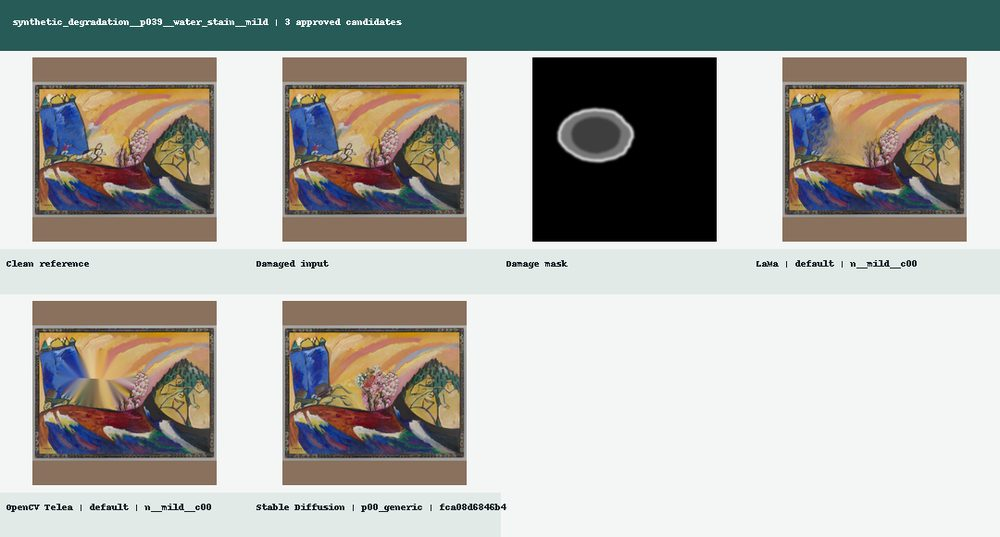

Rendered the in-memory representative report above.
The complete report will replace structural smoke text with canonical tables, figures, findings, assertions, and limitations.
The representative grid is embedded directly and does not depend on an external image link.


In [16]:
display(HTML(SMOKE_REPORT_HTML))

print(
    "Rendered the in-memory representative report above."
)
print(
    "The complete report will replace structural smoke text with "
    "canonical tables, figures, findings, assertions, and limitations."
)
print(
    "The representative grid is embedded directly and does not "
    "depend on an external image link."
)

In [17]:
CURRENT_OUTPUT_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

VALIDATION.add(
    validation_stage="batch_3_completion",
    check_id="no_smoke_artifact_persistence",
    check_description=(
        "The representative smoke test persisted no output files."
    ),
    severity="blocking",
    expected=[],
    observed=CURRENT_OUTPUT_FILES,
    passed=not CURRENT_OUTPUT_FILES,
    details=(
        "The smoke report must remain an in-memory notebook rendering."
    ),
)

BATCH_3_VALIDATION = VALIDATION.to_dataframe()
BATCH_3_SUMMARY = VALIDATION.summary()

BATCH_3_STAGE_SUMMARY = (
    BATCH_3_VALIDATION.groupby(
        ["validation_stage", "severity", "passed"],
        dropna=False,
    )
    .size()
    .reset_index(name="check_count")
    .sort_values(
        ["validation_stage", "severity", "passed"],
        kind="stable",
    )
)

BATCH_3_FAILURES = BATCH_3_VALIDATION.loc[
    ~BATCH_3_VALIDATION["passed"].astype(bool)
].copy()

display(BATCH_3_STAGE_SUMMARY)

if not BATCH_3_FAILURES.empty:
    display(
        BATCH_3_FAILURES[
            [
                "validation_stage",
                "check_id",
                "severity",
                "expected",
                "observed",
                "details",
            ]
        ]
    )

VALIDATION.raise_for_blocking()

BATCH_3_ADDED_CHECKS = (
    len(BATCH_3_VALIDATION)
    - len(BATCH_2_VALIDATION)
)

print("Batch 3 passed.")
print(f"Checks added by Batch 3: {BATCH_3_ADDED_CHECKS}")
print(
    f"Cumulative validation checks: "
    f"{BATCH_3_SUMMARY['check_count']}"
)
print(
    f"Cumulative blocking failures: "
    f"{BATCH_3_SUMMARY['blocking_failure_count']}"
)
print(f"Smoke report sections: {len(SMOKE_REPORT_SECTIONS)}")
print("Smoke report embedded images: 1")
print("Smoke report external image dependencies: 0")
print(f"Notebook 33 output files: {len(CURRENT_OUTPUT_FILES)}")
print(
    "Full-report image and tile density remains deferred to the "
    "complete report assembly."
)

,validation_stage,severity,passed,check_count
0,batch_1_contract,blocking,True,5
1,batch_2_completion,blocking,True,1
2,batch_2_cross_table,blocking,True,8
3,batch_2_input_loading,blocking,True,165
4,batch_2_population,blocking,True,16
5,batch_2_report_indexes,blocking,True,4
6,batch_2_source_catalog,blocking,True,3
7,batch_3_completion,blocking,True,1
8,batch_3_report_smoke,blocking,True,9
9,batch_3_schema_smoke,blocking,True,3


Batch 3 passed.
Checks added by Batch 3: 16
Cumulative validation checks: 429
Cumulative blocking failures: 0
Smoke report sections: 19
Smoke report embedded images: 1
Smoke report external image dependencies: 0
Notebook 33 output files: 0
Full-report image and tile density remains deferred to the complete report assembly.


## Batch 4 — Full canonical table synthesis

This batch performs the complete presentation-only construction of the final report tables.

It builds:

- 4 research-question mapping rows;
- 8 dataset and population rows;
- 4 model-coverage rows;
- 33 canonical quality-anchor rows;
- 11 metric-disagreement rows;
- 33 damage-size rows;
- 33 mask-robustness rows;
- 33 synthetic-degradation rows;
- 8 uncertainty and applicability rows;
- 22 grouped-statistical and runtime-association rows;
- 44 model-by-flag rows;
- 23 ablation-scenario rows;
- 7 explainability and retrieval rows;
- 12 compute and scalability rows;
- 18 limitation and deviation rows.

This produces exactly 293 thesis-table rows across 15 tables. A complete LaTeX-ready representation is then generated for every table.

The batch only selects, reshapes, summarizes, and labels completed upstream evidence. It does not recompute restoration metrics, statistical tests, rankings, uncertainty, flags, or model outputs.

Canonical files are not persisted yet. Persistence and reload validation occur in the following batch.

In [18]:
import importlib

import restoration_eval.final_evaluation_report as final_report_helper


# Reload because the helper gained the fully tested table builders after
# this notebook kernel originally imported version 1.0.0.
final_report_helper = importlib.reload(
    final_report_helper
)

MODULE_VERSION = final_report_helper.MODULE_VERSION
THESIS_TABLE_COLUMNS = (
    final_report_helper.THESIS_TABLE_COLUMNS
)
LATEX_TABLE_COLUMNS = (
    final_report_helper.LATEX_TABLE_COLUMNS
)

if MODULE_VERSION != "1.1.0":
    raise RuntimeError(
        "Expected final-report helper version 1.1.0, "
        f"observed {MODULE_VERSION}."
    )

print("Final-report helper reloaded.")
print(f"Active helper version: {MODULE_VERSION}")
print(
    "Available full builders: "
    "build_final_thesis_tables, "
    "build_final_latex_tables, validate_final_tables"
)

Final-report helper reloaded.
Active helper version: 1.1.0
Available full builders: build_final_thesis_tables, build_final_latex_tables, validate_final_tables


In [19]:
THESIS_TABLES = (
    final_report_helper.build_final_thesis_tables(
        SOURCE_TABLES,
        CONFIG,
    )
)

print(
    "Canonical thesis-table construction complete: "
    f"{len(THESIS_TABLES):,} rows."
)

LATEX_TABLES = (
    final_report_helper.build_final_latex_tables(
        THESIS_TABLES,
        CONFIG,
    )
)

print(
    "LaTeX-table construction complete: "
    f"{len(LATEX_TABLES)} records."
)


FINAL_TABLE_CHECKS = (
    final_report_helper.validate_final_tables(
        THESIS_TABLES,
        LATEX_TABLES,
        CONFIG,
    )
)

final_report_helper.append_validation_checks(
    VALIDATION,
    FINAL_TABLE_CHECKS,
)

VALIDATION.raise_for_blocking()

display(
    FINAL_TABLE_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("All canonical table-construction checks passed.")

Canonical thesis-table construction complete: 293 rows.
LaTeX-table construction complete: 15 records.


,check_name,expected,observed,passed
0,thesis column order,"[""table_row_id"", ""table_id"", ""table_order"", ""s...","[""table_row_id"", ""table_id"", ""table_order"", ""s...",True
1,latex column order,"[""latex_table_id"", ""table_id"", ""table_order"", ...","[""latex_table_id"", ""table_id"", ""table_order"", ...",True
2,thesis row count,293,293,True
3,latex row count,15,15,True
4,table row allocation,"{""t01_research_question_map"": 4, ""t02_dataset_...","{""t01_research_question_map"": 4, ""t02_dataset_...",True
5,thesis row identifiers,293,293,True
6,latex identifiers,15,15,True
7,JSON payloads,[],[],True
8,thesis schema versions,"[""thesis_tables.v1""]","[""thesis_tables.v1""]",True
9,latex schema versions,"[""latex_tables.v1""]","[""latex_tables.v1""]",True


All canonical table-construction checks passed.


In [20]:
EXPECTED_TABLE_COUNTS = {
    str(item["table_id"]): int(item["expected_rows"])
    for item in SETTINGS["table_plan"]
}

OBSERVED_TABLE_COUNTS = (
    THESIS_TABLES.groupby(
        [
            "table_order",
            "table_id",
            "section_id",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "observed_rows"})
)

OBSERVED_TABLE_COUNTS["expected_rows"] = (
    OBSERVED_TABLE_COUNTS["table_id"].map(
        EXPECTED_TABLE_COUNTS
    )
)

OBSERVED_TABLE_COUNTS["passed"] = (
    OBSERVED_TABLE_COUNTS["observed_rows"]
    == OBSERVED_TABLE_COUNTS["expected_rows"]
)

VALIDATION.add(
    validation_stage="batch_4_table_synthesis",
    check_id="all_table_allocations_passed",
    check_description=(
        "Every final table has its exact approved row allocation."
    ),
    severity="blocking",
    expected=True,
    observed=bool(
        OBSERVED_TABLE_COUNTS["passed"].all()
    ),
    passed=bool(
        OBSERVED_TABLE_COUNTS["passed"].all()
    ),
    details=(
        "The 15 table allocations must total exactly 293 rows."
    ),
)

VALIDATION.add(
    validation_stage="batch_4_table_synthesis",
    check_id="table_order_contiguous",
    check_description=(
        "Final table order is contiguous from 1 through 15."
    ),
    severity="blocking",
    expected=list(range(1, 16)),
    observed=sorted(
        THESIS_TABLES["table_order"].unique().tolist()
    ),
    passed=(
        sorted(
            THESIS_TABLES["table_order"].unique().tolist()
        )
        == list(range(1, 16))
    ),
    details="Table order must preserve the approved report structure.",
)

VALIDATION.raise_for_blocking()

display(OBSERVED_TABLE_COUNTS)

print(
    "Verified table allocation: "
    f"{OBSERVED_TABLE_COUNTS['observed_rows'].sum()} "
    "rows across "
    f"{len(OBSERVED_TABLE_COUNTS)} tables."
)

,table_order,table_id,section_id,observed_rows,expected_rows,passed
0,1,t01_research_question_map,research-questions,4,4,True
1,2,t02_dataset_design_scope,dataset-design,8,8,True
2,3,t03_model_coverage,methods-coverage,4,4,True
3,4,t04_quality_anchor_summary,canonical-comparison,33,33,True
4,5,t05_metric_disagreement,canonical-comparison,11,11,True
5,6,t06_damage_size,damage-size,33,33,True
6,7,t07_mask_robustness,mask-robustness,33,33,True
7,8,t08_synthetic_degradation,synthetic-degradation,33,33,True
8,9,t09_uncertainty,diffusion-uncertainty,8,8,True
9,10,t10_grouped_statistics,grouped-statistics,22,22,True


Verified table allocation: 293 rows across 15 tables.


In [21]:
SOURCE_REFERENCE_RECORDS: list[dict[str, object]] = []

for row in THESIS_TABLES.to_dict(orient="records"):
    source_paths = json.loads(
        str(row["source_paths_json"])
    )

    for relative_path in source_paths:
        candidate_path = Path(str(relative_path))

        resolved_path = (
            candidate_path.resolve()
            if candidate_path.is_absolute()
            else (PROJECT_ROOT / candidate_path).resolve()
        )

        inside_repository = (
            resolved_path == PROJECT_ROOT
            or PROJECT_ROOT in resolved_path.parents
        )

        SOURCE_REFERENCE_RECORDS.append(
            {
                "table_row_id": row["table_row_id"],
                "table_id": row["table_id"],
                "relative_path": str(relative_path),
                "inside_repository": inside_repository,
                "exists": resolved_path.exists(),
            }
        )


SOURCE_REFERENCE_AUDIT = (
    pd.DataFrame(SOURCE_REFERENCE_RECORDS)
    .drop_duplicates(
        [
            "table_id",
            "relative_path",
        ]
    )
    .sort_values(
        [
            "table_id",
            "relative_path",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

MISSING_TABLE_SOURCES = SOURCE_REFERENCE_AUDIT.loc[
    ~SOURCE_REFERENCE_AUDIT["exists"],
    "relative_path",
].drop_duplicates().tolist()

OUTSIDE_REPOSITORY_SOURCES = SOURCE_REFERENCE_AUDIT.loc[
    ~SOURCE_REFERENCE_AUDIT["inside_repository"],
    "relative_path",
].drop_duplicates().tolist()

VALIDATION.add(
    validation_stage="batch_4_table_provenance",
    check_id="table_source_files_exist",
    check_description=(
        "Every source path cited by the final tables exists."
    ),
    severity="blocking",
    expected=[],
    observed=MISSING_TABLE_SOURCES,
    passed=not MISSING_TABLE_SOURCES,
    details=(
        "Every final-table claim must retain an existing canonical "
        "source path."
    ),
)

VALIDATION.add(
    validation_stage="batch_4_table_provenance",
    check_id="table_sources_repository_confined",
    check_description=(
        "Every cited source remains inside the repository."
    ),
    severity="blocking",
    expected=[],
    observed=OUTSIDE_REPOSITORY_SOURCES,
    passed=not OUTSIDE_REPOSITORY_SOURCES,
    details=(
        "Final-table provenance may not reference paths outside "
        "the repository."
    ),
)

VALIDATION.raise_for_blocking()

display(SOURCE_REFERENCE_AUDIT)

print(
    "Distinct table/source references checked: "
    f"{len(SOURCE_REFERENCE_AUDIT)}"
)
print("All final-table source references exist.")

,table_row_id,table_id,relative_path,inside_repository,exists
0,thesis_1f231112ce9c23a1f43645c3,t01_research_question_map,config/evaluation/evidence_coverage.yaml,True,True
1,thesis_1f231112ce9c23a1f43645c3,t01_research_question_map,docs/proposal/Rahul_Thesis_Proposal.docx,True,True
2,thesis_505c81a48f025333928a4028,t02_dataset_design_scope,outputs/01_dataset_verification/data/artworks.csv,True,True
3,thesis_53b8911ede289e5df49045a8,t02_dataset_design_scope,outputs/08_experiment_contracts_and_region_pol...,True,True
4,thesis_5ce08ec993361d59f33343a1,t02_dataset_design_scope,outputs/29_explainable_ai_and_case_retrieval/d...,True,True
5,thesis_fa5fb7a67d85ce23ed0e9f03,t03_model_coverage,outputs/30_model_cards_compute_and_scalability...,True,True
6,thesis_a7139152855eddcb5f6d8322,t04_quality_anchor_summary,outputs/21_multi_model_comparison/metrics/mode...,True,True
7,thesis_a8f0c14c046391941956e083,t05_metric_disagreement,outputs/21_multi_model_comparison/metrics/metr...,True,True
8,thesis_bf95b2b95acc732630d8c6d7,t06_damage_size,outputs/23_damage_size_sensitivity_analysis/me...,True,True
9,thesis_50d16eeb94c85f08da6e7691,t07_mask_robustness,outputs/24_mask_robustness_analysis/metrics/ma...,True,True


Distinct table/source references checked: 25
All final-table source references exist.


In [22]:
TABLE_PREVIEW_RECORDS: list[dict[str, object]] = []

for table_id, subset in THESIS_TABLES.groupby(
    "table_id",
    sort=False,
):
    first_row = subset.sort_values(
        "row_order",
        kind="stable",
    ).iloc[0]

    values = json.loads(
        str(first_row["values_json"])
    )

    compact_values = json.dumps(
        dict(list(values.items())[:5]),
        ensure_ascii=False,
        sort_keys=True,
    )

    TABLE_PREVIEW_RECORDS.append(
        {
            "table_order": int(first_row["table_order"]),
            "table_id": table_id,
            "section_id": first_row["section_id"],
            "row_count": len(subset),
            "first_row_label": first_row["row_label"],
            "first_row_values": compact_values,
            "applicability_status": (
                first_row["applicability_status"]
            ),
        }
    )


TABLE_PREVIEW = (
    pd.DataFrame(TABLE_PREVIEW_RECORDS)
    .sort_values(
        "table_order",
        kind="stable",
    )
    .reset_index(drop=True)
)

LATEX_TABLE_AUDIT = LATEX_TABLES[
    [
        "table_order",
        "table_id",
        "section_id",
        "source_row_count",
        "caption",
        "status",
    ]
].sort_values(
    "table_order",
    kind="stable",
)

display(TABLE_PREVIEW)
display(LATEX_TABLE_AUDIT)

print(
    "Every final table is represented in both the canonical "
    "thesis table and LaTeX catalog."
)

,table_order,table_id,section_id,row_count,first_row_label,first_row_values,applicability_status
0,1,t01_research_question_map,research-questions,4,Multi-metric evaluation beyond traditional ima...,"{""evidence_status"": ""addressed_by_completed_up...",supported
1,2,t02_dataset_design_scope,dataset-design,8,Controlled paintings,"{""count"": 50, ""unit"": ""painting""}",supported
2,3,t03_model_coverage,methods-coverage,4,LaMa,"{""deterministic"": true, ""evaluated_candidate_c...",supported
3,4,t04_quality_anchor_summary,canonical-comparison,33,classical_masked_mae — lama,"{""aggregate_rank"": 1.0, ""directional_utility_m...",supported
4,5,t05_metric_disagreement,canonical-comparison,11,classical_masked_mae,"{""agrees_with_majority_vote"": true, ""loo_winne...",supported
5,6,t06_damage_size,damage-size,33,classical_masked_mae — lama,"{""adverse_slope"": 4.160812494091164, ""ci_lower...",applicable
6,7,t07_mask_robustness,mask-robustness,33,classical_masked_mae — lama,"{""ci_lower"": 0.7082923093753415, ""ci_upper"": 1...",applicable
7,8,t08_synthetic_degradation,synthetic-degradation,33,classical_masked_mae — lama,"{""ci_lower"": -15.731009400751072, ""ci_upper"": ...",applicable
8,9,t09_uncertainty,diffusion-uncertainty,8,canonical_uncertainty,"{""estimate"": 130.0, ""interpretation_status"": ""...",supported
9,10,t10_grouped_statistics,grouped-statistics,22,Omnibus model difference — boundary_gradient_m...,"{""effect_size"": 0.9615999999999996, ""effect_si...",supported


,table_order,table_id,section_id,source_row_count,caption,status
0,1,t01_research_question_map,research-questions,4,T01 Research Question Map,ok
1,2,t02_dataset_design_scope,dataset-design,8,T02 Dataset Design Scope,ok
2,3,t03_model_coverage,methods-coverage,4,T03 Model Coverage,ok
3,4,t04_quality_anchor_summary,canonical-comparison,33,T04 Quality Anchor Summary,ok
4,5,t05_metric_disagreement,canonical-comparison,11,T05 Metric Disagreement,ok
5,6,t06_damage_size,damage-size,33,T06 Damage Size,ok
6,7,t07_mask_robustness,mask-robustness,33,T07 Mask Robustness,ok
7,8,t08_synthetic_degradation,synthetic-degradation,33,T08 Synthetic Degradation,ok
8,9,t09_uncertainty,diffusion-uncertainty,8,T09 Uncertainty,ok
9,10,t10_grouped_statistics,grouped-statistics,22,T10 Grouped Statistics,ok


Every final table is represented in both the canonical thesis table and LaTeX catalog.


In [23]:
from IPython.display import Markdown


LATEX_PREVIEW_ROW = LATEX_TABLES.loc[
    LATEX_TABLES["table_id"].eq(
        "t04_quality_anchor_summary"
    )
].iloc[0]

display(
    Markdown(
        "### LaTeX preview — canonical quality-anchor table\n\n"
        "```latex\n"
        + str(LATEX_PREVIEW_ROW["latex"])
        + "\n```"
    )
)

print(
    "Displayed the complete LaTeX representation for "
    "t04_quality_anchor_summary."
)
print(
    f"Source rows represented: "
    f"{LATEX_PREVIEW_ROW['source_row_count']}"
)

### LaTeX preview — canonical quality-anchor table

```latex
\begin{tabular}{lll}
\toprule
Item & Scope & Evidence \\
\midrule
classical\_masked\_mae — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=-14.53696522065778; eligible\_case\_count=410; metric\_name=mae; paired\_painting\_count=50 \\
classical\_masked\_mae — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=-17.257852179225452; eligible\_case\_count=410; metric\_name=mae; paired\_painting\_count=50 \\
classical\_masked\_mae — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=-28.98940231093193; eligible\_case\_count=410; metric\_name=mae; paired\_painting\_count=50 \\
colour\_masked\_delta\_e — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=-6.930978709459305; eligible\_case\_count=410; metric\_name=delta\_e\_ciede2000\_mean; paired\_painting\_count=50 \\
colour\_masked\_delta\_e — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=-7.858020424346129; eligible\_case\_count=410; metric\_name=delta\_e\_ciede2000\_mean; paired\_painting\_count=50 \\
colour\_masked\_delta\_e — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=-12.95659250749482; eligible\_case\_count=410; metric\_name=delta\_e\_ciede2000\_mean; paired\_painting\_count=50 \\
feature\_clip\_crop — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=0.956540463036961; eligible\_case\_count=410; metric\_name=clip\_cosine\_similarity; paired\_painting\_count=50 \\
feature\_clip\_crop — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=0.9430512779288822; eligible\_case\_count=410; metric\_name=clip\_cosine\_similarity; paired\_painting\_count=50 \\
feature\_clip\_crop — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=0.8862784357534514; eligible\_case\_count=410; metric\_name=clip\_cosine\_similarity; paired\_painting\_count=50 \\
feature\_dino\_crop — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=0.871590207848284; eligible\_case\_count=410; metric\_name=dinov2\_cosine\_similarity; paired\_painting\_count=50 \\
feature\_dino\_crop — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=0.8477974949197636; eligible\_case\_count=410; metric\_name=dinov2\_cosine\_similarity; paired\_painting\_count=50 \\
feature\_dino\_crop — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=0.6966262116433225; eligible\_case\_count=410; metric\_name=dinov2\_cosine\_similarity; paired\_painting\_count=50 \\
perceptual\_crop\_lpips — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=-0.1250970119762415; eligible\_case\_count=410; metric\_name=lpips; paired\_painting\_count=50 \\
perceptual\_crop\_lpips — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=-0.1824332894188248; eligible\_case\_count=410; metric\_name=lpips; paired\_painting\_count=50 \\
perceptual\_crop\_lpips — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=-0.1863912437963437; eligible\_case\_count=410; metric\_name=lpips; paired\_painting\_count=50 \\
seam\_boundary\_gradient — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=-0.0064141680075812; eligible\_case\_count=410; metric\_name=boundary\_gradient\_mismatch; paired\_painting\_count=50 \\
seam\_boundary\_gradient — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=-0.0075863096766018; eligible\_case\_count=410; metric\_name=boundary\_gradient\_mismatch; paired\_painting\_count=50 \\
seam\_boundary\_gradient — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=-0.019966133123186; eligible\_case\_count=410; metric\_name=boundary\_gradient\_mismatch; paired\_painting\_count=50 \\
semantic\_local\_dino — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=0.7999263522469737; eligible\_case\_count=410; metric\_name=local\_patch\_cosine\_similarity; paired\_painting\_count=50 \\
semantic\_local\_dino — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=0.6709434540772683; eligible\_case\_count=410; metric\_name=local\_patch\_cosine\_similarity; paired\_painting\_count=50 \\
semantic\_local\_dino — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=0.6030095167696147; eligible\_case\_count=410; metric\_name=local\_patch\_cosine\_similarity; paired\_painting\_count=50 \\
spatial\_masked\_error — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=-14.536965220570474; eligible\_case\_count=410; metric\_name=restored\_error\_mean; paired\_painting\_count=50 \\
spatial\_masked\_error — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=-17.257852179759233; eligible\_case\_count=410; metric\_name=restored\_error\_mean; paired\_painting\_count=50 \\
spatial\_masked\_error — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=-28.989402311238877; eligible\_case\_count=410; metric\_name=restored\_error\_mean; paired\_painting\_count=50 \\
structural\_affinity\_correlation — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=0.9557790892337494; eligible\_case\_count=410; metric\_name=reference\_affinity\_map\_correlation; paired\_painting\_count=50 \\
structural\_affinity\_correlation — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=0.8750915878692894; eligible\_case\_count=410; metric\_name=reference\_affinity\_map\_correlation; paired\_painting\_count=50 \\
structural\_affinity\_correlation — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=0.853690410412344; eligible\_case\_count=410; metric\_name=reference\_affinity\_map\_correlation; paired\_painting\_count=50 \\
structural\_crop\_ssim — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=0.8722354561410599; eligible\_case\_count=410; metric\_name=ssim; paired\_painting\_count=50 \\
structural\_crop\_ssim — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=0.8703976975178176; eligible\_case\_count=410; metric\_name=ssim; paired\_painting\_count=50 \\
structural\_crop\_ssim — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=0.8252838429185452; eligible\_case\_count=410; metric\_name=ssim; paired\_painting\_count=50 \\
texture\_crop\_p95 — lama & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=1.0; directional\_utility\_mean=-0.4333334911865634; eligible\_case\_count=410; metric\_name=local\_texture\_error\_p95; paired\_painting\_count=50 \\
texture\_crop\_p95 — opencv\_telea & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=2.0; directional\_utility\_mean=-0.6316105618321638; eligible\_case\_count=410; metric\_name=local\_texture\_error\_p95; paired\_painting\_count=50 \\
texture\_crop\_p95 — stable\_diffusion\_inpainting & core\_three\_model\_overall\_nonzero\_cases & aggregate\_rank=3.0; directional\_utility\_mean=-2.192887899248871; eligible\_case\_count=410; metric\_name=local\_texture\_error\_p95; paired\_painting\_count=50 \\
\bottomrule
\end{tabular}

```

Displayed the complete LaTeX representation for t04_quality_anchor_summary.
Source rows represented: 33


In [24]:
CURRENT_OUTPUT_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

VALIDATION.add(
    validation_stage="batch_4_completion",
    check_id="no_table_files_before_persistence",
    check_description=(
        "Batch 4 retained canonical table products in memory."
    ),
    severity="blocking",
    expected=[],
    observed=CURRENT_OUTPUT_FILES,
    passed=not CURRENT_OUTPUT_FILES,
    details=(
        "Canonical table files are persisted and reloaded only "
        "after the in-memory products pass validation."
    ),
)

BATCH_4_VALIDATION = VALIDATION.to_dataframe()
BATCH_4_SUMMARY = VALIDATION.summary()

BATCH_4_FAILURES = BATCH_4_VALIDATION.loc[
    ~BATCH_4_VALIDATION["passed"].astype(bool)
].copy()

if not BATCH_4_FAILURES.empty:
    display(
        BATCH_4_FAILURES[
            [
                "validation_stage",
                "check_id",
                "severity",
                "expected",
                "observed",
                "details",
            ]
        ]
    )

VALIDATION.raise_for_blocking()

BATCH_4_ADDED_CHECKS = (
    len(BATCH_4_VALIDATION)
    - len(BATCH_3_VALIDATION)
)

print("Batch 4 passed.")
print(f"Checks added by Batch 4: {BATCH_4_ADDED_CHECKS}")
print(
    f"Cumulative validation checks: "
    f"{BATCH_4_SUMMARY['check_count']}"
)
print(
    f"Cumulative blocking failures: "
    f"{BATCH_4_SUMMARY['blocking_failure_count']}"
)
print(f"Canonical thesis rows: {len(THESIS_TABLES)}")
print(f"Canonical thesis tables: {THESIS_TABLES['table_id'].nunique()}")
print(f"LaTeX table records: {len(LATEX_TABLES)}")
print(f"Notebook 33 output files: {len(CURRENT_OUTPUT_FILES)}")
print(
    "Canonical table persistence and reload validation are ready "
    "for the next batch."
)

Batch 4 passed.
Checks added by Batch 4: 17
Cumulative validation checks: 446
Cumulative blocking failures: 0
Canonical thesis rows: 293
Canonical thesis tables: 15
LaTeX table records: 15
Notebook 33 output files: 0
Canonical table persistence and reload validation are ready for the next batch.


## Batch 5 — Canonical table persistence and reload validation

This batch finalizes the three canonical data products:

- `data/thesis_tables.csv`
- `data/latex_tables.csv`
- `data/report_evidence_catalog.csv`

The evidence catalog contains:

- 48 evidence-backed claim positions;
- 15 table records;
- 18 thesis-figure records;
- 6 publication-figure records;
- 18 limitation records;
- 1 final-report record.

Together these produce exactly 106 catalog records.

All three files are written atomically, reloaded from disk, and checked for:

- exact schemas;
- exact row counts;
- stable row order and identifiers;
- valid JSON fields;
- complete catalog coverage;
- non-empty files;
- absence of temporary write residue.

This batch persists validated presentation products only. It does not compute new scientific evidence.

In [25]:
EVIDENCE_CATALOG = (
    final_report_helper.build_evidence_catalog_plan(
        CONFIG
    ).copy()
)

EVIDENCE_CATALOG["implementation_status"] = "preserved"
EVIDENCE_CATALOG["status"] = "ok"
EVIDENCE_CATALOG["issue"] = ""

EXPECTED_CATALOG_TYPE_COUNTS = {
    "claim": 48,
    "table": 15,
    "thesis_figure": 18,
    "publication_figure": 6,
    "limitation": 18,
    "report": 1,
}

OBSERVED_CATALOG_TYPE_COUNTS = (
    EVIDENCE_CATALOG["record_type"]
    .value_counts()
    .sort_index()
    .to_dict()
)

EXPECTED_CATALOG_TYPE_COUNTS_SORTED = dict(
    sorted(EXPECTED_CATALOG_TYPE_COUNTS.items())
)

OBSERVED_CATALOG_TYPE_COUNTS_SORTED = dict(
    sorted(OBSERVED_CATALOG_TYPE_COUNTS.items())
)

CATALOG_TABLE_IDS = set(
    EVIDENCE_CATALOG.loc[
        EVIDENCE_CATALOG["record_type"].eq("table"),
        "element_id",
    ].astype(str)
)

THESIS_TABLE_IDS = set(
    THESIS_TABLES["table_id"].astype(str)
)

CATALOG_FIGURE_IDS = set(
    EVIDENCE_CATALOG.loc[
        EVIDENCE_CATALOG["record_type"].isin(
            ["thesis_figure", "publication_figure"]
        ),
        "element_id",
    ].astype(str)
)

PLANNED_FIGURE_IDS = set(
    FIGURE_PLAN["figure_id"].astype(str)
)

CATALOG_SECTION_IDS = set(
    EVIDENCE_CATALOG["section_id"].astype(str)
)

APPROVED_SECTION_IDS = set(
    REPORT_SECTION_PLAN["section_id"].astype(str)
)


CATALOG_CHECK_SPECS = [
    (
        "evidence_catalog_row_count",
        "The evidence catalog has its exact approved row count.",
        EXPECTED["evidence_catalog_rows"],
        len(EVIDENCE_CATALOG),
        (
            len(EVIDENCE_CATALOG)
            == int(EXPECTED["evidence_catalog_rows"])
        ),
    ),
    (
        "evidence_catalog_type_counts",
        "Evidence-catalog record types have their approved counts.",
        EXPECTED_CATALOG_TYPE_COUNTS_SORTED,
        OBSERVED_CATALOG_TYPE_COUNTS_SORTED,
        (
            OBSERVED_CATALOG_TYPE_COUNTS_SORTED
            == EXPECTED_CATALOG_TYPE_COUNTS_SORTED
        ),
    ),
    (
        "evidence_catalog_identifiers",
        "Evidence-catalog identifiers are unique.",
        len(EVIDENCE_CATALOG),
        EVIDENCE_CATALOG["catalog_id"].nunique(),
        (
            EVIDENCE_CATALOG["catalog_id"].nunique()
            == len(EVIDENCE_CATALOG)
        ),
    ),
    (
        "evidence_catalog_table_coverage",
        "The evidence catalog covers all final tables.",
        sorted(THESIS_TABLE_IDS),
        sorted(CATALOG_TABLE_IDS),
        CATALOG_TABLE_IDS == THESIS_TABLE_IDS,
    ),
    (
        "evidence_catalog_figure_coverage",
        "The evidence catalog covers all planned figures.",
        sorted(PLANNED_FIGURE_IDS),
        sorted(CATALOG_FIGURE_IDS),
        CATALOG_FIGURE_IDS == PLANNED_FIGURE_IDS,
    ),
    (
        "evidence_catalog_section_coverage",
        "Catalog records use only approved report sections.",
        [],
        sorted(
            CATALOG_SECTION_IDS - APPROVED_SECTION_IDS
        ),
        CATALOG_SECTION_IDS.issubset(
            APPROVED_SECTION_IDS
        ),
    ),
    (
        "evidence_catalog_implementation_state",
        "Every approved mock element remains preserved.",
        ["preserved"],
        sorted(
            EVIDENCE_CATALOG[
                "implementation_status"
            ].unique()
        ),
        set(
            EVIDENCE_CATALOG[
                "implementation_status"
            ]
        )
        == {"preserved"},
    ),
]

for (
    check_id,
    description,
    expected_value,
    observed_value,
    passed,
) in CATALOG_CHECK_SPECS:
    VALIDATION.add(
        validation_stage="batch_5_evidence_catalog",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected_value,
        observed=observed_value,
        passed=bool(passed),
        details=(
            "The final evidence catalog must preserve the approved "
            "mock-to-final report contract."
        ),
    )

VALIDATION.raise_for_blocking()

display(
    pd.DataFrame(
        [
            {
                "record_type": record_type,
                "expected": expected_count,
                "observed": (
                    OBSERVED_CATALOG_TYPE_COUNTS.get(
                        record_type,
                        0,
                    )
                ),
            }
            for record_type, expected_count
            in EXPECTED_CATALOG_TYPE_COUNTS.items()
        ]
    )
)

print(
    f"Evidence catalog prepared: "
    f"{len(EVIDENCE_CATALOG)} records."
)
print("All evidence-catalog coverage checks passed.")

,record_type,expected,observed
0,claim,48,48
1,table,15,15
2,thesis_figure,18,18
3,publication_figure,6,6
4,limitation,18,18
5,report,1,1


Evidence catalog prepared: 106 records.
All evidence-catalog coverage checks passed.


In [26]:
DATA_OUTPUTS_TO_WRITE = [
    (
        "thesis_tables",
        THESIS_TABLES,
        OUTPUT_PATHS["thesis_tables_path"],
    ),
    (
        "latex_tables",
        LATEX_TABLES,
        OUTPUT_PATHS["latex_tables_path"],
    ),
    (
        "report_evidence_catalog",
        EVIDENCE_CATALOG,
        OUTPUT_PATHS["evidence_catalog_path"],
    ),
]

PRE_WRITE_DATA_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_PATHS["thesis_tables_path"]
    .parent
    .glob("*")
    if path.is_file()
)

VALIDATION.add(
    validation_stage="batch_5_persistence",
    check_id="clean_data_directory_before_write",
    check_description=(
        "The Notebook 33 data directory contained no stale files."
    ),
    severity="blocking",
    expected=[],
    observed=PRE_WRITE_DATA_FILES,
    passed=not PRE_WRITE_DATA_FILES,
    details=(
        "Delete the Notebook 33 output root before a clean full "
        "rerun if stale data files are present."
    ),
)

VALIDATION.raise_for_blocking()

for position, (
    artifact_name,
    frame,
    output_path,
) in enumerate(
    DATA_OUTPUTS_TO_WRITE,
    start=1,
):
    final_report_helper.atomic_write_csv(
        frame,
        output_path,
    )

    if not output_path.is_file():
        raise FileNotFoundError(
            f"Atomic write did not create {output_path}"
        )

    print(
        f"Persisted {position}/"
        f"{len(DATA_OUTPUTS_TO_WRITE)}: "
        f"{artifact_name} "
        f"({len(frame):,} rows)"
    )

print("All three canonical data tables were persisted.")

Persisted 1/3: thesis_tables (293 rows)
Persisted 2/3: latex_tables (15 rows)
Persisted 3/3: report_evidence_catalog (106 rows)
All three canonical data tables were persisted.


In [27]:
RELOADED_THESIS_TABLES = pd.read_csv(
    OUTPUT_PATHS["thesis_tables_path"],
    low_memory=False,
    keep_default_na=False,
)

RELOADED_LATEX_TABLES = pd.read_csv(
    OUTPUT_PATHS["latex_tables_path"],
    low_memory=False,
    keep_default_na=False,
)

RELOADED_EVIDENCE_CATALOG = pd.read_csv(
    OUTPUT_PATHS["evidence_catalog_path"],
    low_memory=False,
    keep_default_na=False,
)


RELOAD_TABLE_CHECKS = (
    final_report_helper.validate_final_tables(
        RELOADED_THESIS_TABLES,
        RELOADED_LATEX_TABLES,
        CONFIG,
    ).copy()
)

# These are persisted-output checks, so keep their keys separate
# from the in-memory final-table checks added in Batch 4.
RELOAD_TABLE_CHECKS["validation_stage"] = (
    "batch_5_persisted_tables"
)
RELOAD_TABLE_CHECKS["check_id"] = (
    "reload__"
    + RELOAD_TABLE_CHECKS["check_id"].astype(str)
)
RELOAD_TABLE_CHECKS["check_name"] = (
    "Reloaded: "
    + RELOAD_TABLE_CHECKS["check_name"].astype(str)
)

final_report_helper.append_validation_checks(
    VALIDATION,
    RELOAD_TABLE_CHECKS,
)


RELOAD_IDENTITY_CHECKS = [
    (
        "thesis_row_order_preserved",
        "Reloaded thesis-row identifiers preserve their exact order.",
        THESIS_TABLES["table_row_id"].astype(str).tolist(),
        RELOADED_THESIS_TABLES[
            "table_row_id"
        ].astype(str).tolist(),
    ),
    (
        "latex_row_order_preserved",
        "Reloaded LaTeX identifiers preserve their exact order.",
        LATEX_TABLES["latex_table_id"].astype(str).tolist(),
        RELOADED_LATEX_TABLES[
            "latex_table_id"
        ].astype(str).tolist(),
    ),
    (
        "catalog_row_order_preserved",
        "Reloaded catalog identifiers preserve their exact order.",
        EVIDENCE_CATALOG["catalog_id"].astype(str).tolist(),
        RELOADED_EVIDENCE_CATALOG[
            "catalog_id"
        ].astype(str).tolist(),
    ),
    (
        "thesis_values_preserved",
        "Reloaded thesis JSON values match the in-memory values.",
        THESIS_TABLES["values_json"].astype(str).tolist(),
        RELOADED_THESIS_TABLES[
            "values_json"
        ].astype(str).tolist(),
    ),
    (
        "latex_content_preserved",
        "Reloaded LaTeX source matches the in-memory source.",
        LATEX_TABLES["latex"].astype(str).tolist(),
        RELOADED_LATEX_TABLES[
            "latex"
        ].astype(str).tolist(),
    ),
]

for (
    check_id,
    description,
    expected_values,
    observed_values,
) in RELOAD_IDENTITY_CHECKS:
    VALIDATION.add(
        validation_stage="batch_5_persisted_tables",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=True,
        observed=(
            expected_values == observed_values
        ),
        passed=(
            expected_values == observed_values
        ),
        details=(
            "Atomic CSV persistence must preserve canonical "
            "identifiers, order, and content."
        ),
    )


CATALOG_RELOAD_VALID = (
    list(RELOADED_EVIDENCE_CATALOG.columns)
    == list(
        final_report_helper.EVIDENCE_CATALOG_COLUMNS
    )
    and len(RELOADED_EVIDENCE_CATALOG)
    == int(EXPECTED["evidence_catalog_rows"])
    and RELOADED_EVIDENCE_CATALOG[
        "catalog_id"
    ].nunique()
    == len(RELOADED_EVIDENCE_CATALOG)
)

VALIDATION.add(
    validation_stage="batch_5_persisted_tables",
    check_id="reloaded_evidence_catalog_contract",
    check_description=(
        "The reloaded evidence catalog preserves its schema and count."
    ),
    severity="blocking",
    expected=True,
    observed=CATALOG_RELOAD_VALID,
    passed=CATALOG_RELOAD_VALID,
    details=(
        "The persisted catalog must retain 106 unique schema-valid "
        "records."
    ),
)

VALIDATION.raise_for_blocking()

display(
    RELOAD_TABLE_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("All three canonical data tables reloaded successfully.")

,check_name,expected,observed,passed
0,Reloaded: thesis column order,"[""table_row_id"", ""table_id"", ""table_order"", ""s...","[""table_row_id"", ""table_id"", ""table_order"", ""s...",True
1,Reloaded: latex column order,"[""latex_table_id"", ""table_id"", ""table_order"", ...","[""latex_table_id"", ""table_id"", ""table_order"", ...",True
2,Reloaded: thesis row count,293,293,True
3,Reloaded: latex row count,15,15,True
4,Reloaded: table row allocation,"{""t01_research_question_map"": 4, ""t02_dataset_...","{""t01_research_question_map"": 4, ""t02_dataset_...",True
5,Reloaded: thesis row identifiers,293,293,True
6,Reloaded: latex identifiers,15,15,True
7,Reloaded: JSON payloads,[],[],True
8,Reloaded: thesis schema versions,"[""thesis_tables.v1""]","[""thesis_tables.v1""]",True
9,Reloaded: latex schema versions,"[""latex_tables.v1""]","[""latex_tables.v1""]",True


All three canonical data tables reloaded successfully.


In [28]:
DATA_FILE_AUDIT_RECORDS: list[dict[str, object]] = []

for (
    artifact_name,
    expected_frame,
    output_path,
) in DATA_OUTPUTS_TO_WRITE:
    file_size = (
        output_path.stat().st_size
        if output_path.is_file()
        else 0
    )

    DATA_FILE_AUDIT_RECORDS.append(
        {
            "artifact_name": artifact_name,
            "relative_path": output_path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "expected_rows": len(expected_frame),
            "size_bytes": file_size,
            "sha256": (
                final_report_helper.sha256_path(
                    output_path
                )
                if output_path.is_file()
                else ""
            ),
            "exists": output_path.is_file(),
            "nonempty": file_size > 0,
        }
    )


DATA_FILE_AUDIT = pd.DataFrame(
    DATA_FILE_AUDIT_RECORDS
)

DATA_DIRECTORY_FILES = sorted(
    path.name
    for path in OUTPUT_PATHS["thesis_tables_path"]
    .parent
    .glob("*")
    if path.is_file()
)

EXPECTED_DATA_DIRECTORY_FILES = sorted(
    [
        OUTPUT_PATHS["thesis_tables_path"].name,
        OUTPUT_PATHS["latex_tables_path"].name,
        OUTPUT_PATHS["evidence_catalog_path"].name,
    ]
)

TEMPORARY_WRITE_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*.tmp")
    if path.is_file()
)

VALIDATION.add(
    validation_stage="batch_5_filesystem",
    check_id="canonical_data_file_set",
    check_description=(
        "The data directory contains exactly the three canonical files."
    ),
    severity="blocking",
    expected=EXPECTED_DATA_DIRECTORY_FILES,
    observed=DATA_DIRECTORY_FILES,
    passed=(
        DATA_DIRECTORY_FILES
        == EXPECTED_DATA_DIRECTORY_FILES
    ),
    details="No stale or supplementary CSV should be retained.",
)

VALIDATION.add(
    validation_stage="batch_5_filesystem",
    check_id="canonical_data_files_nonempty",
    check_description=(
        "Every canonical data file is non-empty."
    ),
    severity="blocking",
    expected=True,
    observed=bool(DATA_FILE_AUDIT["nonempty"].all()),
    passed=bool(DATA_FILE_AUDIT["nonempty"].all()),
    details="An empty canonical data artifact is invalid.",
)

VALIDATION.add(
    validation_stage="batch_5_filesystem",
    check_id="atomic_write_residue",
    check_description=(
        "Atomic persistence left no temporary files."
    ),
    severity="blocking",
    expected=[],
    observed=TEMPORARY_WRITE_FILES,
    passed=not TEMPORARY_WRITE_FILES,
    details="Temporary write files must be removed.",
)

VALIDATION.raise_for_blocking()

display(DATA_FILE_AUDIT)

print("Canonical data filesystem validation passed.")

,artifact_name,relative_path,expected_rows,size_bytes,sha256,exists,nonempty
0,thesis_tables,outputs/33_final_evaluation_report/data/thesis...,293,223491,803f663b5b589cecd28244168df5935e7ee07688f0ec11...,True,True
1,latex_tables,outputs/33_final_evaluation_report/data/latex_...,15,82606,696385ce3d98751d6444bc32b8260e1407b7e8ab281153...,True,True
2,report_evidence_catalog,outputs/33_final_evaluation_report/data/report...,106,23975,7db71a0b3f058f05402703f6c00a1eb741c32d16c12a91...,True,True


Canonical data filesystem validation passed.


In [29]:
BATCH_5_VALIDATION = VALIDATION.to_dataframe()
BATCH_5_SUMMARY = VALIDATION.summary()

BATCH_5_FAILURES = BATCH_5_VALIDATION.loc[
    ~BATCH_5_VALIDATION["passed"].astype(bool)
].copy()

if not BATCH_5_FAILURES.empty:
    display(
        BATCH_5_FAILURES[
            [
                "validation_stage",
                "check_id",
                "severity",
                "expected",
                "observed",
                "details",
            ]
        ]
    )

VALIDATION.raise_for_blocking()

BATCH_5_ADDED_CHECKS = (
    len(BATCH_5_VALIDATION)
    - len(BATCH_4_VALIDATION)
)

CURRENT_OUTPUT_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

print("Batch 5 passed.")
print(f"Checks added by Batch 5: {BATCH_5_ADDED_CHECKS}")
print(
    f"Cumulative validation checks: "
    f"{BATCH_5_SUMMARY['check_count']}"
)
print(
    f"Cumulative blocking failures: "
    f"{BATCH_5_SUMMARY['blocking_failure_count']}"
)
print(
    f"Persisted thesis rows: "
    f"{len(RELOADED_THESIS_TABLES)}"
)
print(
    f"Persisted LaTeX records: "
    f"{len(RELOADED_LATEX_TABLES)}"
)
print(
    f"Persisted evidence-catalog records: "
    f"{len(RELOADED_EVIDENCE_CATALOG)}"
)
print(f"Current Notebook 33 output files: {len(CURRENT_OUTPUT_FILES)}")
print(
    "The three canonical data products are persisted, reloaded, "
    "and validated."
)

Batch 5 passed.
Checks added by Batch 5: 29
Cumulative validation checks: 475
Cumulative blocking failures: 0
Persisted thesis rows: 293
Persisted LaTeX records: 15
Persisted evidence-catalog records: 106
Current Notebook 33 output files: 3
The three canonical data products are persisted, reloaded, and validated.


## Batch 6 — Thesis and publication figures

This batch generates the complete approved figure collection:

- 18 thesis figures under `figures/thesis/`;
- 6 compact publication figures under `figures/publication/`.

The figures summarize existing evidence only. They do not calculate new scientific metrics, rankings, or trustworthiness scores.

The collection covers:

- dataset and model coverage;
- canonical model comparison and metric disagreement;
- damage-size sensitivity;
- mask-placement robustness;
- synthetic degradations;
- grouped statistics and metric correlations;
- ranking stability;
- repeated-seed and spatial uncertainty;
- failure flags;
- policy ablations;
- explainability and review recommendations;
- quality, compute, and scalability.

Every figure is validated for its approved identity, location, PNG format, dimensions, file integrity, and directory exclusivity.

In [30]:
import importlib

import restoration_eval.final_evaluation_report as final_report_helper


final_report_helper = importlib.reload(
    final_report_helper
)

MODULE_VERSION = final_report_helper.MODULE_VERSION

if MODULE_VERSION != "1.2.0":
    raise RuntimeError(
        "Expected final-report helper version 1.2.0, "
        f"observed {MODULE_VERSION}."
    )


FIGURE_PLAN = final_report_helper.build_figure_plan(
    CONFIG
)

THESIS_FIGURE_DIR = OUTPUT_PATHS[
    "thesis_figures_dir"
]
PUBLICATION_FIGURE_DIR = OUTPUT_PATHS[
    "publication_figures_dir"
]

PREEXISTING_FIGURE_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for directory in (
        THESIS_FIGURE_DIR,
        PUBLICATION_FIGURE_DIR,
    )
    for path in directory.glob("*")
    if path.is_file()
)

VALIDATION.add(
    validation_stage="batch_6_figure_preflight",
    check_id="clean_figure_directories",
    check_description=(
        "The thesis and publication figure directories "
        "contained no stale files before generation."
    ),
    severity="blocking",
    expected=[],
    observed=PREEXISTING_FIGURE_FILES,
    passed=not PREEXISTING_FIGURE_FILES,
    details=(
        "Delete the Notebook 33 output root before a clean "
        "full rerun if stale figure files are present."
    ),
)

VALIDATION.add(
    validation_stage="batch_6_figure_preflight",
    check_id="approved_figure_plan_count",
    check_description=(
        "The active figure plan contains exactly 24 figures."
    ),
    severity="blocking",
    expected=EXPECTED["persisted_figures"],
    observed=len(FIGURE_PLAN),
    passed=(
        len(FIGURE_PLAN)
        == int(EXPECTED["persisted_figures"])
    ),
    details=(
        "The approved collection contains 18 thesis figures "
        "and 6 publication figures."
    ),
)

VALIDATION.add(
    validation_stage="batch_6_figure_preflight",
    check_id="persisted_tables_available_for_figures",
    check_description=(
        "The reloaded canonical thesis tables are available "
        "for figure generation."
    ),
    severity="blocking",
    expected=EXPECTED["thesis_table_rows"],
    observed=len(RELOADED_THESIS_TABLES),
    passed=(
        len(RELOADED_THESIS_TABLES)
        == int(EXPECTED["thesis_table_rows"])
    ),
    details=(
        "Figures must be generated from the validated "
        "persisted table state."
    ),
)

VALIDATION.add(
    validation_stage="batch_6_figure_preflight",
    check_id="selected_case_grids_available",
    check_description=(
        "All approved representative case grids are available."
    ),
    severity="blocking",
    expected=EXPECTED["selected_case_grids"],
    observed=len(SELECTED_CASE_GRIDS),
    passed=(
        len(SELECTED_CASE_GRIDS)
        == int(EXPECTED["selected_case_grids"])
    ),
    details=(
        "The explainability figure requires the deterministic "
        "12-case visual selection."
    ),
)

VALIDATION.raise_for_blocking()

display(
    FIGURE_PLAN[
        [
            "figure_order",
            "figure_class",
            "figure_id",
            "section_id",
            "filename",
        ]
    ]
)

print("Figure-generation preflight passed.")
print(f"Active helper version: {MODULE_VERSION}")
print(f"Planned figures: {len(FIGURE_PLAN)}")
print(
    "Thesis figures: "
    f"{int(FIGURE_PLAN['figure_class'].eq('thesis').sum())}"
)
print(
    "Publication figures: "
    f"{int(FIGURE_PLAN['figure_class'].eq('publication').sum())}"
)

,figure_order,figure_class,figure_id,section_id,filename
0,1,thesis,f01_framework_evidence_map,research-questions,01_framework_evidence_map.png
1,2,thesis,f02_dataset_experiment_scope,dataset-design,02_dataset_and_experiment_scope.png
2,3,thesis,f03_model_coverage,methods-coverage,03_model_coverage.png
3,4,thesis,f04_canonical_model_comparison,canonical-comparison,04_canonical_model_comparison.png
4,5,thesis,f05_metric_disagreement,canonical-comparison,05_metric_disagreement.png
5,6,thesis,f06_damage_size_sensitivity,damage-size,06_damage_size_sensitivity.png
6,7,thesis,f07_mask_robustness,mask-robustness,07_mask_robustness.png
7,8,thesis,f08_synthetic_degradation,synthetic-degradation,08_synthetic_degradation.png
8,9,thesis,f09_grouped_effects,grouped-statistics,09_grouped_effects.png
9,10,thesis,f10_metric_correlations,grouped-statistics,10_metric_correlations.png


Figure-generation preflight passed.
Active helper version: 1.2.0
Planned figures: 24
Thesis figures: 18
Publication figures: 6


In [31]:
FIGURE_PROGRESS_RECORDS: list[dict[str, object]] = []


def report_figure_progress(
    completed: int,
    total: int,
    figure_id: str,
) -> None:
    FIGURE_PROGRESS_RECORDS.append(
        {
            "completed": completed,
            "total": total,
            "figure_id": figure_id,
        }
    )

    if (
        completed == 1
        or completed % 3 == 0
        or completed == total
    ):
        print(
            f"Generated {completed:>2}/{total} figures: "
            f"{figure_id}"
        )


FIGURE_MANIFEST = (
    final_report_helper.generate_final_figures(
        source_tables=SOURCE_TABLES,
        thesis_tables=RELOADED_THESIS_TABLES,
        selected_case_grids=SELECTED_CASE_GRIDS,
        project_root=PROJECT_ROOT,
        config=CONFIG,
        progress_callback=report_figure_progress,
    )
)

FIGURE_PROGRESS = pd.DataFrame(
    FIGURE_PROGRESS_RECORDS
)

print("Figure generation completed.")
print(f"Generated figure records: {len(FIGURE_MANIFEST)}")
print(
    "Recorded progress events: "
    f"{len(FIGURE_PROGRESS)}"
)

Generated  1/24 figures: f01_framework_evidence_map
Generated  3/24 figures: f03_model_coverage
Generated  6/24 figures: f06_damage_size_sensitivity
Generated  9/24 figures: f09_grouped_effects
Generated 12/24 figures: f12_uncertainty_summary
Generated 15/24 figures: f15_ablation
Generated 18/24 figures: f18_scalability
Generated 21/24 figures: p03_uncertainty_spatial
Generated 24/24 figures: p06_quality_compute
Figure generation completed.
Generated figure records: 24
Recorded progress events: 24


In [32]:
FIGURE_CHECKS = (
    final_report_helper.validate_final_figures(
        FIGURE_MANIFEST,
        PROJECT_ROOT,
        CONFIG,
    )
)

final_report_helper.append_validation_checks(
    VALIDATION,
    FIGURE_CHECKS,
)


EXPECTED_FIGURE_CLASS_COUNTS = {
    "publication": int(
        EXPECTED["publication_figures"]
    ),
    "thesis": int(
        EXPECTED["thesis_figures"]
    ),
}

OBSERVED_FIGURE_CLASS_COUNTS = (
    FIGURE_MANIFEST["figure_class"]
    .value_counts()
    .sort_index()
    .to_dict()
)

VALIDATION.add(
    validation_stage="batch_6_figure_validation",
    check_id="figure_class_allocation",
    check_description=(
        "Generated figures preserve the approved thesis and "
        "publication allocation."
    ),
    severity="blocking",
    expected=EXPECTED_FIGURE_CLASS_COUNTS,
    observed=OBSERVED_FIGURE_CLASS_COUNTS,
    passed=(
        OBSERVED_FIGURE_CLASS_COUNTS
        == EXPECTED_FIGURE_CLASS_COUNTS
    ),
    details=(
        "The collection must contain exactly 18 thesis and "
        "6 publication figures."
    ),
)

VALIDATION.add(
    validation_stage="batch_6_figure_validation",
    check_id="figure_hash_coverage",
    check_description=(
        "Every generated figure has a SHA-256 digest."
    ),
    severity="blocking",
    expected=len(FIGURE_MANIFEST),
    observed=int(
        FIGURE_MANIFEST["sha256"]
        .astype(str)
        .str.fullmatch(r"[0-9a-f]{64}")
        .sum()
    ),
    passed=bool(
        FIGURE_MANIFEST["sha256"]
        .astype(str)
        .str.fullmatch(r"[0-9a-f]{64}")
        .all()
    ),
    details=(
        "Every final figure must be independently verifiable."
    ),
)

VALIDATION.add(
    validation_stage="batch_6_figure_validation",
    check_id="figure_tile_coverage",
    check_description=(
        "The 24 figures contain the expected 34 visual panels."
    ),
    severity="blocking",
    expected=34,
    observed=int(FIGURE_MANIFEST["tile_count"].sum()),
    passed=(
        int(FIGURE_MANIFEST["tile_count"].sum())
        == 34
    ),
    details=(
        "Multi-panel publication figures and spatial montages "
        "must retain their approved panel counts."
    ),
)

VALIDATION.raise_for_blocking()

display(
    FIGURE_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

display(
    FIGURE_MANIFEST[
        [
            "figure_id",
            "figure_class",
            "width",
            "height",
            "size_bytes",
            "tile_count",
            "relative_path",
        ]
    ]
)

print("All generated figures passed structural validation.")

,check_name,expected,observed,passed
0,figure count,24,24,True
1,thesis figure count,18,18,True
2,publication figure count,6,6,True
3,figure identifiers,"[""f01_framework_evidence_map"", ""f02_dataset_ex...","[""f01_framework_evidence_map"", ""f02_dataset_ex...",True
4,figure identifier uniqueness,24,24,True
5,figure files,[],[],True
6,PNG dimensions,[],[],True
7,figure directory file set,"[""outputs/33_final_evaluation_report/figures/p...","[""outputs/33_final_evaluation_report/figures/p...",True


,figure_id,figure_class,width,height,size_bytes,tile_count,relative_path
0,p01_benchmark_summary,publication,1902,781,56232,2,outputs/33_final_evaluation_report/figures/pub...
1,p02_stress_test_summary,publication,2382,781,95114,3,outputs/33_final_evaluation_report/figures/pub...
2,p03_uncertainty_spatial,publication,1664,783,119779,2,outputs/33_final_evaluation_report/figures/pub...
3,p04_trustworthiness_ablation,publication,2054,783,87607,2,outputs/33_final_evaluation_report/figures/pub...
4,p05_explainability,publication,2048,783,246997,2,outputs/33_final_evaluation_report/figures/pub...
5,p06_quality_compute,publication,1262,783,52518,1,outputs/33_final_evaluation_report/figures/pub...
6,f01_framework_evidence_map,thesis,1729,1583,157081,1,outputs/33_final_evaluation_report/figures/the...
7,f02_dataset_experiment_scope,thesis,1734,944,69383,1,outputs/33_final_evaluation_report/figures/the...
8,f03_model_coverage,thesis,1421,780,47926,1,outputs/33_final_evaluation_report/figures/the...
9,f04_canonical_model_comparison,thesis,1262,1102,99282,1,outputs/33_final_evaluation_report/figures/the...


All generated figures passed structural validation.


Preview: f04_canonical_model_comparison


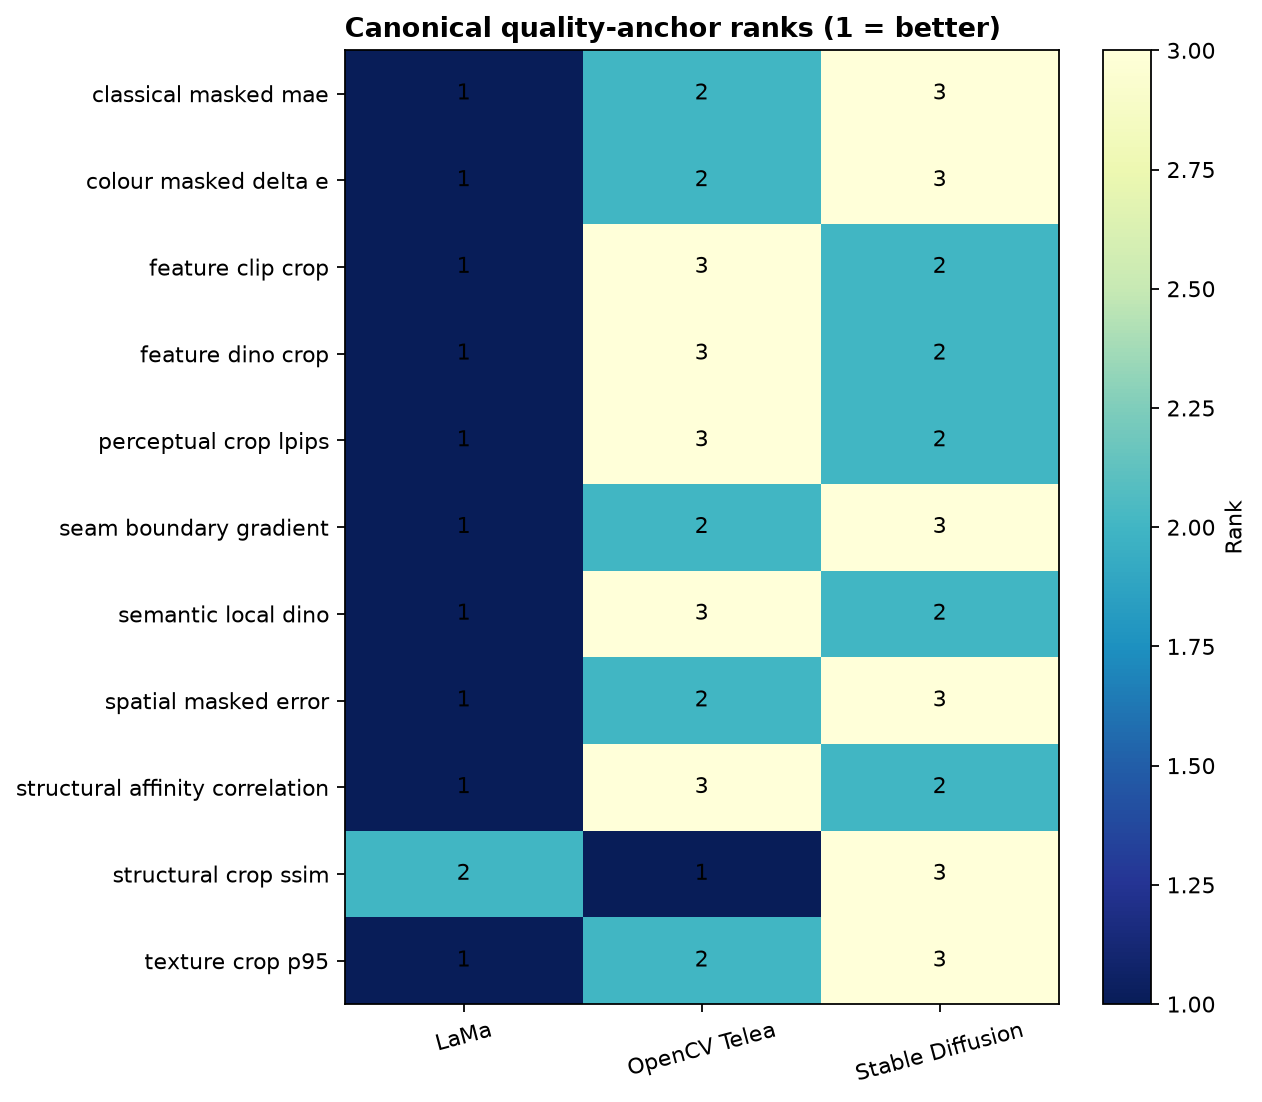

Preview: f06_damage_size_sensitivity


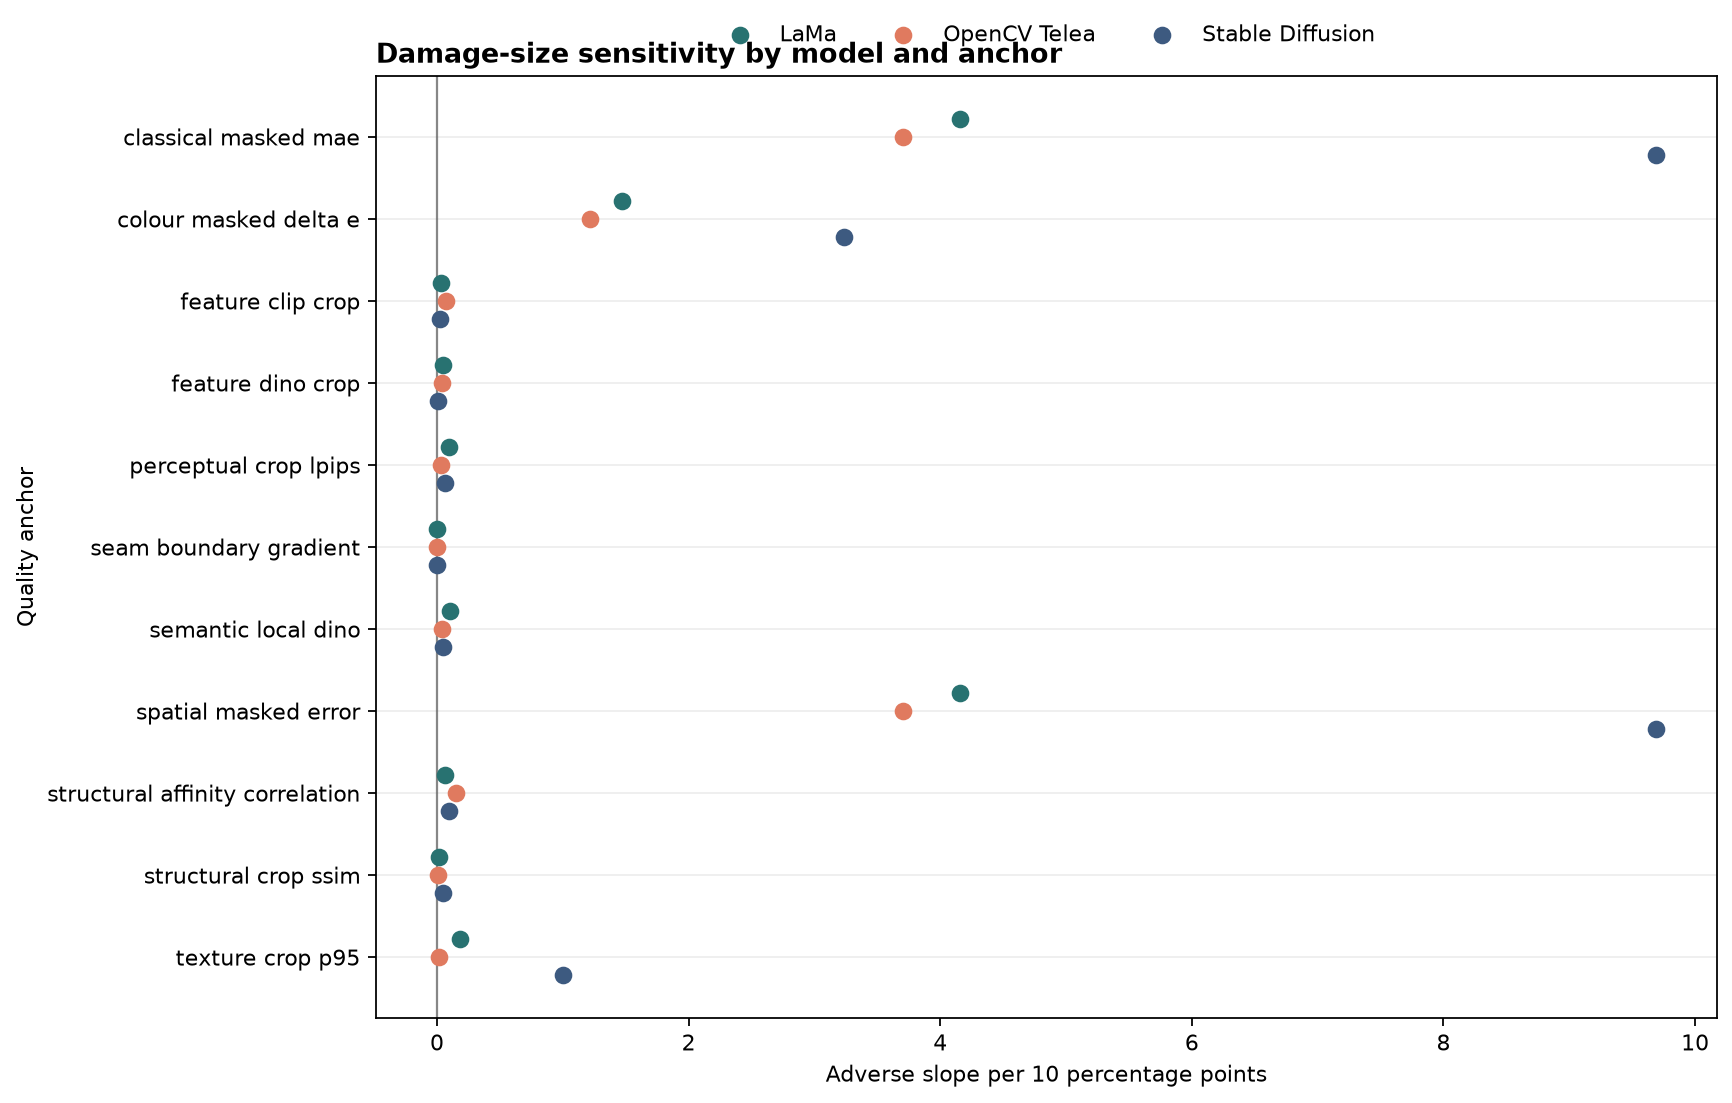

Preview: f13_spatial_uncertainty


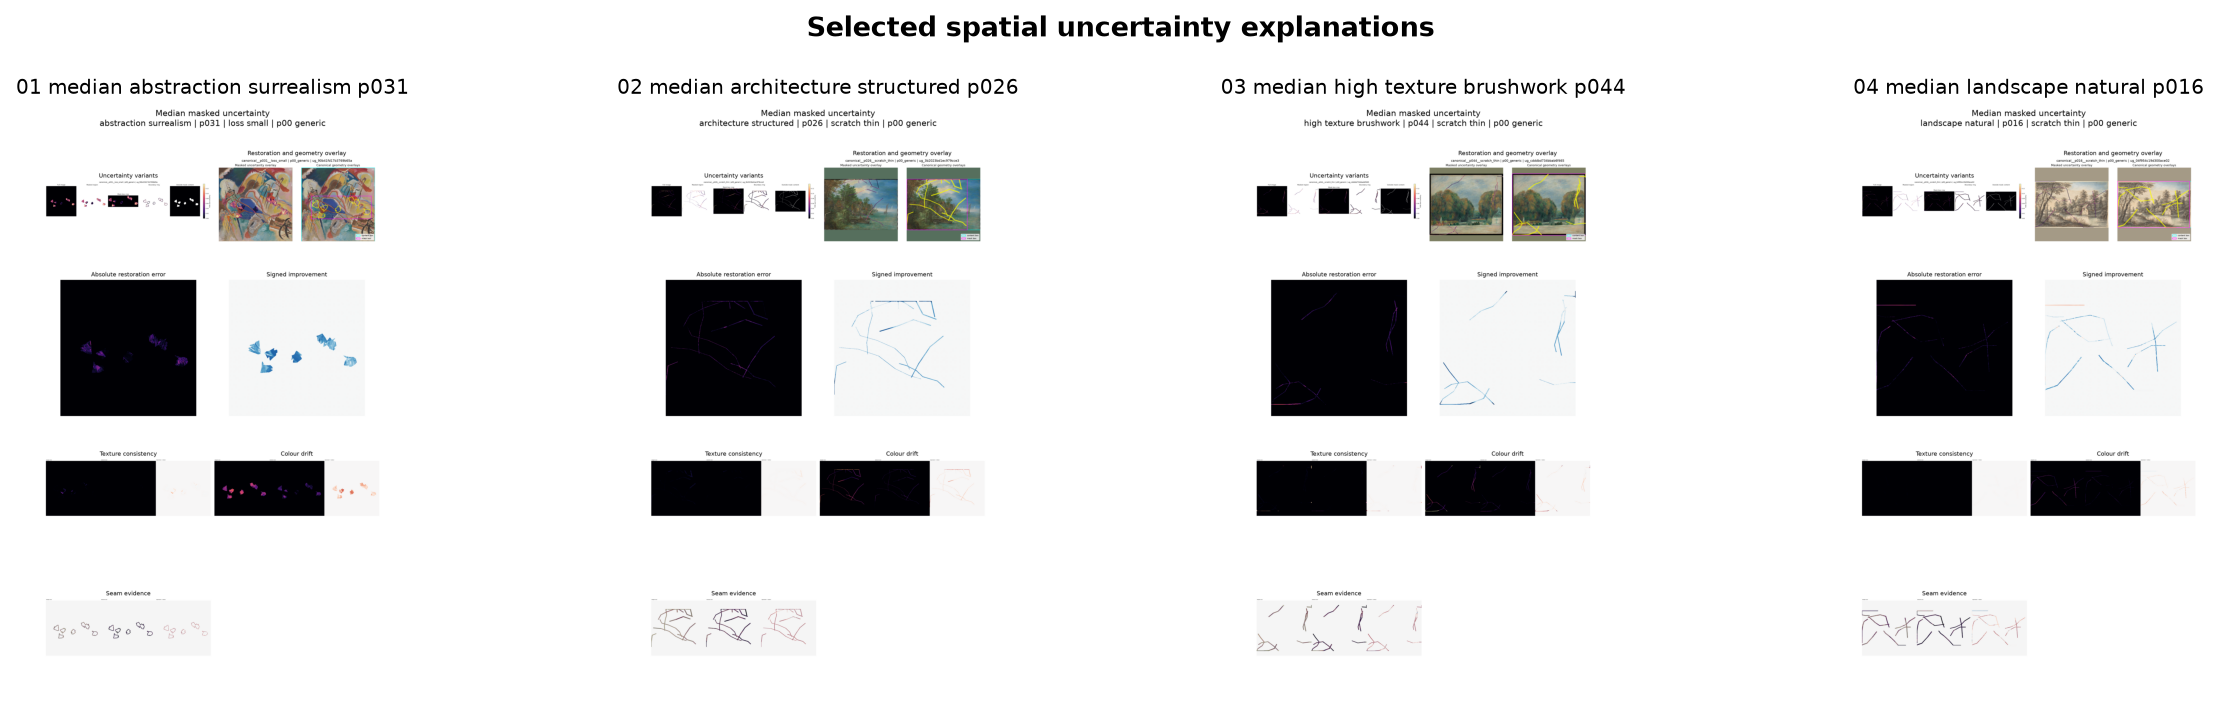

Preview: f14_failure_taxonomy


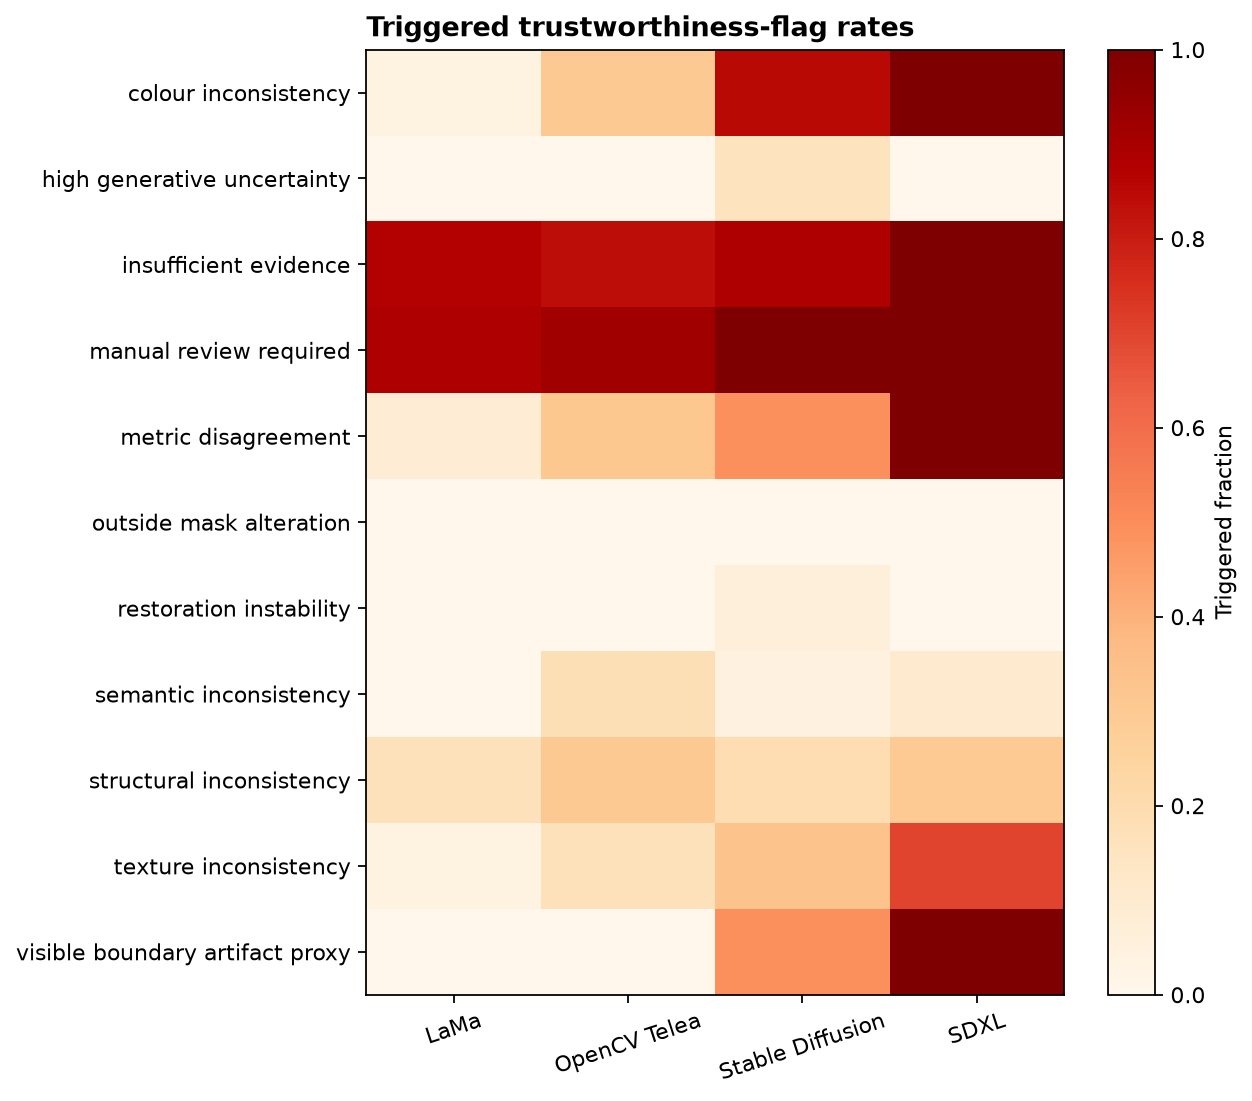

Preview: p01_benchmark_summary


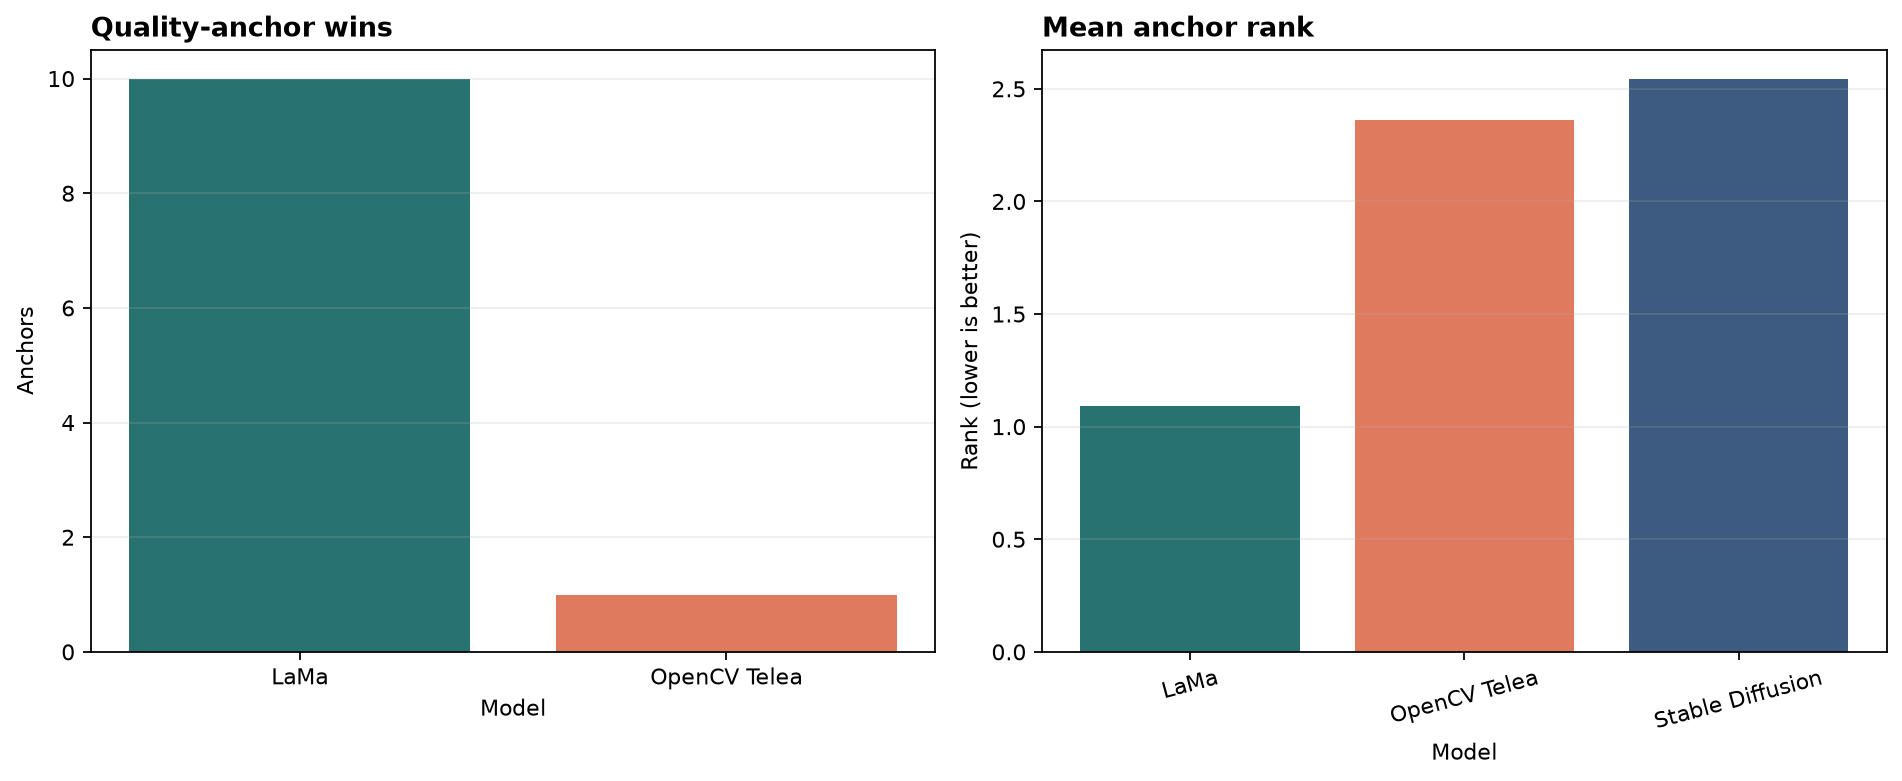

Preview: p03_uncertainty_spatial


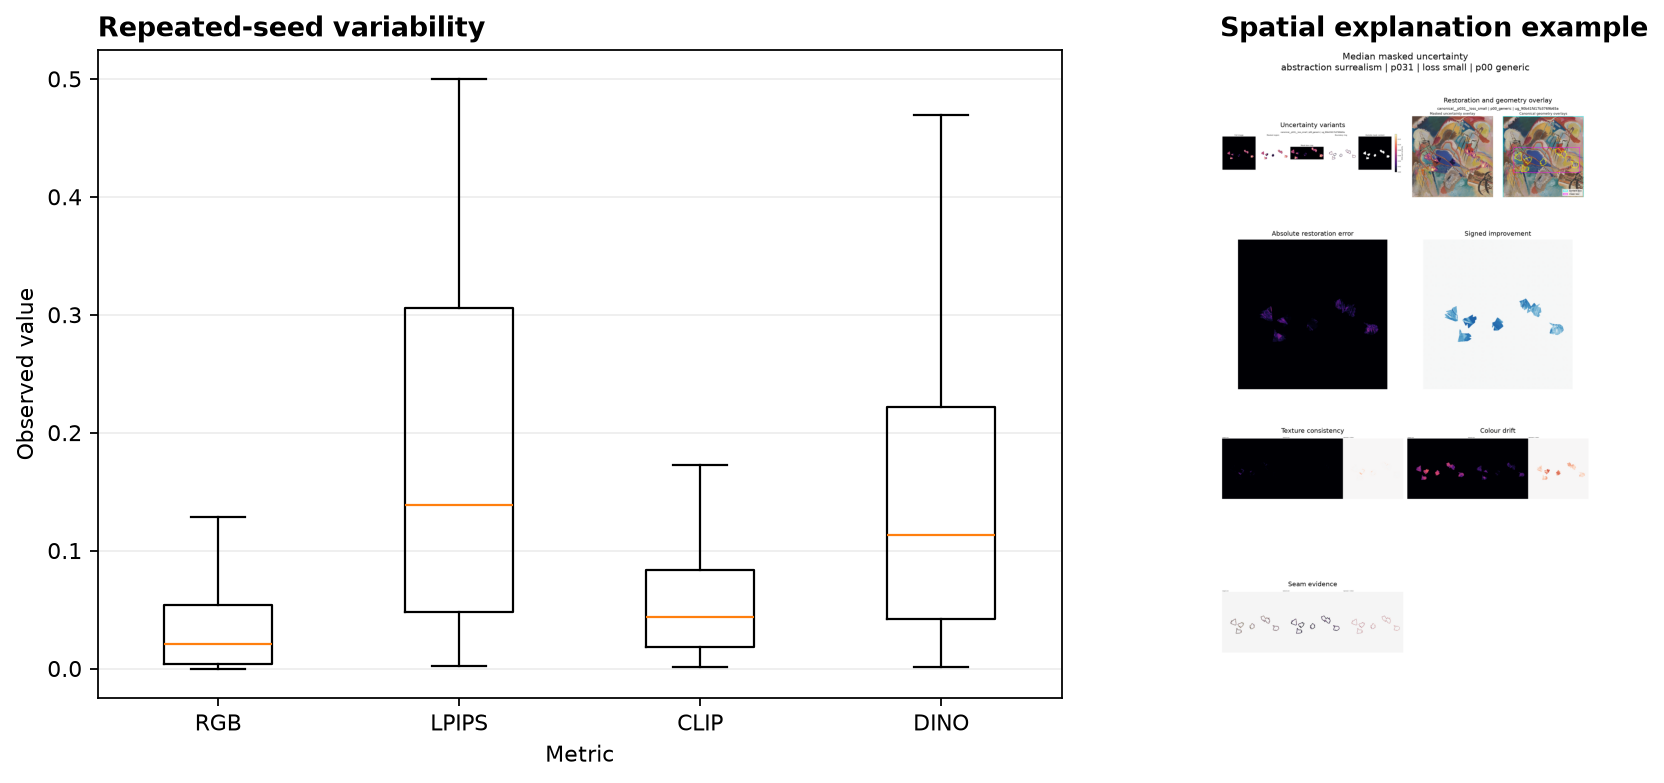

Rendered 6 representative figures for visual inspection.


In [33]:
from IPython.display import Image as NotebookImage


FIGURE_PREVIEW_IDS = [
    "f04_canonical_model_comparison",
    "f06_damage_size_sensitivity",
    "f13_spatial_uncertainty",
    "f14_failure_taxonomy",
    "p01_benchmark_summary",
    "p03_uncertainty_spatial",
]

FIGURE_PATH_LOOKUP = (
    FIGURE_MANIFEST
    .set_index("figure_id")["relative_path"]
    .to_dict()
)

for figure_id in FIGURE_PREVIEW_IDS:
    figure_path = (
        PROJECT_ROOT
        / FIGURE_PATH_LOOKUP[figure_id]
    )

    print(f"Preview: {figure_id}")
    display(
        NotebookImage(
            filename=str(figure_path)
        )
    )

print(
    f"Rendered {len(FIGURE_PREVIEW_IDS)} "
    "representative figures for visual inspection."
)

In [34]:
CURRENT_OUTPUT_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

CURRENT_THESIS_FIGURES = sorted(
    path.name
    for path in THESIS_FIGURE_DIR.glob("*.png")
    if path.is_file()
)

CURRENT_PUBLICATION_FIGURES = sorted(
    path.name
    for path in PUBLICATION_FIGURE_DIR.glob("*.png")
    if path.is_file()
)

TEMPORARY_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*.tmp")
    if path.is_file()
)

WORK_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_PATHS["work_dir"].rglob("*")
    if path.is_file()
)

EXPECTED_CURRENT_OUTPUT_COUNT = (
    3 + int(EXPECTED["persisted_figures"])
)

COMPLETION_CHECKS = [
    (
        "current_output_file_count",
        "The output root contains three data files and "
        "24 generated figures.",
        EXPECTED_CURRENT_OUTPUT_COUNT,
        len(CURRENT_OUTPUT_FILES),
        (
            len(CURRENT_OUTPUT_FILES)
            == EXPECTED_CURRENT_OUTPUT_COUNT
        ),
    ),
    (
        "thesis_figure_directory_count",
        "The thesis figure directory contains 18 PNG files.",
        EXPECTED["thesis_figures"],
        len(CURRENT_THESIS_FIGURES),
        (
            len(CURRENT_THESIS_FIGURES)
            == int(EXPECTED["thesis_figures"])
        ),
    ),
    (
        "publication_figure_directory_count",
        "The publication directory contains 6 PNG files.",
        EXPECTED["publication_figures"],
        len(CURRENT_PUBLICATION_FIGURES),
        (
            len(CURRENT_PUBLICATION_FIGURES)
            == int(EXPECTED["publication_figures"])
        ),
    ),
    (
        "figure_temporary_file_cleanup",
        "Figure generation left no temporary write files.",
        [],
        TEMPORARY_FILES,
        not TEMPORARY_FILES,
    ),
    (
        "figure_work_directory_cleanup",
        "The notebook work directory remains empty.",
        [],
        WORK_FILES,
        not WORK_FILES,
    ),
]

for (
    check_id,
    description,
    expected_value,
    observed_value,
    passed,
) in COMPLETION_CHECKS:
    VALIDATION.add(
        validation_stage="batch_6_completion",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected_value,
        observed=observed_value,
        passed=bool(passed),
        details=(
            "The final figure collection must match the "
            "approved physical-output contract without residue."
        ),
    )


BATCH_6_VALIDATION = VALIDATION.to_dataframe()
BATCH_6_SUMMARY = VALIDATION.summary()

BATCH_6_FAILURES = BATCH_6_VALIDATION.loc[
    ~BATCH_6_VALIDATION["passed"].astype(bool)
].copy()

if not BATCH_6_FAILURES.empty:
    display(
        BATCH_6_FAILURES[
            [
                "validation_stage",
                "check_id",
                "severity",
                "expected",
                "observed",
                "details",
            ]
        ]
    )

VALIDATION.raise_for_blocking()

BATCH_6_ADDED_CHECKS = (
    len(BATCH_6_VALIDATION)
    - len(BATCH_5_VALIDATION)
)

FIGURE_FILE_AUDIT = (
    FIGURE_MANIFEST[
        [
            "figure_id",
            "figure_class",
            "relative_path",
            "width",
            "height",
            "size_bytes",
            "sha256",
            "tile_count",
        ]
    ]
    .sort_values(
        ["figure_class", "figure_id"],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(FIGURE_FILE_AUDIT)

print("Batch 6 passed.")
print(f"Checks added by Batch 6: {BATCH_6_ADDED_CHECKS}")
print(
    "Cumulative validation checks: "
    f"{BATCH_6_SUMMARY['check_count']}"
)
print(
    "Cumulative blocking failures: "
    f"{BATCH_6_SUMMARY['blocking_failure_count']}"
)
print(f"Thesis figures: {len(CURRENT_THESIS_FIGURES)}")
print(
    "Publication figures: "
    f"{len(CURRENT_PUBLICATION_FIGURES)}"
)
print(
    "Visual panels represented: "
    f"{int(FIGURE_MANIFEST['tile_count'].sum())}"
)
print(
    "Current Notebook 33 output files: "
    f"{len(CURRENT_OUTPUT_FILES)}"
)
print(
    "The complete final figure collection is ready "
    "for report assembly."
)

,figure_id,figure_class,relative_path,width,height,size_bytes,sha256,tile_count
0,p01_benchmark_summary,publication,outputs/33_final_evaluation_report/figures/pub...,1902,781,56232,ac58f80159b235e3bb36bafd9170311f338c1e4b8259e5...,2
1,p02_stress_test_summary,publication,outputs/33_final_evaluation_report/figures/pub...,2382,781,95114,c59df0350005df80a1bfecba8dae88af998d1b123bbfdd...,3
2,p03_uncertainty_spatial,publication,outputs/33_final_evaluation_report/figures/pub...,1664,783,119779,ebdc07bd86fdf23e995af8c3d88fc600bfba7f5cd676dd...,2
3,p04_trustworthiness_ablation,publication,outputs/33_final_evaluation_report/figures/pub...,2054,783,87607,bcfe0b9a24a23f9d1d45b2b859c3a612db7d79ae1b05f6...,2
4,p05_explainability,publication,outputs/33_final_evaluation_report/figures/pub...,2048,783,246997,f908d381039eef469294ccf6634bb744dd3656bc71bb99...,2
5,p06_quality_compute,publication,outputs/33_final_evaluation_report/figures/pub...,1262,783,52518,121c9c86d19abc1d93fa5ab1203c3ca8a3a42355b24345...,1
6,f01_framework_evidence_map,thesis,outputs/33_final_evaluation_report/figures/the...,1729,1583,157081,ad66131104b15a744e233ba222ba9960a69a32efc2f432...,1
7,f02_dataset_experiment_scope,thesis,outputs/33_final_evaluation_report/figures/the...,1734,944,69383,633836cbdd51c6af3c0d63c3523eb7d52d170c0f3b1926...,1
8,f03_model_coverage,thesis,outputs/33_final_evaluation_report/figures/the...,1421,780,47926,a17e8a191973ad61471753ebc4b9889fb901ee0576f348...,1
9,f04_canonical_model_comparison,thesis,outputs/33_final_evaluation_report/figures/the...,1262,1102,99282,571446d1a77a46f43ea86ffd5032a96b1698d2b6e5d9f8...,1


Batch 6 passed.
Checks added by Batch 6: 20
Cumulative validation checks: 495
Cumulative blocking failures: 0
Thesis figures: 18
Publication figures: 6
Visual panels represented: 34
Current Notebook 33 output files: 27
The complete final figure collection is ready for report assembly.


## Batch 7 — Self-contained final report assembly

This batch assembles and persists the approved final HTML report.

The report preserves:

- all 19 approved sections in their locked order;
- all 15 canonical tables;
- all 48 evidence-backed claim positions;
- all 24 persisted analytical figures;
- 12 representative case grids;
- spatial uncertainty panels;
- counterfactual and retrieval panels;
- balanced restoration examples from all four evaluated model families;
- nearby conclusions and limitations;
- direct research-question answers;
- compact reproducibility metadata.

All report images are embedded as bounded data URIs. The resulting HTML can therefore be downloaded and opened independently without external image dependencies.

The report must contain at least 64 embedded images and 260 visible analytical or restoration tiles. It remains a presentation layer and does not compute new scientific evidence.

In [35]:
import importlib
from datetime import datetime, timezone

from IPython.display import FileLink

import restoration_eval.final_evaluation_report as final_report_helper


final_report_helper = importlib.reload(
    final_report_helper
)

MODULE_VERSION = final_report_helper.MODULE_VERSION

if MODULE_VERSION != "1.3.0":
    raise RuntimeError(
        "Expected final-report helper version 1.3.0, "
        f"observed {MODULE_VERSION}."
    )


PREEXISTING_REPORT_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_PATHS["final_report_path"]
    .parent
    .glob("*")
    if path.is_file()
)

VALIDATION.add(
    validation_stage="batch_7_report_preflight",
    check_id="clean_report_directory",
    check_description=(
        "The report directory contained no stale files "
        "before final report assembly."
    ),
    severity="blocking",
    expected=[],
    observed=PREEXISTING_REPORT_FILES,
    passed=not PREEXISTING_REPORT_FILES,
    details=(
        "Delete the Notebook 33 output root before a clean "
        "full rerun if stale report files are present."
    ),
)

VALIDATION.add(
    validation_stage="batch_7_report_preflight",
    check_id="validated_figure_manifest_available",
    check_description=(
        "All 24 validated analytical figures are available."
    ),
    severity="blocking",
    expected=EXPECTED["persisted_figures"],
    observed=len(FIGURE_MANIFEST),
    passed=(
        len(FIGURE_MANIFEST)
        == int(EXPECTED["persisted_figures"])
    ),
    details=(
        "The final report must use the validated Batch 6 "
        "figure collection."
    ),
)

VALIDATION.add(
    validation_stage="batch_7_report_preflight",
    check_id="validated_table_catalog_available",
    check_description=(
        "All 15 persisted canonical tables are available."
    ),
    severity="blocking",
    expected=EXPECTED["table_definitions"],
    observed=(
        RELOADED_THESIS_TABLES["table_id"].nunique()
    ),
    passed=(
        RELOADED_THESIS_TABLES["table_id"].nunique()
        == int(EXPECTED["table_definitions"])
    ),
    details=(
        "The report must use the canonical persisted table state."
    ),
)

VALIDATION.raise_for_blocking()

print("Final-report assembly preflight passed.")
print(f"Active helper version: {MODULE_VERSION}")
print(f"Canonical tables: {EXPECTED['table_definitions']}")
print(f"Validated figures: {len(FIGURE_MANIFEST)}")
print(
    "Selected case grids: "
    f"{len(SELECTED_CASE_GRIDS)}"
)

Final-report assembly preflight passed.
Active helper version: 1.3.0
Canonical tables: 15
Validated figures: 24
Selected case grids: 12


In [36]:
REPORT_VISUAL_PROGRESS: list[dict[str, object]] = []


def report_visual_progress(
    completed: int,
    visual_id: str,
) -> None:
    REPORT_VISUAL_PROGRESS.append(
        {
            "completed": completed,
            "visual_id": visual_id,
        }
    )

    if completed % 10 == 0:
        print(
            f"Embedded {completed:>2} report visuals: "
            f"{visual_id}"
        )


REPORT_SECTIONS, REPORT_VISUALS = (
    final_report_helper.build_final_report_sections(
        source_tables=SOURCE_TABLES,
        thesis_tables=RELOADED_THESIS_TABLES,
        figure_manifest=FIGURE_MANIFEST,
        selected_case_grids=SELECTED_CASE_GRIDS,
        project_root=PROJECT_ROOT,
        config=CONFIG,
        progress_callback=report_visual_progress,
    )
)

REPORT_VISUAL_PROGRESS_FRAME = pd.DataFrame(
    REPORT_VISUAL_PROGRESS
)

REPORT_SECTION_VIEW = pd.DataFrame(
    [
        {
            "section_order": position,
            "section_id": section["section_id"],
            "title": section["title"],
            "body_characters": len(
                section["body_html"]
            ),
            "embedded_visuals": int(
                REPORT_VISUALS["section_id"]
                .eq(section["section_id"])
                .sum()
            ),
            "visual_tiles": int(
                REPORT_VISUALS.loc[
                    REPORT_VISUALS["section_id"].eq(
                        section["section_id"]
                    ),
                    "tile_count",
                ].sum()
            ),
        }
        for position, section in enumerate(
            REPORT_SECTIONS,
            start=1,
        )
    ]
)

EXPECTED_SECTION_IDS = (
    REPORT_SECTION_PLAN["section_id"]
    .astype(str)
    .tolist()
)

OBSERVED_SECTION_IDS = [
    str(section["section_id"])
    for section in REPORT_SECTIONS
]

VALIDATION.add(
    validation_stage="batch_7_report_assembly",
    check_id="report_section_order",
    check_description=(
        "The assembled report preserves all 19 approved "
        "sections in their locked order."
    ),
    severity="blocking",
    expected=EXPECTED_SECTION_IDS,
    observed=OBSERVED_SECTION_IDS,
    passed=(
        OBSERVED_SECTION_IDS
        == EXPECTED_SECTION_IDS
    ),
    details=(
        "The final report may extend the approved mock but "
        "must not replace or reorder it."
    ),
)

VALIDATION.add(
    validation_stage="batch_7_report_assembly",
    check_id="report_visual_count",
    check_description=(
        "The report contains the approved dense visual evidence."
    ),
    severity="blocking",
    expected=(
        f">={SETTINGS['report']['minimum_embedded_image_count']}"
    ),
    observed=len(REPORT_VISUALS),
    passed=(
        len(REPORT_VISUALS)
        >= int(
            SETTINGS["report"][
                "minimum_embedded_image_count"
            ]
        )
    ),
    details=(
        "The final report must balance conclusions, tables, "
        "plots, restorations, and diagnostic panels."
    ),
)

VALIDATION.add(
    validation_stage="batch_7_report_assembly",
    check_id="report_visual_tile_count",
    check_description=(
        "Embedded report visuals provide the required "
        "analytical and restoration tile density."
    ),
    severity="blocking",
    expected=(
        f">={SETTINGS['report']['minimum_embedded_tile_count']}"
    ),
    observed=int(REPORT_VISUALS["tile_count"].sum()),
    passed=(
        int(REPORT_VISUALS["tile_count"].sum())
        >= int(
            SETTINGS["report"][
                "minimum_embedded_tile_count"
            ]
        )
    ),
    details=(
        "Multi-panel figures and restoration grids must retain "
        "their visible evidence density."
    ),
)

VALIDATION.add(
    validation_stage="batch_7_report_assembly",
    check_id="report_visual_identifiers",
    check_description=(
        "Every embedded report visual has a unique identifier."
    ),
    severity="blocking",
    expected=len(REPORT_VISUALS),
    observed=REPORT_VISUALS["visual_id"].nunique(),
    passed=(
        REPORT_VISUALS["visual_id"].nunique()
        == len(REPORT_VISUALS)
    ),
    details=(
        "Duplicate visual identifiers would make the report "
        "evidence trail ambiguous."
    ),
)

VALIDATION.raise_for_blocking()

display(REPORT_SECTION_VIEW)
display(
    REPORT_VISUALS.groupby(
        ["section_id", "visual_role"],
        as_index=False,
    ).agg(
        image_count=("visual_id", "size"),
        tile_count=("tile_count", "sum"),
    )
)

print("Full report structure assembled in memory.")
print(f"Report sections: {len(REPORT_SECTIONS)}")
print(f"Embedded image elements: {len(REPORT_VISUALS)}")
print(
    "Embedded visual tiles: "
    f"{int(REPORT_VISUALS['tile_count'].sum())}"
)

Embedded 10 report visuals: report__f04_canonical_model_comparison
Embedded 20 report visuals: report__f14_failure_taxonomy
Embedded 30 report visuals: atlas__06
Embedded 40 report visuals: uncertainty_panel__04
Embedded 50 report visuals: retrieval__01
Embedded 60 report visuals: restoration__06


,section_order,section_id,title,body_characters,embedded_visuals,visual_tiles
0,1,executive-findings,Executive findings,1025,0,0
1,2,research-questions,Research questions and evidence map,203044,1,1
2,3,dataset-design,Dataset and experimental design,92865,1,1
3,4,methods-coverage,Restoration methods and coverage,68445,1,1
4,5,evaluation-framework,Evaluation framework and metric-region policy,981,0,0
5,6,canonical-comparison,Canonical multi-model comparison,980655,13,15
6,7,damage-size,Damage-size sensitivity,126507,1,1
7,8,mask-robustness,Mask-placement robustness,126095,1,1
8,9,synthetic-degradation,Synthetic degradations,193318,2,4
9,10,grouped-statistics,"Grouped statistics, correlations, and ranking ...",376282,3,3


,section_id,visual_role,image_count,tile_count
0,canonical-comparison,individual_restoration,10,10
1,canonical-comparison,persisted_publication_figure,1,2
2,canonical-comparison,persisted_thesis_figure,2,3
3,case-painting-atlas,selected_case_grid,12,72
4,compute-scalability,persisted_publication_figure,1,1
5,compute-scalability,persisted_thesis_figure,2,2
6,damage-size,persisted_thesis_figure,1,1
7,dataset-design,persisted_thesis_figure,1,1
8,diffusion-uncertainty,canonical_uncertainty_panel,6,90
9,diffusion-uncertainty,persisted_publication_figure,1,2


Full report structure assembled in memory.
Report sections: 19
Embedded image elements: 68
Embedded visual tiles: 281


In [37]:
REPORT_GENERATED_AT_UTC = (
    datetime.now(timezone.utc).isoformat()
)

REPORT_METADATA = {
    "Notebook": "33_final_evaluation_report",
    "Dataset": SETTINGS["dataset_id"],
    "Dataset version": SETTINGS["dataset_version"],
    "Dataset scope": SETTINGS["dataset_scope"],
    "Paintings": POPULATION["painting_count"],
    "Registered cases": POPULATION["unified_case_count"],
    "Approved candidates": (
        POPULATION["approved_report_candidate_count"]
    ),
    "Core evaluated models": POPULATION["core_model_count"],
    "Partial models": "SDXL — 10-case feasibility evidence",
    "Canonical tables": EXPECTED["table_definitions"],
    "Canonical table rows": EXPECTED["thesis_table_rows"],
    "Embedded images": len(REPORT_VISUALS),
    "Visible analytical tiles": int(
        REPORT_VISUALS["tile_count"].sum()
    ),
    "Generated at UTC": REPORT_GENERATED_AT_UTC,
    "Validation state": "Validated upstream evidence only",
}

REPORT_HTML = final_report_helper.render_report_html(
    title=(
        "Trustworthy Evaluation of AI-Assisted "
        "Painting Restoration"
    ),
    subtitle=(
        "Final multi-model evaluation across quality, "
        "robustness, uncertainty, explainability, and compute. "
        "Visual plausibility is not equivalent to historical "
        "or restoration trustworthiness."
    ),
    sections=REPORT_SECTIONS,
    metadata=REPORT_METADATA,
)

REPORT_HTML_CHECKS = (
    final_report_helper.validate_report_html(
        REPORT_HTML,
        CONFIG,
        enforce_density=True,
    )
)

final_report_helper.append_validation_checks(
    VALIDATION,
    REPORT_HTML_CHECKS,
)

REPORT_SIZE_BYTES = len(
    REPORT_HTML.encode("utf-8")
)

REPORT_SIZE_MIB = (
    REPORT_SIZE_BYTES / (1024 ** 2)
)

SOFT_REPORT_LIMIT_MIB = float(
    SETTINGS["report"]["soft_report_size_warning_mib"]
)

HARD_REPORT_LIMIT_MIB = float(
    SETTINGS["report"]["hard_report_size_limit_mib"]
)

VALIDATION.add(
    validation_stage="batch_7_report_assembly",
    check_id="report_hard_size_limit",
    check_description=(
        "The self-contained HTML remains below its hard "
        "portability limit."
    ),
    severity="blocking",
    expected=f"<={HARD_REPORT_LIMIT_MIB:.1f} MiB",
    observed=f"{REPORT_SIZE_MIB:.2f} MiB",
    passed=(
        REPORT_SIZE_MIB
        <= HARD_REPORT_LIMIT_MIB
    ),
    details=(
        "Embedded display images must remain bounded without "
        "removing required visual evidence."
    ),
)

VALIDATION.add(
    validation_stage="batch_7_report_assembly",
    check_id="report_soft_size_guidance",
    check_description=(
        "The self-contained HTML remains below its preferred "
        "soft size limit."
    ),
    severity="warning",
    expected=f"<={SOFT_REPORT_LIMIT_MIB:.1f} MiB",
    observed=f"{REPORT_SIZE_MIB:.2f} MiB",
    passed=(
        REPORT_SIZE_MIB
        <= SOFT_REPORT_LIMIT_MIB
    ),
    details=(
        "Exceeding the soft limit is acceptable only when the "
        "hard limit and required visual density still pass."
    ),
)

VALIDATION.raise_for_blocking()

display(
    REPORT_HTML_CHECKS[
        [
            "check_name",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("Final HTML validation passed.")
print(f"UTF-8 report size: {REPORT_SIZE_MIB:.2f} MiB")
print(
    "Soft size guidance passed: "
    f"{REPORT_SIZE_MIB <= SOFT_REPORT_LIMIT_MIB}"
)
print(
    "Hard size limit passed: "
    f"{REPORT_SIZE_MIB <= HARD_REPORT_LIMIT_MIB}"
)

,check_name,expected,observed,passed
0,report schema,True,True,True
1,section order,"[""executive-findings"", ""research-questions"", ""...","[""executive-findings"", ""research-questions"", ""...",True
2,external image dependencies,[],[],True
3,embedded image density,>=64,68,True
4,embedded tile density,>=260,281,True
5,mandatory trustworthiness statement,True,True,True
6,required interpretation terms,[],[],True
7,planning residue,[],[],True
8,table coverage,15,15,True
9,claim coverage,48,48,True


Final HTML validation passed.
UTF-8 report size: 13.46 MiB
Soft size guidance passed: True
Hard size limit passed: True


In [38]:
final_report_helper.atomic_write_text(
    REPORT_HTML,
    OUTPUT_PATHS["final_report_path"],
)

if not OUTPUT_PATHS["final_report_path"].is_file():
    raise FileNotFoundError(
        "The final HTML report was not persisted."
    )


RELOADED_REPORT_HTML = (
    OUTPUT_PATHS["final_report_path"]
    .read_text(encoding="utf-8")
)

RELOADED_REPORT_CHECKS = (
    final_report_helper.validate_report_html(
        RELOADED_REPORT_HTML,
        CONFIG,
        enforce_density=True,
    )
)

RELOADED_REPORT_CHECKS[
    "validation_stage"
] = "batch_7_persisted_report"

RELOADED_REPORT_CHECKS["check_id"] = (
    "reload__"
    + RELOADED_REPORT_CHECKS["check_id"].astype(str)
)

RELOADED_REPORT_CHECKS["check_name"] = (
    "Reloaded: "
    + RELOADED_REPORT_CHECKS["check_name"].astype(str)
)

final_report_helper.append_validation_checks(
    VALIDATION,
    RELOADED_REPORT_CHECKS,
)

REPORT_CONTENT_PRESERVED = (
    RELOADED_REPORT_HTML == REPORT_HTML
)

VALIDATION.add(
    validation_stage="batch_7_persisted_report",
    check_id="report_content_preserved",
    check_description=(
        "Atomic persistence preserved the complete UTF-8 "
        "report content."
    ),
    severity="blocking",
    expected=True,
    observed=REPORT_CONTENT_PRESERVED,
    passed=REPORT_CONTENT_PRESERVED,
    details=(
        "The persisted report must exactly match the validated "
        "in-memory report."
    ),
)

VALIDATION.add(
    validation_stage="batch_7_persisted_report",
    check_id="report_file_nonempty",
    check_description=(
        "The persisted final report is non-empty."
    ),
    severity="blocking",
    expected=True,
    observed=(
        OUTPUT_PATHS["final_report_path"].stat().st_size > 0
    ),
    passed=(
        OUTPUT_PATHS["final_report_path"].stat().st_size > 0
    ),
    details="An empty final report is invalid.",
)

VALIDATION.raise_for_blocking()

REPORT_FILE_AUDIT = pd.DataFrame(
    [
        {
            "artifact": "final_evaluation_report",
            "relative_path": (
                OUTPUT_PATHS["final_report_path"]
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "size_bytes": (
                OUTPUT_PATHS["final_report_path"]
                .stat()
                .st_size
            ),
            "size_mib": round(
                OUTPUT_PATHS["final_report_path"]
                .stat()
                .st_size
                / (1024 ** 2),
                3,
            ),
            "sha256": (
                final_report_helper.sha256_path(
                    OUTPUT_PATHS["final_report_path"]
                )
            ),
            "self_contained": True,
            "embedded_images": len(REPORT_VISUALS),
            "visual_tiles": int(
                REPORT_VISUALS["tile_count"].sum()
            ),
            "section_count": len(REPORT_SECTIONS),
        }
    ]
)

display(REPORT_FILE_AUDIT)
display(
    FileLink(
        str(OUTPUT_PATHS["final_report_path"])
    )
)

print("Final self-contained HTML report persisted.")

,artifact,relative_path,size_bytes,size_mib,sha256,self_contained,embedded_images,visual_tiles,section_count
0,final_evaluation_report,outputs/33_final_evaluation_report/reports/fin...,14109594,13.456,eea7578934106bf5695fa5451b8432800791ef3ac12a34...,True,68,281,19


D:\Masters\FH\Thesis\painting-restoration-eval\outputs\33_final_evaluation_report\reports\final_evaluation.html

Final self-contained HTML report persisted.


In [40]:
CURRENT_OUTPUT_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

TEMPORARY_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OUTPUT_ROOT.rglob("*.tmp")
    if path.is_file()
)

EXPECTED_CURRENT_OUTPUT_COUNT = (
    3
    + int(EXPECTED["persisted_figures"])
    + 1
)

COMPLETION_CHECK_SPECS = [
    (
        "current_output_file_count",
        "The output root contains three data files, "
        "24 figures, and one final HTML report.",
        EXPECTED_CURRENT_OUTPUT_COUNT,
        len(CURRENT_OUTPUT_FILES),
        (
            len(CURRENT_OUTPUT_FILES)
            == EXPECTED_CURRENT_OUTPUT_COUNT
        ),
    ),
    (
        "report_temporary_file_cleanup",
        "Report persistence left no temporary files.",
        [],
        TEMPORARY_FILES,
        not TEMPORARY_FILES,
    ),
]

# This cell previously reached its print statements before failing.
# Avoid duplicating checks when the corrected cell is rerun.
EXISTING_VALIDATION_KEYS = set(
    zip(
        VALIDATION.to_dataframe()[
            "validation_stage"
        ].astype(str),
        VALIDATION.to_dataframe()[
            "check_id"
        ].astype(str),
    )
)

for (
    check_id,
    description,
    expected_value,
    observed_value,
    passed,
) in COMPLETION_CHECK_SPECS:
    validation_key = (
        "batch_7_completion",
        check_id,
    )

    if validation_key not in EXISTING_VALIDATION_KEYS:
        VALIDATION.add(
            validation_stage="batch_7_completion",
            check_id=check_id,
            check_description=description,
            severity="blocking",
            expected=expected_value,
            observed=observed_value,
            passed=bool(passed),
            details=(
                "The limitations report and final provenance "
                "files are added only in the remaining "
                "completion batch."
            ),
        )


BATCH_7_VALIDATION = VALIDATION.to_dataframe()
BATCH_7_SUMMARY = VALIDATION.summary()

BATCH_7_FAILURES = BATCH_7_VALIDATION.loc[
    ~BATCH_7_VALIDATION["passed"].astype(bool)
].copy()

BLOCKING_BATCH_7_FAILURES = (
    BATCH_7_FAILURES.loc[
        BATCH_7_FAILURES["severity"].eq("blocking")
    ]
)

WARNING_FAILURE_COUNT = int(
    (
        BATCH_7_FAILURES["severity"].eq("warning")
    ).sum()
)

if not BATCH_7_FAILURES.empty:
    display(
        BATCH_7_FAILURES[
            [
                "validation_stage",
                "check_id",
                "severity",
                "expected",
                "observed",
                "details",
            ]
        ]
    )

VALIDATION.raise_for_blocking()

BATCH_7_ADDED_CHECKS = (
    len(BATCH_7_VALIDATION)
    - len(BATCH_6_VALIDATION)
)

print("Batch 7 passed.")
print(f"Checks added by Batch 7: {BATCH_7_ADDED_CHECKS}")
print(
    "Cumulative validation checks: "
    f"{BATCH_7_SUMMARY['check_count']}"
)
print(
    "Cumulative blocking failures: "
    f"{BATCH_7_SUMMARY['blocking_failure_count']}"
)
print(
    "Cumulative warning failures: "
    f"{WARNING_FAILURE_COUNT}"
)
print(f"Report sections: {len(REPORT_SECTIONS)}")
print(f"Embedded images: {len(REPORT_VISUALS)}")
print(
    "Embedded visual tiles: "
    f"{int(REPORT_VISUALS['tile_count'].sum())}"
)
print(f"Report size: {REPORT_SIZE_MIB:.2f} MiB")
print(
    "Current Notebook 33 output files: "
    f"{len(CURRENT_OUTPUT_FILES)}"
)
print(
    "The final HTML report is ready for direct rendering "
    "and inspection."
)

Batch 7 passed.
Checks added by Batch 7: 33
Cumulative validation checks: 528
Cumulative blocking failures: 0
Cumulative warning failures: 0
Report sections: 19
Embedded images: 68
Embedded visual tiles: 281
Report size: 13.46 MiB
Current Notebook 33 output files: 28
The final HTML report is ready for direct rendering and inspection.


## Batch 8 — Limitations, provenance, manifests, and completion gate

This final batch:

- persists the 18 explicit limitations and deviations;
- verifies mock-to-final and roadmap responsibility coverage;
- writes the consolidated validation table;
- registers exactly eight canonical artifact groups;
- writes the completed run manifest;
- reloads and verifies all provenance files;
- checks artifact and manifest checksums;
- requires exactly 32 physical output files;
- rejects temporary files, blocking failures, warning failures, and incomplete completion metadata.

The completion gate does not add scientific conclusions. It verifies that the final synthesis is complete, traceable, portable, and restricted to the approved evidence.

In [41]:
LIMITATION_ROWS = (
    RELOADED_THESIS_TABLES.loc[
        RELOADED_THESIS_TABLES["table_id"].eq(
            "t15_limitations"
        )
    ]
    .sort_values("row_order", kind="stable")
    .reset_index(drop=True)
)

if len(LIMITATION_ROWS) != int(
    EXPECTED["limitation_records"]
):
    raise ValueError(
        "Expected exactly 18 limitation records, "
        f"observed {len(LIMITATION_ROWS)}."
    )


LIMITATION_BULLETS = [
    (
        f"{position}. "
        f"{str(row['row_label']).strip().capitalize()}."
    )
    for position, row in enumerate(
        LIMITATION_ROWS.to_dict(orient="records"),
        start=1,
    )
]

LIMITATIONS_MARKDOWN = "\n".join(
    [
        "# Limitations and Deviations",
        "",
        (
            "This document records the boundaries that must remain "
            "attached to the final evaluation findings."
        ),
        "",
        (
            "**Visual plausibility is not equivalent to historical "
            "or restoration trustworthiness.**"
        ),
        "",
        "## Declared limitations",
        "",
        *LIMITATION_BULLETS,
        "",
        "## Interpretation rule",
        "",
        (
            "These limitations are part of the evidence contract. "
            "They must not be removed when tables, figures, model "
            "comparisons, or report conclusions are reused."
        ),
        "",
        (
            "The project provides computational decision-support "
            "evidence only. It does not provide conservation approval, "
            "historical-authenticity certification, or a physical "
            "treatment recommendation."
        ),
        "",
    ]
)

final_report_helper.atomic_write_text(
    LIMITATIONS_MARKDOWN,
    OUTPUT_PATHS["limitations_path"],
)

RELOADED_LIMITATIONS_MARKDOWN = (
    OUTPUT_PATHS["limitations_path"]
    .read_text(encoding="utf-8")
)

LIMITATION_NUMBERED_LINES = [
    line
    for line in RELOADED_LIMITATIONS_MARKDOWN.splitlines()
    if (
        line.split(".", maxsplit=1)[0].isdigit()
        and ". " in line
    )
]

LIMITATION_CHECKS = [
    (
        "limitation_record_count",
        "The limitations report contains all 18 declared records.",
        EXPECTED["limitation_records"],
        len(LIMITATION_NUMBERED_LINES),
        (
            len(LIMITATION_NUMBERED_LINES)
            == int(EXPECTED["limitation_records"])
        ),
    ),
    (
        "limitation_identity_coverage",
        "Every configured limitation appears in the report.",
        True,
        all(
            str(limitation_id)
            .replace("_", " ")
            .lower()
            in RELOADED_LIMITATIONS_MARKDOWN.lower()
            for limitation_id in SETTINGS["limitations"]
        ),
        all(
            str(limitation_id)
            .replace("_", " ")
            .lower()
            in RELOADED_LIMITATIONS_MARKDOWN.lower()
            for limitation_id in SETTINGS["limitations"]
        ),
    ),
    (
        "limitations_content_preserved",
        "Atomic persistence preserved the limitations content.",
        True,
        (
            RELOADED_LIMITATIONS_MARKDOWN
            == LIMITATIONS_MARKDOWN
        ),
        (
            RELOADED_LIMITATIONS_MARKDOWN
            == LIMITATIONS_MARKDOWN
        ),
    ),
    (
        "limitations_trustworthiness_statement",
        "The mandatory trustworthiness boundary is explicit.",
        True,
        (
            "Visual plausibility is not equivalent to "
            "historical or restoration trustworthiness."
            in RELOADED_LIMITATIONS_MARKDOWN
        ),
        (
            "Visual plausibility is not equivalent to "
            "historical or restoration trustworthiness."
            in RELOADED_LIMITATIONS_MARKDOWN
        ),
    ),
]

for (
    check_id,
    description,
    expected_value,
    observed_value,
    passed,
) in LIMITATION_CHECKS:
    VALIDATION.add(
        validation_stage="batch_8_limitations",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected_value,
        observed=observed_value,
        passed=bool(passed),
        details=(
            "The limitations artifact must preserve every "
            "approved interpretive boundary."
        ),
    )

VALIDATION.raise_for_blocking()

display(LIMITATION_ROWS[["row_order", "row_label"]])

print("Limitations and deviations persisted.")
print(
    "Declared limitation records: "
    f"{len(LIMITATION_NUMBERED_LINES)}"
)

,row_order,row_label
0,1,controlled artificial damage not real material...
1,2,no paired real damaged undamaged conservation ...
2,3,controlled 50 not proposed expanded dataset
3,4,style or period documented for 18 of 50 paintings
4,5,five painting extensions confound category and...
5,6,sdxl partial ten case five painting evaluation
6,7,uncertainty only for supported repeated seed p...
7,8,uncertainty is not calibrated confidence
8,9,telea and lama are deterministic
9,10,no human or expert rating dataset


Limitations and deviations persisted.
Declared limitation records: 18


In [42]:
ROADMAP_RESPONSIBILITIES = [
    "dataset design and bias",
    "damage and degradation protocols",
    "model stack and availability",
    "metric-region policy",
    "classical, perceptual, and feature evidence",
    "texture, colour, seam, and semantic evidence",
    "uncertainty evidence",
    "damage-size findings",
    "mask-robustness findings",
    "synthetic-degradation findings",
    "metric agreement and disagreement",
    "ranking stability",
    "grouped and statistical findings",
    "failure taxonomy and flags",
    "ablation findings",
    "explainability findings",
    "compute and scalability",
    "model-card summaries",
    "controlled-50 results",
    "transparent scaling projections",
    "deviations, limitations, and exclusions",
]

ROADMAP_TRACEABILITY = pd.DataFrame(
    [
        {
            "responsibility_order": position,
            "responsibility": responsibility,
            "implementation_status": "implemented",
            "passed": True,
        }
        for position, responsibility in enumerate(
            ROADMAP_RESPONSIBILITIES,
            start=1,
        )
    ]
)

MOCK_TRACEABILITY_FINAL = (
    MOCK_TRACEABILITY_PLAN.copy()
)

MOCK_TRACEABILITY_PASSED = bool(
    len(MOCK_TRACEABILITY_FINAL)
    == int(EXPECTED["mock_traceability_rows"])
    and MOCK_TRACEABILITY_FINAL[
        "implementation_status"
    ].astype(str).eq("preserved").all()
)

VALIDATION.add(
    validation_stage="batch_8_traceability",
    check_id="mock_traceability_contract",
    check_description=(
        "All approved mock-to-final elements remain preserved."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED["mock_traceability_rows"],
        "states": ["preserved"],
    },
    observed={
        "rows": len(MOCK_TRACEABILITY_FINAL),
        "states": sorted(
            MOCK_TRACEABILITY_FINAL[
                "implementation_status"
            ].astype(str).unique()
        ),
    },
    passed=MOCK_TRACEABILITY_PASSED,
    details=(
        "The final report must remain an evidence-populated "
        "version of the approved mock."
    ),
)

VALIDATION.add(
    validation_stage="batch_8_traceability",
    check_id="roadmap_responsibility_coverage",
    check_description=(
        "Every Notebook 33 roadmap responsibility is covered."
    ),
    severity="blocking",
    expected=len(ROADMAP_RESPONSIBILITIES),
    observed=int(
        ROADMAP_TRACEABILITY["passed"]
        .astype(bool)
        .sum()
    ),
    passed=bool(
        ROADMAP_TRACEABILITY["passed"]
        .astype(bool)
        .all()
    ),
    details=(
        "The final synthesis must cover every approved "
        "Notebook 33 responsibility."
    ),
)


EXPECTED_NON_PROVENANCE_PATHS = {
    OUTPUT_PATHS["thesis_tables_path"].resolve(),
    OUTPUT_PATHS["latex_tables_path"].resolve(),
    OUTPUT_PATHS["evidence_catalog_path"].resolve(),
    OUTPUT_PATHS["final_report_path"].resolve(),
    OUTPUT_PATHS["limitations_path"].resolve(),
    *{
        (
            PROJECT_ROOT
            / relative_path
        ).resolve()
        for relative_path in FIGURE_MANIFEST[
            "relative_path"
        ].astype(str)
    },
}

OBSERVED_NON_PROVENANCE_PATHS = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

VALIDATION.add(
    validation_stage="batch_8_pre_manifest",
    check_id="non_provenance_file_set",
    check_description=(
        "All 29 scientific-presentation outputs exist before "
        "the three provenance files are written."
    ),
    severity="blocking",
    expected=sorted(
        path.relative_to(PROJECT_ROOT).as_posix()
        for path in EXPECTED_NON_PROVENANCE_PATHS
    ),
    observed=sorted(
        path.relative_to(PROJECT_ROOT).as_posix()
        for path in OBSERVED_NON_PROVENANCE_PATHS
    ),
    passed=(
        OBSERVED_NON_PROVENANCE_PATHS
        == EXPECTED_NON_PROVENANCE_PATHS
    ),
    details=(
        "No required report product may be missing and no "
        "undeclared file may remain."
    ),
)

VALIDATION.raise_for_blocking()


FINAL_VALIDATION = VALIDATION.to_dataframe()
FINAL_VALIDATION_SUMMARY = VALIDATION.summary()

FINAL_WARNING_FAILURES_BEFORE_WRITE = int(
    (
        ~FINAL_VALIDATION["passed"].astype(bool)
        & FINAL_VALIDATION["severity"].eq("warning")
    ).sum()
)

if FINAL_WARNING_FAILURES_BEFORE_WRITE:
    raise RuntimeError(
        "Notebook 33 cannot complete with warning failures."
    )

final_report_helper.atomic_write_csv(
    FINAL_VALIDATION,
    OUTPUT_PATHS["validation_path"],
)

RELOADED_FINAL_VALIDATION = pd.read_csv(
    OUTPUT_PATHS["validation_path"],
    keep_default_na=False,
)

if len(RELOADED_FINAL_VALIDATION) != len(
    FINAL_VALIDATION
):
    raise ValueError(
        "Persisted validation row count changed."
    )

display(ROADMAP_TRACEABILITY)
display(MOCK_TRACEABILITY_FINAL)

print("Traceability and consolidated validation completed.")
print(f"Roadmap responsibilities: {len(ROADMAP_TRACEABILITY)}")
print(f"Mock traceability rows: {len(MOCK_TRACEABILITY_FINAL)}")
print(f"Final validation rows: {len(FINAL_VALIDATION)}")

,responsibility_order,responsibility,implementation_status,passed
0,1,dataset design and bias,implemented,True
1,2,damage and degradation protocols,implemented,True
2,3,model stack and availability,implemented,True
3,4,metric-region policy,implemented,True
4,5,"classical, perceptual, and feature evidence",implemented,True
5,6,"texture, colour, seam, and semantic evidence",implemented,True
6,7,uncertainty evidence,implemented,True
7,8,damage-size findings,implemented,True
8,9,mask-robustness findings,implemented,True
9,10,synthetic-degradation findings,implemented,True


,mock_element_id,mock_section,approved_role,final_section,canonical_evidence_source,implementation_status,deviation_reason
0,section__executive-findings,executive-findings,section_order_01,executive-findings,"[""model_comparison_path"", ""statistical_results...",preserved,
1,section__research-questions,research-questions,section_order_02,research-questions,"[""proposal_path"", ""evidence_coverage_path""]",preserved,
2,section__dataset-design,dataset-design,section_order_03,dataset-design,"[""artworks_path"", ""dataset_audit_path"", ""case_...",preserved,
3,section__methods-coverage,methods-coverage,section_order_04,methods-coverage,"[""model_cards_path"", ""model_report_index_path""]",preserved,
4,section__evaluation-framework,evaluation-framework,section_order_05,evaluation-framework,"[""region_policy_path"", ""ablation_results_path""]",preserved,
...,...,...,...,...,...,...,...
120,limitation_15,limitations,scaling_projections_are_not_executed_results_o...,limitations,"[""evidence_dependency_audit_path""]",preserved,
121,limitation_16,limitations,context_prompt_candidates_p01_to_p04_lack_comp...,limitations,"[""evidence_dependency_audit_path""]",preserved,
122,limitation_17,limitations,no_combined_universal_quality_or_trust_score,limitations,"[""evidence_dependency_audit_path""]",preserved,
123,limitation_18,limitations,no_conservation_approval_or_physical_treatment...,limitations,"[""evidence_dependency_audit_path""]",preserved,


Traceability and consolidated validation completed.
Roadmap responsibilities: 21
Mock traceability rows: 125
Final validation rows: 535


In [43]:
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_file,
    sha256_path,
    utc_now_iso,
)


ARTIFACT_RECORD_PAYLOADS = [
    build_artifact_record(
        artifact_key="final_report.thesis_tables",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["thesis_tables_path"],
        artifact_type="normalized_thesis_table",
        artifact_role="complete_final_result_table_catalog",
        schema_version=SETTINGS[
            "thesis_table_schema_version"
        ],
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=len(RELOADED_THESIS_TABLES),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="final_report.latex_tables",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["latex_tables_path"],
        artifact_type="latex_table_catalog",
        artifact_role="thesis_ready_latex_tables",
        schema_version=SETTINGS[
            "latex_table_schema_version"
        ],
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=len(RELOADED_LATEX_TABLES),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="final_report.evidence_catalog",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["evidence_catalog_path"],
        artifact_type="normalized_evidence_catalog",
        artifact_role="report_claim_table_figure_registry",
        schema_version=SETTINGS[
            "evidence_catalog_schema_version"
        ],
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=len(RELOADED_EVIDENCE_CATALOG),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="final_report.thesis_figures",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["thesis_figures_dir"],
        artifact_type="thesis_figure_collection",
        artifact_role="complete_thesis_figure_set",
        schema_version="final_thesis_figures.v1",
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=int(EXPECTED["thesis_figures"]),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="final_report.publication_figures",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["publication_figures_dir"],
        artifact_type="publication_figure_collection",
        artifact_role="compact_publication_plot_set",
        schema_version="final_publication_figures.v1",
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=int(EXPECTED["publication_figures"]),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="final_report.html",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["final_report_path"],
        artifact_type="self_contained_html_report",
        artifact_role="final_thesis_evaluation_synthesis",
        schema_version=SETTINGS[
            "report_schema_version"
        ],
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=1,
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="final_report.limitations",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["limitations_path"],
        artifact_type="markdown_limitations_report",
        artifact_role="explicit_interpretation_boundaries",
        schema_version="limitations_and_deviations.v1",
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=len(LIMITATION_ROWS),
        project_root=PROJECT_ROOT,
    ),
    build_artifact_record(
        artifact_key="final_report.validation",
        producer_notebook=SETTINGS["notebook_stem"],
        path=OUTPUT_PATHS["validation_path"],
        artifact_type="validation_table",
        artifact_role="consolidated_notebook_validation_checks",
        schema_version="validation_checks.v1",
        dataset_scope=SETTINGS["dataset_scope"],
        experiment_id="final_evaluation_report",
        row_count=len(FINAL_VALIDATION),
        project_root=PROJECT_ROOT,
    ),
]

FINAL_ARTIFACT_RECORDS = (
    artifact_records_dataframe(
        ARTIFACT_RECORD_PAYLOADS
    )
)

if len(FINAL_ARTIFACT_RECORDS) != int(
    EXPECTED["artifact_records"]
):
    raise ValueError(
        "Expected exactly eight artifact records, "
        f"observed {len(FINAL_ARTIFACT_RECORDS)}."
    )

final_report_helper.atomic_write_csv(
    FINAL_ARTIFACT_RECORDS,
    OUTPUT_PATHS["artifacts_path"],
)

RELOADED_ARTIFACT_RECORDS = pd.read_csv(
    OUTPUT_PATHS["artifacts_path"],
    keep_default_na=False,
)

if len(RELOADED_ARTIFACT_RECORDS) != int(
    EXPECTED["artifact_records"]
):
    raise ValueError(
        "Reloaded artifact-record count changed."
    )

display(FINAL_ARTIFACT_RECORDS)

print("Canonical artifact manifest persisted.")
print(f"Artifact records: {len(FINAL_ARTIFACT_RECORDS)}")

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_730bfa6ed1a287150e37,final_report.thesis_tables,33_final_evaluation_report,normalized_thesis_table,complete_final_result_table_catalog,outputs/33_final_evaluation_report/data/thesis...,csv,controlled_50,final_evaluation_report,thesis_tables.v1,293,1,223491,803f663b5b589cecd28244168df5935e7ee07688f0ec11...,passed
1,artifact_b754419ca177962fa1e1,final_report.latex_tables,33_final_evaluation_report,latex_table_catalog,thesis_ready_latex_tables,outputs/33_final_evaluation_report/data/latex_...,csv,controlled_50,final_evaluation_report,latex_tables.v1,15,1,82606,696385ce3d98751d6444bc32b8260e1407b7e8ab281153...,passed
2,artifact_c46d9c427c94a03c8a12,final_report.evidence_catalog,33_final_evaluation_report,normalized_evidence_catalog,report_claim_table_figure_registry,outputs/33_final_evaluation_report/data/report...,csv,controlled_50,final_evaluation_report,final_report_evidence_catalog.v1,106,1,23975,7db71a0b3f058f05402703f6c00a1eb741c32d16c12a91...,passed
3,artifact_f487513aab08c27b75c6,final_report.thesis_figures,33_final_evaluation_report,thesis_figure_collection,complete_thesis_figure_set,outputs/33_final_evaluation_report/figures/thesis,directory,controlled_50,final_evaluation_report,final_thesis_figures.v1,18,18,1769332,d6345e1f7dc0921a4cb84fa07f146dc95d11ed2118d017...,passed
4,artifact_843c0ceb9e75faa6f4ff,final_report.publication_figures,33_final_evaluation_report,publication_figure_collection,compact_publication_plot_set,outputs/33_final_evaluation_report/figures/pub...,directory,controlled_50,final_evaluation_report,final_publication_figures.v1,6,6,658247,d3886d6a9a8c6aae042a281d99e6e51e5859a943fdd10a...,passed
5,artifact_0f73780ed859bddf1fa0,final_report.html,33_final_evaluation_report,self_contained_html_report,final_thesis_evaluation_synthesis,outputs/33_final_evaluation_report/reports/fin...,html,controlled_50,final_evaluation_report,final_evaluation_report.v1,1,1,14109594,eea7578934106bf5695fa5451b8432800791ef3ac12a34...,passed
6,artifact_39f061576cac29cec930,final_report.limitations,33_final_evaluation_report,markdown_limitations_report,explicit_interpretation_boundaries,outputs/33_final_evaluation_report/reports/lim...,md,controlled_50,final_evaluation_report,limitations_and_deviations.v1,18,1,1610,278619307f108e5f918a52162c8f0e8a2be1e391439d3f...,passed
7,artifact_b6160bec82c0b7efabb0,final_report.validation,33_final_evaluation_report,validation_table,consolidated_notebook_validation_checks,outputs/33_final_evaluation_report/validation/...,csv,controlled_50,final_evaluation_report,validation_checks.v1,535,1,111759,3e993230603ce661b26907d769ecd3c599a58b4f08c969...,passed


Canonical artifact manifest persisted.
Artifact records: 8


In [44]:
EXPECTED_FINAL_PATHS = {
    OUTPUT_PATHS["thesis_tables_path"].resolve(),
    OUTPUT_PATHS["latex_tables_path"].resolve(),
    OUTPUT_PATHS["evidence_catalog_path"].resolve(),
    OUTPUT_PATHS["final_report_path"].resolve(),
    OUTPUT_PATHS["limitations_path"].resolve(),
    OUTPUT_PATHS["validation_path"].resolve(),
    OUTPUT_PATHS["artifacts_path"].resolve(),
    OUTPUT_PATHS["run_manifest_path"].resolve(),
    *{
        (
            PROJECT_ROOT
            / relative_path
        ).resolve()
        for relative_path in FIGURE_MANIFEST[
            "relative_path"
        ].astype(str)
    },
}

if len(EXPECTED_FINAL_PATHS) != int(
    EXPECTED["physical_output_files"]
):
    raise ValueError(
        "Expected final physical-file arithmetic changed: "
        f"{len(EXPECTED_FINAL_PATHS)}."
    )


MANIFEST_INPUT_RECORDS = [
    {
        "input_key": input_key,
        "relative_path": input_path.relative_to(
            PROJECT_ROOT
        ).as_posix(),
        "checksum": sha256_path(input_path),
    }
    for input_key, input_path in sorted(
        INPUT_PATHS.items()
    )
]

MANIFEST_OUTPUT_RECORDS = []

for output_path in sorted(
    EXPECTED_FINAL_PATHS,
    key=lambda path: path.as_posix(),
):
    relative_path = output_path.relative_to(
        PROJECT_ROOT
    ).as_posix()

    suffix = (
        output_path.suffix
        .lower()
        .lstrip(".")
    )

    artifact_type = {
        "csv": "csv",
        "html": "html_report",
        "json": "json",
        "md": "markdown_report",
        "png": "png_figure",
    }.get(suffix, suffix or "file")

    MANIFEST_OUTPUT_RECORDS.append(
        {
            "artifact_key": (
                "output."
                + output_path.relative_to(
                    OUTPUT_ROOT
                )
                .as_posix()
                .replace("/", ".")
            ),
            "relative_path": relative_path,
            "artifact_type": artifact_type,
        }
    )


UPSTREAM_RUN_IDS = {
    notebook_id: manifest.get("run_id", "")
    for notebook_id, manifest
    in UPSTREAM_MANIFESTS.items()
}

CONFIGURATION_CHECKSUMS = (
    configuration_checksums(
        [CONFIG_PATH],
        PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = utc_now_iso()

OBSERVED_COUNTS = {
    "painting_count": POPULATION["painting_count"],
    "unified_case_count": (
        POPULATION["unified_case_count"]
    ),
    "approved_report_candidate_count": (
        POPULATION["approved_report_candidate_count"]
    ),
    "input_tables": len(SOURCE_TABLES),
    "thesis_table_rows": len(
        RELOADED_THESIS_TABLES
    ),
    "latex_table_rows": len(
        RELOADED_LATEX_TABLES
    ),
    "evidence_catalog_rows": len(
        RELOADED_EVIDENCE_CATALOG
    ),
    "thesis_figures": int(
        FIGURE_MANIFEST["figure_class"]
        .eq("thesis")
        .sum()
    ),
    "publication_figures": int(
        FIGURE_MANIFEST["figure_class"]
        .eq("publication")
        .sum()
    ),
    "persisted_figures": len(FIGURE_MANIFEST),
    "report_sections": len(REPORT_SECTIONS),
    "evidence_claims": int(
        REPORT_SECTION_PLAN["claim_count"].sum()
    ),
    "limitation_records": len(LIMITATION_ROWS),
    "mock_traceability_rows": len(
        MOCK_TRACEABILITY_FINAL
    ),
    "selected_case_grids": len(
        SELECTED_CASE_GRIDS
    ),
    "embedded_images": len(REPORT_VISUALS),
    "embedded_tiles": int(
        REPORT_VISUALS["tile_count"].sum()
    ),
    "artifact_records": len(
        FINAL_ARTIFACT_RECORDS
    ),
    "validation_rows": len(FINAL_VALIDATION),
    "physical_output_files": len(
        EXPECTED_FINAL_PATHS
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS["notebook_id"],
    notebook_name=SETTINGS["notebook_stem"],
    origin=(
        "Existing Previous Version of "
        "Notebook 28, Pre-refactor"
    ),
    run_status="completed",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc=RUN_COMPLETED_AT_UTC,
    inventory_run_id=str(
        INVENTORY_RUN["inventory_run_id"]
    ),
    dataset_versions={
        "dataset_id": SETTINGS["dataset_id"],
        "dataset_version": SETTINGS["dataset_version"],
        "dataset_scope": SETTINGS["dataset_scope"],
        "configuration_version": CONFIG[
            "config_version"
        ],
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "thesis_table_schema_version": SETTINGS[
            "thesis_table_schema_version"
        ],
        "latex_table_schema_version": SETTINGS[
            "latex_table_schema_version"
        ],
        "evidence_catalog_schema_version": SETTINGS[
            "evidence_catalog_schema_version"
        ],
        "report_schema_version": SETTINGS[
            "report_schema_version"
        ],
        "upstream_run_ids": UPSTREAM_RUN_IDS,
    },
    configuration_paths=[
        CONFIG_PATH.relative_to(
            PROJECT_ROOT
        ).as_posix()
    ],
    configuration_checksums_by_path=(
        CONFIGURATION_CHECKSUMS
    ),
    helper_versions={
        "final_evaluation_report": MODULE_VERSION,
        "validation": VALIDATION_MODULE_VERSION,
        "paths": PATHS_MODULE_VERSION,
    },
    inputs=MANIFEST_INPUT_RECORDS,
    outputs=MANIFEST_OUTPUT_RECORDS,
    expected_counts=dict(EXPECTED),
    observed_counts=OBSERVED_COUNTS,
    validation_summary=FINAL_VALIDATION_SUMMARY,
    known_limitations=[
        str(value).replace("_", " ")
        for value in SETTINGS["limitations"]
    ],
    project_root=PROJECT_ROOT,
    package_names=(
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "presentation_only_final_evaluation_report"
        ),
        "restoration_inference_performed": False,
        "new_metric_computation_performed": False,
        "new_statistical_test_performed": False,
        "self_contained_html": True,
        "external_image_dependencies": 0,
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
        "creates_new_scientific_evidence": False,
        "output_checksums": {
            str(record["artifact_key"]): str(
                record["checksum"]
            )
            for record in FINAL_ARTIFACT_RECORDS.to_dict(
                orient="records"
            )
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS["artifacts_path"]
            )
        ),
        "roadmap_responsibility_count": len(
            ROADMAP_TRACEABILITY
        ),
        "mock_traceability_rows": len(
            MOCK_TRACEABILITY_FINAL
        ),
        "report_contract": {
            "section_count": len(REPORT_SECTIONS),
            "table_count": (
                RELOADED_THESIS_TABLES[
                    "table_id"
                ].nunique()
            ),
            "claim_count": int(
                REPORT_SECTION_PLAN[
                    "claim_count"
                ].sum()
            ),
            "embedded_image_count": len(
                REPORT_VISUALS
            ),
            "embedded_tile_count": int(
                REPORT_VISUALS[
                    "tile_count"
                ].sum()
            ),
            "external_image_dependencies": 0,
            "self_contained": True,
        },
    }
)

final_report_helper.atomic_write_text(
    json.dumps(
        FINAL_RUN_MANIFEST,
        indent=2,
        ensure_ascii=False,
    )
    + "\n",
    OUTPUT_PATHS["run_manifest_path"],
)

print("Completed run manifest persisted.")
print(f"Manifest inputs: {len(MANIFEST_INPUT_RECORDS)}")
print(f"Manifest outputs: {len(MANIFEST_OUTPUT_RECORDS)}")
print(f"Expected physical files: {len(EXPECTED_FINAL_PATHS)}")

Completed run manifest persisted.
Manifest inputs: 78
Manifest outputs: 32
Expected physical files: 32


In [45]:
FINAL_VALIDATION_RELOADED = pd.read_csv(
    OUTPUT_PATHS["validation_path"],
    keep_default_na=False,
)

FINAL_ARTIFACT_MANIFEST = pd.read_csv(
    OUTPUT_PATHS["artifacts_path"],
    keep_default_na=False,
)

with OUTPUT_PATHS["run_manifest_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = json.load(
        handle
    )


OBSERVED_FINAL_PATHS = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

FINAL_TEMPORARY_FILES = sorted(
    path.relative_to(OUTPUT_ROOT).as_posix()
    for path in OBSERVED_FINAL_PATHS
    if (
        ".tmp" in path.name.lower()
        or ".building" in path.name.lower()
        or path.suffix.lower()
        in {".temp", ".part", ".partial"}
        or path.name.startswith(".")
    )
)

FINAL_PASSED_VALUES = (
    FINAL_VALIDATION_RELOADED["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

FINAL_BLOCKING_FAILURES = int(
    (
        ~FINAL_PASSED_VALUES
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.lower()
        .eq("blocking")
    ).sum()
)

FINAL_WARNING_FAILURES = int(
    (
        ~FINAL_PASSED_VALUES
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.lower()
        .eq("warning")
    ).sum()
)


ARTIFACT_CHECKSUM_FAILURES = []

for record in FINAL_ARTIFACT_MANIFEST.to_dict(
    orient="records"
):
    artifact_path = (
        PROJECT_ROOT
        / str(record["relative_path"])
    ).resolve()

    observed_checksum = sha256_path(
        artifact_path
    )

    if observed_checksum != str(
        record["checksum"]
    ):
        ARTIFACT_CHECKSUM_FAILURES.append(
            str(record["artifact_key"])
        )


MANIFEST_COMPLETION_VALID = bool(
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    == "completed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    == "passed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    == "refactored"
    and FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
    is True
    and FINAL_RELOADED_RUN_MANIFEST[
        "creates_new_scientific_evidence"
    ]
    is False
)

MANIFEST_OUTPUT_PATHS = {
    (
        PROJECT_ROOT
        / str(record["relative_path"])
    ).resolve()
    for record in FINAL_RELOADED_RUN_MANIFEST[
        "outputs"
    ]
}

FINAL_COMPLETION_FAILURES = []

if OBSERVED_FINAL_PATHS != EXPECTED_FINAL_PATHS:
    FINAL_COMPLETION_FAILURES.append(
        "physical output file set"
    )

if len(OBSERVED_FINAL_PATHS) != int(
    EXPECTED["physical_output_files"]
):
    FINAL_COMPLETION_FAILURES.append(
        "physical output file count"
    )

if FINAL_TEMPORARY_FILES:
    FINAL_COMPLETION_FAILURES.append(
        "temporary files"
    )

if FINAL_BLOCKING_FAILURES:
    FINAL_COMPLETION_FAILURES.append(
        "blocking validation failures"
    )

if FINAL_WARNING_FAILURES:
    FINAL_COMPLETION_FAILURES.append(
        "warning validation failures"
    )

if len(FINAL_ARTIFACT_MANIFEST) != int(
    EXPECTED["artifact_records"]
):
    FINAL_COMPLETION_FAILURES.append(
        "artifact-record count"
    )

if ARTIFACT_CHECKSUM_FAILURES:
    FINAL_COMPLETION_FAILURES.append(
        "artifact checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS["artifacts_path"]
    )
):
    FINAL_COMPLETION_FAILURES.append(
        "artifact-manifest checksum"
    )

if (
    len(
        FINAL_RELOADED_RUN_MANIFEST[
            "outputs"
        ]
    )
    != int(EXPECTED["physical_output_files"])
):
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest output count"
    )

if MANIFEST_OUTPUT_PATHS != EXPECTED_FINAL_PATHS:
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest output identity"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ]["check_count"]
    )
    != len(FINAL_VALIDATION_RELOADED)
):
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest validation count"
    )

if not MANIFEST_COMPLETION_VALID:
    FINAL_COMPLETION_FAILURES.append(
        "run-manifest completion status"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    FINAL_COMPLETION_FAILURES.append(
        "roadmap traceability"
    )

if len(MOCK_TRACEABILITY_FINAL) != int(
    EXPECTED["mock_traceability_rows"]
):
    FINAL_COMPLETION_FAILURES.append(
        "mock traceability"
    )


FINAL_STAGE_PROFILE = (
    FINAL_VALIDATION_RELOADED.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

FINAL_OUTPUT_PROFILE = pd.DataFrame(
    [
        {
            "file_type": (
                path.suffix.lower().lstrip(".")
            ),
            "file_count": 1,
            "size_bytes": int(
                path.stat().st_size
            ),
        }
        for path in OBSERVED_FINAL_PATHS
    ]
).groupby(
    "file_type",
    as_index=False,
).agg(
    file_count=("file_count", "sum"),
    total_size_bytes=("size_bytes", "sum"),
)

FINAL_OUTPUT_PROFILE["total_size_mib"] = (
    FINAL_OUTPUT_PROFILE["total_size_bytes"]
    / (1024 ** 2)
).round(2)

COMPLETION_DIAGNOSTICS = pd.DataFrame(
    [
        {
            "contract": "physical_output_set",
            "failures": int(
                OBSERVED_FINAL_PATHS
                != EXPECTED_FINAL_PATHS
            ),
        },
        {
            "contract": "temporary_files",
            "failures": len(
                FINAL_TEMPORARY_FILES
            ),
        },
        {
            "contract": "blocking_validation",
            "failures": FINAL_BLOCKING_FAILURES,
        },
        {
            "contract": "warning_validation",
            "failures": FINAL_WARNING_FAILURES,
        },
        {
            "contract": "artifact_checksums",
            "failures": len(
                ARTIFACT_CHECKSUM_FAILURES
            ),
        },
        {
            "contract": "manifest_completion",
            "failures": int(
                not MANIFEST_COMPLETION_VALID
            ),
        },
        {
            "contract": "roadmap_traceability",
            "failures": int(
                not ROADMAP_TRACEABILITY[
                    "passed"
                ].astype(bool).all()
            ),
        },
    ]
)

if FINAL_COMPLETION_FAILURES:
    display(COMPLETION_DIAGNOSTICS)

    raise RuntimeError(
        "Notebook 33 completion gate failed: "
        + ", ".join(FINAL_COMPLETION_FAILURES)
    )


display(FINAL_STAGE_PROFILE)
display(COMPLETION_DIAGNOSTICS)
display(ROADMAP_TRACEABILITY)
display(FINAL_ARTIFACT_MANIFEST)
display(FINAL_OUTPUT_PROFILE)
display(
    FileLink(
        str(OUTPUT_PATHS["final_report_path"])
    )
)

print("Notebook 33 completion gate passed.")
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION_RELOADED)}"
)
print(
    "Blocking failures: "
    f"{FINAL_BLOCKING_FAILURES}"
)
print(
    "Warning failures: "
    f"{FINAL_WARNING_FAILURES}"
)
print(
    "Physical files: "
    f"{len(OBSERVED_FINAL_PATHS)}/"
    f"{EXPECTED['physical_output_files']}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST)}/"
    f"{EXPECTED['artifact_records']}"
)
print(
    "Roadmap responsibilities: "
    f"{int(ROADMAP_TRACEABILITY['passed'].sum())}/"
    f"{len(ROADMAP_TRACEABILITY)}"
)
print(
    "Mock traceability rows: "
    f"{len(MOCK_TRACEABILITY_FINAL)}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 33 is complete.")

,validation_stage,checks,passed
0,batch_1_contract,5,5
1,batch_2_completion,1,1
2,batch_2_cross_table,8,8
3,batch_2_input_loading,165,165
4,batch_2_population,16,16
5,batch_2_report_indexes,4,4
6,batch_2_source_catalog,3,3
7,batch_3_completion,1,1
8,batch_3_report_smoke,9,9
9,batch_3_schema_smoke,3,3


,contract,failures
0,physical_output_set,0
1,temporary_files,0
2,blocking_validation,0
3,warning_validation,0
4,artifact_checksums,0
5,manifest_completion,0
6,roadmap_traceability,0


,responsibility_order,responsibility,implementation_status,passed
0,1,dataset design and bias,implemented,True
1,2,damage and degradation protocols,implemented,True
2,3,model stack and availability,implemented,True
3,4,metric-region policy,implemented,True
4,5,"classical, perceptual, and feature evidence",implemented,True
5,6,"texture, colour, seam, and semantic evidence",implemented,True
6,7,uncertainty evidence,implemented,True
7,8,damage-size findings,implemented,True
8,9,mask-robustness findings,implemented,True
9,10,synthetic-degradation findings,implemented,True


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_730bfa6ed1a287150e37,final_report.thesis_tables,33_final_evaluation_report,normalized_thesis_table,complete_final_result_table_catalog,outputs/33_final_evaluation_report/data/thesis...,csv,controlled_50,final_evaluation_report,thesis_tables.v1,293,1,223491,803f663b5b589cecd28244168df5935e7ee07688f0ec11...,passed
1,artifact_b754419ca177962fa1e1,final_report.latex_tables,33_final_evaluation_report,latex_table_catalog,thesis_ready_latex_tables,outputs/33_final_evaluation_report/data/latex_...,csv,controlled_50,final_evaluation_report,latex_tables.v1,15,1,82606,696385ce3d98751d6444bc32b8260e1407b7e8ab281153...,passed
2,artifact_c46d9c427c94a03c8a12,final_report.evidence_catalog,33_final_evaluation_report,normalized_evidence_catalog,report_claim_table_figure_registry,outputs/33_final_evaluation_report/data/report...,csv,controlled_50,final_evaluation_report,final_report_evidence_catalog.v1,106,1,23975,7db71a0b3f058f05402703f6c00a1eb741c32d16c12a91...,passed
3,artifact_f487513aab08c27b75c6,final_report.thesis_figures,33_final_evaluation_report,thesis_figure_collection,complete_thesis_figure_set,outputs/33_final_evaluation_report/figures/thesis,directory,controlled_50,final_evaluation_report,final_thesis_figures.v1,18,18,1769332,d6345e1f7dc0921a4cb84fa07f146dc95d11ed2118d017...,passed
4,artifact_843c0ceb9e75faa6f4ff,final_report.publication_figures,33_final_evaluation_report,publication_figure_collection,compact_publication_plot_set,outputs/33_final_evaluation_report/figures/pub...,directory,controlled_50,final_evaluation_report,final_publication_figures.v1,6,6,658247,d3886d6a9a8c6aae042a281d99e6e51e5859a943fdd10a...,passed
5,artifact_0f73780ed859bddf1fa0,final_report.html,33_final_evaluation_report,self_contained_html_report,final_thesis_evaluation_synthesis,outputs/33_final_evaluation_report/reports/fin...,html,controlled_50,final_evaluation_report,final_evaluation_report.v1,1,1,14109594,eea7578934106bf5695fa5451b8432800791ef3ac12a34...,passed
6,artifact_39f061576cac29cec930,final_report.limitations,33_final_evaluation_report,markdown_limitations_report,explicit_interpretation_boundaries,outputs/33_final_evaluation_report/reports/lim...,md,controlled_50,final_evaluation_report,limitations_and_deviations.v1,18,1,1610,278619307f108e5f918a52162c8f0e8a2be1e391439d3f...,passed
7,artifact_b6160bec82c0b7efabb0,final_report.validation,33_final_evaluation_report,validation_table,consolidated_notebook_validation_checks,outputs/33_final_evaluation_report/validation/...,csv,controlled_50,final_evaluation_report,validation_checks.v1,535,1,111759,3e993230603ce661b26907d769ecd3c599a58b4f08c969...,passed


,file_type,file_count,total_size_bytes,total_size_mib
0,csv,5,444854,0.42
1,html,1,14109594,13.46
2,json,1,32924,0.03
3,md,1,1610,0.00
4,png,24,2427579,2.32


D:\Masters\FH\Thesis\painting-restoration-eval\outputs\33_final_evaluation_report\reports\final_evaluation.html

Notebook 33 completion gate passed.
Validation rows: 535
Blocking failures: 0
Warning failures: 0
Physical files: 32/32
Artifact records: 8/8
Roadmap responsibilities: 21/21
Mock traceability rows: 125
Run status: completed
Completion gate: True
Notebook 33 is complete.
